In [1]:
import os
import numpy as np
from scipy.stats import stats
## Ignore my broken HDF5 install|...
os.putenv("HDF5_DISABLE_VERSION_CHECK", '1')
import matplotlib
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib import cm

#matplotlib.use("TkAgg")  # or "Qt5Agg"

def get_memory_usage():
    process = psutil.Process()
    mem_info = process.memory_info()
    return mem_info.rss/1000000000  # Return resident set size in bytes
def find_diffs(run10,run1,axis1):
    t = stats.ttest_ind(run10,run1,axis=axis1, nan_policy='omit'); tt=t[1]
    diff = np.where(tt>0.05, 1, 0) #1 indicates it is not statistically significant; 0 indicates it is
    return diff
from scipy.stats import gaussian_kde
os.chdir('/home/ybhatti2/HPC_Jupyter/Python_Scripts/')

#import iris
from utils import get_bc_ppe_data, normalize
import psutil
from esem import gp_model
from esem.utils import get_random_params
import seaborn as sns
# import iris.quickplot as qplt
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import xarray as xr
from my_functions import *
os.chdir('/home/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/')

from mpl_toolkits.basemap import Basemap
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.colors as mcolors
import gc
from typing import Optional
from matplotlib.contour import QuadContourSet  # Importing QuadContourSet

print(f"Memory usage: {get_memory_usage()} GB")

dms_ppt=(29/62.13)*1e12#/1000 # molecular mass of air (g/mol). molecular mass of DMS (g/mol).
dms_ppb=(29/62.13)*1e11#/1000 # molecular mass of air (g/mol). molecular mass of DMS (g/mol).

h2so4_mmr=1e14#/1000
h2so4_aod=1e15#/1000
so2_ppb=(29/64.066)*1e11#/1000 # ppb
so2_ppt=(29/64.066)*1e12#/1000 # ppb
oh_ppt=(29/17.008)*1e12#/1000 # ppb
no3_ppt=(29/62.0049)*1e12#/1000 # ppb
o3_ppt=(29/48)*1e12#/1000 # ppb
cl_ppt=(29/35.453)*1e12#/1000 # ppb
h2so4_ppt=(29/98.079)*1e12#/1000 # ppb
h2so4_ppm=(29/98.079)*1e10#/1000 # ppb

lats=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/lats.nc').lat
lons=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/lons.nc').lon
lats_so = lats.sel(lat=slice(-60, -40))


Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)2026-03-29 12:07:00.810995: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-29 12:07:00.818184: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-29 12:07:01.157919: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-29 12:07:06.235604: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different 

Memory usage: 0.601161728 GB


In [2]:

lons = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_POLDER_Interpolated_MODEL.nc').lon

AOD = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_POLDER_Interpolated_MODEL.nc').TAU_2D_550nm[:,-1].groupby('time.month').mean()

SSA = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/SSA_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__[:,-1].groupby('time.month').mean()

ANG = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/ANG_POLDER_Interpolated_MODEL.nc').ANG_440nm_670nm[:,-1].groupby('time.month').mean()
SSA_masked = SSA.where(AOD > 0.2)

CN_Burden = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CN_BURDEN_POLDER_Interpolated_MODEL.nc').CN_BURDEN[:,-1].groupby('time.month').mean()

AAOD = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AAOD_POLDER_Interpolated_MODEL.nc').AAOD[:,-1].groupby('time.month').mean()

AOD_m_1= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_1_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__[:,-1].groupby('time.month').mean()

AOD_m_2= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_2_POLDER_Interpolated_MODEL.nc').TAU_2D_MODE_CI_550nm[:,-1].groupby('time.month').mean()

AOD_m_3= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_3_POLDER_Interpolated_MODEL.nc').TAU_2D_MODE_CS_550nm[:,-1].groupby('time.month').mean()

AOD_coarse= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_Coarse_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__[:,-1].groupby('time.month').mean()

AI= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AI_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__[:,-1].groupby('time.month').mean()

#REFFL_CT = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/REFFL_CT_Interpolated_MODEL.nc').REFFL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:,-1].groupby('time.month').mean()

#TAU355= xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/TAU_355nm_frac_below2km_PPE.nc').TAU_3D_355nm[-1].groupby('time.month').mean()
#TAU355= xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/TAU_355nm_frac_below2km_daily_PPE.nc').TAU_3D_355nm[-1].groupby('time.month').mean()
TAU355= xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/EarthCARE/Processed/Tau355_2km_frac_365_days.nc').extinction_coefficient.groupby('time.month').mean()

CDNC_Filtered_OCI_swath_spex = xr.open_dataset(
    '/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_OCI_Filtered_Interpolated_MODEL.nc'
).CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:, -1].groupby('time.month').mean()

CDNC_Filtered_OCI = xr.open_dataset(
    '/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_OCI_Interpolated_MODEL_Swath.nc'
).CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:, -1].groupby('time.month').mean()


# CDNC_Filtered_SPEXone = xr.open_dataset(
#     '/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_SPEXone_Filtered_Interpolated_MODEL.nc'
# ).CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:, -1].groupby('time.month').mean()

# CDNC_Filtered_HARP = xr.open_dataset(
#     '/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_HARP_Filtered_Interpolated_MODEL.nc'
# ).CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:, -1].groupby('time.month').mean()

land_mask = xr.open_dataset('/home/ybhatti2/prjs1474/Pace_PPE_Output/PPE_Experiments/PPE_ENS_1/conc_aerocom_DMS_sea.nc').DMS_sea.mean('time')
#TAU355


# # --- REFFL_CT ---
REFFL_CT_OCI_swatch_spex = xr.open_dataset(
    '/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/REFFL_CT_OCI_Interpolated_MODEL.nc'
).REFFL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:, -1].groupby('time.month').mean()

REFFL_CT_OCI = xr.open_dataset(
    '/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/REFFL_CT_OCI_Interpolated_MODEL_Swath.nc'
).REFFL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:, -1].groupby('time.month').mean()

# REFFL_CT_SPEXone = xr.open_dataset(
#     '/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/REFFL_CT_SPEXone_Interpolated_MODEL.nc'
# ).REFFL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:, -1].groupby('time.month').mean()

# REFFL_CT_HARP = xr.open_dataset(
#     '/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/REFFL_CT_HARP_Interpolated_MODEL.nc'
# ).REFFL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:, -1].groupby('time.month').mean()


In [21]:
####################################################################################################
####################################################################################################
############### Lets combine all the contribution to uncertainties to one table ####################
####################################################################################################
####################################################################################################

import pandas as pd
import glob
import os
from functools import reduce

# Root directory where subfolders live
root = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New/Regional/"
n_samples=2000000
# Find all CSVs in all subdirectories
# files = glob.glob(os.path.join(root, "*", f"Contribution_of_*_{n_samples}_to_uncertainty_annual.csv"))
# files_og = glob.glob(os.path.join(root, "*", f"Contribution_of_*_{n_samples}_to_uncertainty_annual.csv"))

dfs = []

aerosol_vars = [
    "ERF",
    "ERFaci",
    "ERFari",
    "AOD_Mode_1",
    "AOD_Mode_Coarse",
    "SSA",
    "AI",
    "TAU355_daily",
    # "REFFL_CT_OCI",
    "CDNC_OCI_spx"
]

for f in aerosol_vars:
    # Get folder name (e.g. "REFFL_CT", "AOD", "SSA")
    # folder = os.path.basename(os.path.dirname(f))
    path = os.path.join(root, f"{f}/Contribution_of_{f.lower()}_{n_samples}_to_CONSTRAINED_uncertainty_v2_5_95_annual.csv")
    path_og = os.path.join(root, f"{f}/Contribution_of_{f.lower()}_{n_samples}_to_uncertainty_annual.csv")
    
    # Read file
    df = pd.read_csv(path)
    df.set_index(df.columns[0], inplace=True)
    df = df.rename(columns={"std": "std_Constrained"})

    df_og = pd.read_csv(path_og)
    df_og.set_index(df_og.columns[0], inplace=True)
    df_og = df_og.rename(columns={"std": "std_Original"})
    df_combined = df.merge(
        df_og,
        on=["Variable"],
        how="inner"
    )
    df_combined["Observation"] = f
    df_combined = df_combined[df_combined["region"] == "Global"]
    # df_global = df.query("region == 'Global'")
    # df_global_annual = (
    #     df[df["region"] == "Global"]
    #     .groupby("Variable", as_index=False)["std"]
    #     .mean()
    # )

    df_combined['Constrained_Uncertainty'] = (df_combined['std_Constrained'] / df_combined['std_Original'].sum()) * 100
    df_combined['Original_Uncertainty'] = (df_combined['std_Original'] / df_combined['std_Original'].sum()) * 100
    df_combined['New_Uncertainty'] = (df_combined['std_Constrained'] / df_combined['std_Constrained'].sum()) * 100
    df_combined['Delta'] = (df_combined['Constrained_Uncertainty'] - df_combined['Original_Uncertainty'])

    # cols = ["Constrained_Uncertainty", "Original_Uncertainty", "New_Uncertainty"]

    # df_combined = df_combined[["Variable"] + cols].rename(
    #     columns={c: f"{f}_{c}" for c in cols}
    # )

    # Keep only Variable + the uncertainty column
    # Rename the uncertainty column to the folder name
    # df = df[["Variable", df.columns[:-1]]]      # last column is Uncertainty_xxx
    # df = df.rename(columns={df.columns[1]: folder})
    # df_og = df_og[["Variable", df_og.columns[-1]]]      # last column is Uncertainty_xxx
    # df_og = df_og.rename(columns={df_og.columns[1]: folder})
    dfs.append(df_combined)

results_df = pd.concat(dfs, ignore_index=True)
cols_to_keep = ['Constrained_Uncertainty','Original_Uncertainty','Delta','Variable','Observation']
results_df=results_df[cols_to_keep]

results_df.to_csv("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New/Regional/Accepted_Ensembles/Global_Annual_Uncertainty_Contributions_2000000_for_heatmap_L14.csv")
#results_df.set_index(results_df.columns[0], inplace=True)



In [3]:
####################################################################################################
####################################################################################################
############### Lets combine all the contribution to uncertainties to one table ####################
####################################################################################################
####################################################################################################

import pandas as pd
import glob
import os

# Root directory where subfolders live
root = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New/Regional/"
n_samples=2000000
# Find all CSVs in all subdirectories
# files = glob.glob(os.path.join(root, "*", f"Contribution_of_*_{n_samples}_to_CONSTRAINED_uncertainty*.csv"))
# files_og = glob.glob(os.path.join(root, "*", f"Contribution_of_*_{n_samples}_to_uncertainty*.csv"))

dfs = []

aerosol_vars = [
    "ERF",
    "ERFaci",
    "ERFari",
    # "AOD_Mode_1",
    # "AOD_Mode_Coarse",
    # "SSA",
    # "AI",
    # "TAU355_daily",
    # # "REFFL_CT_OCI",
    # "CDNC_OCI_spx"
]

for f in aerosol_vars:
    # Get folder name (e.g. "REFFL_CT", "AOD", "SSA")
    # folder = os.path.basename(os.path.dirname(f))
    path = os.path.join(root, f"{f}/Contribution_of_{f.lower()}_{n_samples}_to_CONSTRAINED_uncertainty_v2_5_95_annual.csv")
    path_og = os.path.join(root, f"{f}/Contribution_of_{f.lower()}_{n_samples}_to_uncertainty_5_95_annual.csv")
    
    # Read file
    df = pd.read_csv(path)
    df.set_index(df.columns[0], inplace=True)
    df = df.rename(columns={"std": "std_Constrained"})
    df = df.rename(columns={"gap": "5_95%_gap_Constrained"})

    df_og = pd.read_csv(path_og)
    df_og.set_index(df_og.columns[0], inplace=True)
    df_og = df_og.rename(columns={"std": "std_Original"})
    df_og = df_og.rename(columns={"gap": "5_95%_gap"})

    df_combined = df.merge(
        df_og,
        on=["region", "Variable"],
        how="inner"
    )
    df_combined["Observation"] = f
    
    # df_global = df.query("region == 'Global'")
    # df_global_annual = (
    #     df[df["region"] == "Global"]
    #     .groupby("Variable", as_index=False)["std"]
    #     .mean()
    # )

    df_combined['Constrained_Uncertainty'] = (df_combined['std_Constrained'] / df_combined['std_Original'].sum()) * 100
    df_combined['Original_Uncertainty'] = (df_combined['std_Original'] / df_combined['std_Original'].sum()) * 100
    df_combined['New_Uncertainty'] = (df_combined['std_Constrained'] / df_combined['std_Constrained'].sum()) * 100


    df_combined['Constrained_Uncertainty_Perc'] = (df_combined['5_95%_gap_Constrained'] / df_combined['5_95%_gap'].sum()) * 100
    df_combined['Original_Uncertainty_Perc'] = (df_combined['5_95%_gap'] / df_combined['5_95%_gap'].sum()) * 100
    df_combined['New_Uncertainty_Perc'] = (df_combined['5_95%_gap_Constrained'] / df_combined['5_95%_gap_Constrained'].sum()) * 100

    # cols = ["Constrained_Uncertainty", "Original_Uncertainty", "New_Uncertainty"]

    # df_combined = df_combined[["Variable"] + cols].rename(
    #     columns={c: f"{f}_{c}" for c in cols}
    # )

    # Keep only Variable + the uncertainty column
    # Rename the uncertainty column to the folder name
    # df = df[["Variable", df.columns[:-1]]]      # last column is Uncertainty_xxx
    # df = df.rename(columns={df.columns[1]: folder})
    # df_og = df_og[["Variable", df_og.columns[-1]]]      # last column is Uncertainty_xxx
    # df_og = df_og.rename(columns={df_og.columns[1]: folder})
    dfs.append(df_combined)
results_df = pd.concat(dfs, ignore_index=True)
results_df['constraint_eff'] = 1.0 - (results_df['5_95%_gap_Constrained'] / results_df['5_95%_gap'])

process_map = {
    # Emissions
    'SCALE_EMI_DMS': 'Natural Emissions',
    'SCALE_EMI_SHP_SO2': 'Anthropogenic Emissions',
    'SCALE_EMI_ANTNS_SO2': 'Anthropogenic Emissions',
    'SCALE_EMI_ANT_BC': 'Anthropogenic Emissions',
    'SCALE_EMI_ANT_OC': 'Anthropogenic Emissions',
    'SCALE_EMI_BB_SO2': 'Biomass Burning Emissions',
    'SCALE_EMI_BB_BC': 'Biomass Burning Emissions',
    'SCALE_EMI_BB_OC': 'Biomass Burning Emissions',
    'SCALE_EMI_SS_ACC': 'Natural Emissions',
    'SCALE_EMI_SS_COARSE': 'Natural Emissions',
    # Emission diameter
    'SCALE_EMI_CMR_FF': 'Aerosol Diameter',
    'SCALE_EMI_CMR_BB': 'Aerosol Diameter',
    'SCALE_FRICV': 'Aerosol Diameter',  # frictional scaling can be considered part of emission/source uncertainty
    'SCALE_SEASALT_EXPO': 'Aerosol Diameter',  # sea salt emissions exposure
    
    # Optics / Absorption
    'BC_RAD_NI': 'Optics/Absorption',
    'DU_RAD_NI': 'Optics/Absorption',
    'OC_RAD_NI': 'Optics/Absorption',
    'SCALE_SO4_COATING': 'Optics/Absorption',
    'KAPPA_SO4': 'Optics/Absorption',
    'KAPPA_OC': 'Optics/Absorption',
    
    # Chemistry / Conversion
    'SCALE_SO2_REACTIONS': 'Chemistry',
    'SCALE_DMS_REACTIONS': 'Chemistry',
    
    # Deposition / Lifetime
    'SCALE_WETDEP_IC': 'Removal',
    'SCALE_WETDEP_BC': 'Removal',
    'SCALE_DRYDEP_ACC': 'Removal',
    
    # Cloud Microphysics
    'SCALE_ACTIVATION': 'Cloud Microphysics',
    'SCALE_VERTICAL_VELOCITY': 'Cloud Microphysics',
    'SCALE_NUC_FT': 'Cloud Microphysics',
}

# if some variables are named slightly different in your df, adjust mapping keys accordingly.
df = results_df.query("Observation == 'ERF'")

df['process_class'] = df['Variable'].map(process_map).fillna('Other')
# median constraint efficiency across months
# region_med = df.groupby('region')['constraint_eff'].median().reset_index().rename(columns={'constraint_eff':'C_median'})

# # also compute monthly spread for SI
# region_iqr = df.groupby('region')['constraint_eff'].agg(lambda x: np.percentile(x,75) - np.percentile(x,25)).reset_index().rename(columns={'constraint_eff':'C_iqr'})

# # determine dominant process: find median std_Constrained per process per region then pick the process with largest median std_Constrained
# tmp = df.groupby(['region','process_class'])['std_Constrained'].median().reset_index()
# dominant = tmp.loc[tmp.groupby('region')['std_Constrained'].idxmax()].rename(columns={'process_class':'dominant_process', 'std_Constrained':'median_std_constrained'})


# Median per Variable and region
var_region_meds = (
    df
    .groupby(['Variable', 'region', 'process_class'])[
        ['constraint_eff', 'Constrained_Uncertainty', 'Original_Uncertainty','5_95%_gap','5_95%_gap_Constrained','Constrained_Uncertainty_Perc','Original_Uncertainty_Perc']
    ]
    .median()
    .reset_index()
    .rename(columns={'constraint_eff': 'C_median'})
)

# IQR per Variable and region (ignoring NaNs)
var_region_iqr = (
    df
    .groupby(['Variable', 'region', 'process_class'])['constraint_eff']
    .agg(lambda x: np.nanpercentile(x, 75) - np.nanpercentile(x, 25))
    .reset_index()
    .rename(columns={'constraint_eff': 'C_iqr'})
)

var_region_stats = var_region_meds.merge(var_region_iqr, on=['Variable', 'region','process_class'])

region_sum = (
    var_region_stats
    .groupby('region')['C_median']
    .transform('sum')
)

var_region_stats['C_frac'] = var_region_stats['C_median'] / region_sum

var_region_stats[f"Uncertainty_Change"] = (
    var_region_stats['5_95%_gap_Constrained'] - var_region_stats['5_95%_gap']
)
end

var_region_stats.to_csv(f"/home/ybhatti2/prjs1474/Datasets/Manuscript_Dataset/Uncertainty_Constraints_2000000_Final_v2_L14_5_95_annual.csv", index=False)
results_df.to_csv(f"/home/ybhatti2/prjs1474/Datasets/Manuscript_Dataset/Raw_Uncertainty_Constraints_2000000_Final_v2_L14_5_95_annual.csv", index=False)

end
# Merge all on Variable
from functools import reduce
df_merged = reduce(lambda left, right: pd.merge(left, right, on="Variable"), dfs)
#end


for col in df_merged.columns:
    if col.endswith("_Constrained_Uncertainty"):
        base = col.replace("_Constrained_Uncertainty", "")
        orig_col = f"{base}_Original_Uncertainty"

        if orig_col in df_merged.columns:
            # df_merged[f"{base}_Delta_Uncertainty"] = (
            #     df_merged[col] - df_merged[orig_col]
            # )
            df_merged[f"{base}_Delta_%_Uncertainty"] = ((
                df_merged[col] - df_merged[orig_col]
            ) / df_merged[orig_col]) * 100
            df_merged[f"{base}_Delta_minus_Uncertainty"] = (
                df_merged[col] - df_merged[orig_col]
            )


df_merged.to_csv(f"{root}/Accepted_Ensembles/Uncertainty_Contributions_2000000.csv", index=False)


####################################################################################################
####################################################################################################
############### Lets combine all the contribution to uncertainties to one table ####################
####################################################################################################
####################################################################################################


/scratch-local/ybhatti2.21291945/ipykernel_782541/4163173179.py:133: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['process_class'] = df['Variable'].map(process_map).fillna('Other')


NameError: name 'end' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Example: var_region_stats has C_median, C_iqr, region, dominant_process
# For regional overview, aggregate across parameters per region
region_stats = var_region_stats.groupby('region').agg({
    'C_median': 'median',  # median across parameters
    'C_iqr': 'median'      # median of IQR across parameters
}).reset_index()

region_process_med = (
    var_region_stats
    .groupby(['region', 'process_class'])[
        ['C_frac', 'Constrained_Uncertainty', 'Original_Uncertainty','Uncertainty_Change']
    ]
    .sum()
    .reset_index()
)

region_process_med = region_process_med.merge(
    region_stats[['region', 'C_median']],
    on='region',
    how='left'
)

region_process_med['C_contribution'] = (
    region_process_med['C_frac'] * region_process_med['C_median']
)

region_process_med['Uncertainty_Constraint_contribution'] = (
    region_process_med['C_frac'] * region_process_med['Uncertainty_Change']
)


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

ds = xr.open_dataset("Regional_Mask_Ships_African_Horn.nc")

region_names = [
    'Australia', 'Europe', 'South-East Asia', 'Siberia', 'Savannah',
    'North America', 'Boreal America', 'Amazon', 'North Atlantic',
    'South Atlantic', 'North Pacific', 'South Pacific', 'Tropic Atlantic',
    'Tropic Pacific', 'Tropic Indian', 'South Indian', 'Dust belt', 'Shipping',
    'African Horn'
]

# select regions
mask = np.isin(ds.region_name.values, region_names)
selected_regions = ds.regional_mask[mask]
selected_names = ds.region_name.values[mask]

# define specific colors
color_map = {
    'Amazon': 'green',
    'Savannah': 'green',
    'Siberia': 'green',
    'Boreal America': 'green',
    'North America': 'yellow',
    'Europe': 'yellow',
    'South-East Asia': 'yellow',
    'Dust belt': 'red',
    'African Horn': 'orange',
    'Australia': 'orange',
    'Shipping': 'pink',
}

# manual label positions for tricky regions
label_positions = {
    'Dust belt': (20, 25),
    'African Horn': (25, 10),
    'Tropic Atlantic': (340, 1),
    'North Atlantic': (320, 30),
    'South Atlantic': (340, -41),
    'Shipping': (303, 37)
}

# create plotting grid
lon, lat = np.meshgrid(ds.lon, ds.lat)
plt.figure(figsize=(15, 8))

# plot each region
for i, name in enumerate(selected_names):
    region_mask = selected_regions[i]
    color = color_map.get(name, 'lightgrey')
    
    # filled region
    plt.contourf(lon, lat, region_mask, levels=[0.5, 2], colors=[color], alpha=0.6, zorder=1)
    
    # black border
    plt.contour(lon, lat, region_mask, levels=[0.5], colors='black', linewidths=1, zorder=2)
    
    # label
    if name in label_positions:
        lon_center, lat_center = label_positions[name]
    else:
        lat_vals, lon_vals = np.where(region_mask==1)
        if len(lat_vals) > 0:
            lat_center = ds.lat[lat_vals].mean().item()
            lon_center = ds.lon[lon_vals].mean().item()
        else:
            continue
    plt.text(
        lon_center, lat_center, name,
        ha='center', va='center',
        fontsize=12, color='black', weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', pad=1)
    )

# land outline (optional)
land_mask = ds.regional_mask[ds.region_name.values == 'land'][0]
plt.contour(lon, lat, land_mask, levels=[0.5], colors='k', linewidths=1, zorder=3)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Regional Masks used for constraint")
plt.tight_layout()
#plt.savefig("/deos/yusufb/PAPER_2/Plots/Regional_mask.png",dpi=100,bbox_inches = 'tight')
plt.show()


In [ ]:

#how well observational constraints reduce uncertainty 
# for each region and what the dominant source of residual 
# uncertainty is.
# .257, meaning ~25% of the original uncertainty was removed 
# in that region (median across months)
# IQR Measures how consistent the constraint is throughout the year.
# C_iqr tells you how spread out the constraint effectiveness is
# High IQR → strong seasonal variability in the effectiveness of 
# the constraint. Example: “South Indian” has 0.956 → big variation
# between months, even if median is 0.209.
# Regions with higher C_median are better constrained by your observational data.
# high IQR = The constraint effectiveness varies strongly across parameters or ensemble members.
# low iqr = The constraint acts consistently across parameters.

# Case	C_median	C_iqr	Interpretation
# Strong & robust	High	Low	Strong constraint, consistent across parameters
# Strong but selective	High	High	Strong constraint, but only for some parameters
# Weak but uniform	Low	Low	Weak constraint everywhere
# Weak & noisy	Low	High	Weak and inconsistent

#####



# e.g. In the Tropic Indian region, observational constraints reduce ~26% of aerosol 
# uncertainty (median across months). The seasonal variation is large (C_iqr=0.77), 
# and remaining uncertainty is dominated by aerosol optics/absorption.
#####

# Regions with high C_iqr have seasonal variation in constraint effectiveness.

# Low IQR → the constraint works similarly in all months


import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# region_stats with region as index
region_stats_idx = region_stats.set_index('region')

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 8),
    sharey=True,
    gridspec_kw={'hspace': 0.35}
)

metrics = ['C_median', 'C_iqr']
titles = ['Constraint Effectiveness (C_median)', 'Interquartile Range (C_iqr)']

for ax, metric, title in zip(axes, metrics, titles):
    # Define colormap normalization per metric
  #  cmap = plt.cm.viridis
    if metric == 'C_iqr':
        cmap = plt.cm.viridis_r
    else:
        cmap = plt.cm.viridis

    norm = mpl.colors.Normalize(
        vmin=region_stats_idx[metric].min(),
        vmax=region_stats_idx[metric].max()
    )
    
    lon, lat = np.meshgrid(ds.lon, ds.lat)
    
    for i, name in enumerate(selected_names):
        if name not in region_stats_idx.index:
            continue
        region_mask = selected_regions[i]
        
        # Binary mask for region
        mask_binary = (region_mask > 0).astype(float)
        value = region_stats_idx.loc[name, metric]
        
        ax.contourf(lon, lat, mask_binary, levels=[0.5, 1], colors=[cmap(norm(value))], alpha=0.8, zorder=1)
        ax.contour(lon, lat, mask_binary, levels=[0.5], colors='black', linewidths=1, zorder=2)
        
        # Label
        if name in label_positions:
            lon_center, lat_center = label_positions[name]
        else:
            lat_vals, lon_vals = np.where(region_mask > 0)
            if len(lat_vals) > 0:
                lat_center = ds.lat[lat_vals].mean().item()
                lon_center = ds.lon[lon_vals].mean().item()
            else:
                continue
        # ax.text(lon_center, lat_center, name, ha='center', va='center',
        #         fontsize=10, weight='bold', color='black',
        #         bbox=dict(facecolor='white', edgecolor='none', pad=1))
        ax.text(
        lon_center, lat_center, name,
        ha='center', va='center',
        fontsize=9,
        weight='bold',
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=0.8)
    )

    # Land outline
    land_mask = ds.regional_mask[ds.region_name.values == 'land'][0]
    ax.contour(lon, lat, land_mask, levels=[0.5], colors='k', linewidths=1, zorder=3)
    
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    
    # Colorbar beneath each subplot
    cbar_ax = fig.add_axes([ax.get_position().x0, ax.get_position().y0 - 0.07, ax.get_position().width, 0.03])
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(metric, fontsize=12)

#plt.tight_layout()
plt.tight_layout(rect=[0, 0.05, 1, 1])
#plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/constraints/constraint_effectiveness.png", dpi=200, bbox_inches='tight')

plt.show()


In [8]:
from pathlib import Path

# --- Configuration ---
n_samples = 2000000  # You can easily change this once at the top
n_samples = 2000000  # You can easily change this once at the top

base_dir = Path("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New/Regional")
vars_to_load = ["AOD", "ANG", "SSA", "AOD_Mode_1", "AOD_Mode_2", "AOD_Mode_3", "AAOD", "AI",
                "AOD_Mode_Coarse", "CDNC", "CDNC_Filtered", "REFFL_CT"]#,"TAU355"]
vars_to_load = [
    "SSA", "AOD_Mode_1", "AI",
    "AOD_Mode_Coarse", "TAU355_daily",

    "CDNC_OCI_spx", 
    ]#, "REFFL_CT_SPEXone", "REFFL_CT_HARP"


ppe_normalized_new_samples = pd.read_csv(f'{base_dir}/../ppe_params_{n_samples}.csv')
#ppe_normalized_new_samples = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_{n_samples}_Important_Parameters.csv')
ppe_normalized_new_samples.set_index(ppe_normalized_new_samples.columns[0], inplace=True)

ppe_path = base_dir / f"../ppe_params_non_norm_{n_samples}.csv"
#ppe_path = base_dir / f"../ppe_params_non_norm_{n_samples}_Important_Parameters.csv"
ppe_non_normalized_new_samples = pd.read_csv(ppe_path)
ppe_non_normalized_new_samples.set_index(ppe_non_normalized_new_samples.columns[0], inplace=True)

# --- Containers ---
regional_datas = {}
boxplot_datas = {}
ppe_params = None
#base_dir = Path("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New_Error_Map")

# --- Load variable data efficiently ---
for var in vars_to_load:
    var_dir = base_dir / var

    # Regional Uncertainty files
    reg_file = var_dir / f"emulated_{var.lower()}_{n_samples}.nc"
    #reg_file = var_dir / f"emulated_{var.lower()}_{n_samples}_Important_Parameters.nc"

 #   end
   # box_file = var_dir / f"Boxplot_Unconstrained_Uncertainty_{var.lower()}_{n_samples}.nc"
    try:
        with xr.open_dataset(reg_file) as ds_reg:
            # Extract variable by name dynamically
            regional_datas[var] = ds_reg[f"Emulated {var}"]
        # with xr.open_dataset(box_file) as ds_box:
            #boxplot_data[var] = ds_box.to_array().squeeze().mean('month')
            boxplot_datas[var] = ds_reg[f"Emulated {var}"].mean('month')#, skipna=True)
            #boxplot_data[var] = boxplot_data[var].reset_coords(drop=True).drop_vars('variable', errors='ignore')
    except:
        print(f"⚠️ Missing: {var}")

# --- Load PPE parameters ---

regional_dataset = xr.Dataset({
    "SSA": regional_datas["SSA"],
    "AOD_Mode_1": regional_datas["AOD_Mode_1"],
    "AI": regional_datas["AI"],
    "AOD_Mode_Coarse": regional_datas["AOD_Mode_Coarse"],
    "TAU355_daily": regional_datas["TAU355_daily"],

    #"CDNC_Filtered_OCI": regional_datas["CDNC_Filtered_OCI"],
    "CDNC_Filtered_OCI": regional_datas["CDNC_OCI_spx"],

    # "CDNC_Filtered_SPEXone": regional_datas["CDNC_Filtered_SPEXone"],
    # "CDNC_Filtered_HARP": regional_datas["CDNC_Filtered_HARP"],

    # "REFFL_CT_OCI": regional_datas["REFFL_CT_OCI"],
    # "REFFL_CT_SPEXone": regional_datas["REFFL_CT_SPEXone"],
    # "REFFL_CT_HARP": regional_datas["REFFL_CT_HARP"],
})
# --- Extract Hemispheric_Difference as its own variable ---
hem_vars = ["CDNC_Filtered_OCI"]#, "CDNC_Filtered_HARP"]

for hv in hem_vars:
    if hv in regional_dataset:
        regional_dataset[f"{hv}_Hemispheric_Difference"] = (
            regional_dataset[hv].sel(region="Hemispheric_Difference")
        )
# regional_dataset = regional_dataset.drop_vars("CDNC_Filtered_OCI")
# regional_dataset = regional_dataset.drop_vars("CDNC_Filtered_HARP")

# regional_dataset = regional_dataset.sel["REFFL_CT_OCI"].drop_sel(region="Hemispheric_Difference")
# regional_dataset = regional_dataset["REFFL_CT_HARP"].drop_sel(region="Hemispheric_Difference")
# regional_dataset = regional_dataset["REFFL_CT_SPEXone"].drop_sel(region="Hemispheric_Difference")
# for var in ["REFFL_CT_OCI"]:#, "REFFL_CT_SPEXone", "REFFL_CT_HARP"]:
#     regional_dataset[var] = regional_dataset[var].drop_sel(region="Hemispheric_Difference")


boxplot_dataset = xr.Dataset({
    "SSA": boxplot_datas["SSA"],
    "AOD_Mode_1": boxplot_datas["AOD_Mode_1"],
    "AI": boxplot_datas["AI"],
    "AOD_Mode_Coarse": boxplot_datas["AOD_Mode_Coarse"],
    "TAU355_daily": boxplot_datas["TAU355_daily"],

    "CDNC_Filtered_OCI": boxplot_datas["CDNC_OCI_spx"],
    # "CDNC_Filtered_SPEXone": boxplot_data["CDNC_Filtered_SPEXone"],
    # "CDNC_Filtered_HARP": boxplot_datas["CDNC_Filtered_HARP"],

    # "REFFL_CT_OCI": boxplot_datas["REFFL_CT_OCI"],
    # "REFFL_CT_SPEXone": boxplot_datas["REFFL_CT_SPEXone"],
    # "REFFL_CT_HARP": boxplot_datas["REFFL_CT_HARP"],
})
hem_vars = ["CDNC_Filtered_OCI"]#, "CDNC_Filtered_HARP"]

for hv in hem_vars:
    if hv in boxplot_dataset:
        boxplot_dataset[f"{hv}_Hemispheric_Difference"] = (
            boxplot_dataset[hv].sel(region="Hemispheric_Difference")
        )


# boxplot_dataset = boxplot_dataset.drop_vars("CDNC_Filtered_SPEXone")
# boxplot_dataset = boxplot_dataset.drop_vars("CDNC_Filtered_OCI")
# boxplot_dataset = boxplot_dataset.drop_vars("CDNC_Filtered_HARP")


regional_dataset = regional_dataset.where(regional_dataset != 0, np.nan)
boxplot_dataset = boxplot_dataset.where(boxplot_dataset != 0, np.nan)


region_names = [
    'Australia', 'Europe', 'South-East Asia', 'Siberia','Savannah',
    'North America', 'Boreal America',
    'Amazon', 'North Atlantic', 'South Atlantic', 'North Pacific',
    'South Pacific', 'Tropic Atlantic' , 'Tropic Pacific', 'Tropic Indian', 'South Indian',
    'Dust belt','Shipping','African Horn', 'Global'
]

#Combined_Uncertainty_Contribution = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/All_Uncertainty_Contributions.csv')



In [10]:
# Variables to use and their thresholds (scalar or percent)
variables = {
    "SSA":            {"abs": 0.035},
    "AOD_Mode_1":     {"pct": 0.10, "min": 0.031},
    "AI":             {"pct": 0.10, "min": 0.025},
    "AOD_Mode_Coarse":{"pct": 0.05, "min": 0.027},
    # "REFFL_CT":       {"pct": 0.15},
    "TAU355_daily":         {"pct": 0.10, "min": 0.0},
}
# Variables to use and their thresholds
variables = {
    "SSA":                     {"abs": 0.025},
    "AOD_Mode_1":              {"pct": 0.10, "min": 0.02},
    "AI":                      {"pct": 0.10, "min": 0.02},
    "AOD_Mode_Coarse":         {"pct": 0.1, "min": 0.02},
    "TAU355_daily":                  {"pct": 0.10, "min": 0.0},

    # Updated REFFL thresholds (from you)
    # "REFFL_CT_OCI":            {"pct": 0.20, "abs": 2},
    # "REFFL_CT_SPEXone":        {"pct": 0.20, "abs": 3},
    # "REFFL_CT_HARP":           {"pct": 0.20, "abs": 3},

    # CDNC Filtered thresholds (from you)
    #"CDNC_Filtered_OCI_Hemispheric_Difference":       {"pct": 0.20, "min": 0.0},
    # "CDNC_Filtered_HARP_Hemispheric_Difference":      {"pct": 0.20, "min": 0.0},

    "CDNC_Filtered_OCI":       {"pct": 0.40, "min": 0.0},
    # "CDNC_Filtered_HARP":      {"pct": 0.10, "min": 0.0},

}


#regional_dataset = regional_dataset.drop_sel(region="Global")
#regional_dataset = regional_dataset.drop_sel(region="Hemispheric_Difference")

# stacked = {
#     var: regional_dataset[var].stack(z=("region", "month")).dropna(dim="z")
#     for var in variables
# }

regional_datasets = regional_dataset.drop_sel(region="Global")
#regional_datasets = regional_dataset.drop_sel(region="Hemispheric_Difference")

#regional_datasets = regional_dataset.drop_sel(region="Shipping")

stacked = {}
for var in variables:
    da = regional_datasets[var]
    if "region" in da.dims and "month" in da.dims:
        stacked[var] = da.stack(z=("region", "month")).dropna(dim="z")
    elif "month" in da.dims:  # e.g., CDNC_Filtered
        stacked[var] = da.stack(z=("month",)).dropna(dim="z")
    else:  # fallback for other shapes
        stacked[var] = da


# Observation (last sample)
obs = {var: stacked[var][-1] for var in stacked}

# Absolute differences (all ensemble samples except obs)
abs_diff = {var: abs(stacked[var][:-1] - obs[var]) for var in stacked}


In [11]:
obs = {var: stacked[var][-1] for var in stacked}

# # --- Remove Hemispheric_Difference from main dataset ---
regional_dataset_clean = regional_dataset.drop_sel(region="Hemispheric_Difference")

# # --- Thresholds for each variable ---
# threshold_AOD_Mode_1        = xr.ufuncs.maximum(0.02, 0.10 * obs["AOD_Mode_1"])
# threshold_AOD_Mode_Coarse   = xr.ufuncs.maximum(0.02, 0.10 * obs["AOD_Mode_Coarse"])
# threshold_SSA                = xr.ufuncs.maximum(0.025, 0.0 * obs["SSA"])
# threshold_AI                 = xr.ufuncs.maximum(0.02, 0.10 * obs["AI"])
# threshold_TAU355             = xr.ufuncs.maximum(0.0, 0.10 * obs["TAU355_daily"])

# # --- REFFL thresholds ---
# threshold_REFFL_CT_OCI       = xr.ufuncs.maximum(2, 0.3 * obs["REFFL_CT_OCI"])

# # --- CDNC Filtered thresholds (Hemispheric Difference) ---
# threshold_CDNC_Filtered_OCI     = xr.ufuncs.maximum(0, 0.50 * obs["CDNC_Filtered_OCI"])
threshold_AOD_Mode_1        = np.maximum(0.02, 0.10 * obs["AOD_Mode_1"])
threshold_AOD_Mode_Coarse  = np.maximum(0.02, 0.10 * obs["AOD_Mode_Coarse"])
threshold_SSA              = np.maximum(0.025, 0.0 * obs["SSA"])
threshold_AI               = np.maximum(0.02, 0.10 * obs["AI"])
threshold_TAU355           = np.maximum(0.0, 0.10 * obs["TAU355_daily"])

# --- REFFL thresholds ---
#threshold_REFFL_CT_OCI     = np.maximum(1.5, 0.2 * obs["REFFL_CT_OCI"])
# threshold_REFFL_CT_SPEXone = np.maximum(3.0, 0.20 * obs["REFFL_CT_SPEXone"])
# threshold_REFFL_CT_HARP    = np.maximum(2.0, 0.3 * obs["REFFL_CT_HARP"])

# --- CDNC Filtered thresholds ---
threshold_CDNC_Filtered_OCI = np.maximum(0.0, 0.50 * obs["CDNC_Filtered_OCI"])

# Assume `threshold_AOD_Mode_Coarse` is the template for coords
template = threshold_AOD_Mode_Coarse

# Now you can include them in your dataset
# threshold_dataset = xr.Dataset({
#     "SSA": threshold_SSA,
#     "AOD_Mode_1": threshold_AOD_Mode_1,
#     "AI": threshold_AI,
#     "AOD_Mode_Coarse": threshold_AOD_Mode_Coarse,
#     "TAU355": threshold_TAU355,
#     "REFFL_CT_OCI": threshold_REFFL_CT_OCI,
#   #  "REFFL_CT_SPEXone": threshold_REFFL_CT_SPEXone,
#     # "REFFL_CT_HARP": threshold_REFFL_CT_HARP,
#     # "CDNC_Filtered_OCI": threshold_CDNC_Filtered_OCI,
#     # "CDNC_Filtered_HARP": threshold_CDNC_Filtered_HARP
# })


In [6]:
# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt

# # =======================
# # USER CONFIGURATION
# # =======================
# CHI2_NORM = "L2"   # "L2" or "L1"
# chi2_factor = 1.5  # threshold multiplier

# # Only aerosol variables (must match order in threshold_all)
# aerosol_vars = [
#     "AOD_Mode_1",
#     "AOD_Mode_Coarse",
#     "SSA",
#     "AI",
#     "TAU355",
#     "REFFL_CT_HARP",
#     "CDNC_Filtered_OCI_Hemispheric_Difference"
# ]

# # Concatenate thresholds for regular aerosol variables
# threshold_all = xr.concat([
#     threshold_AOD_Mode_1,
#     threshold_AOD_Mode_Coarse,
#     threshold_SSA,
#     threshold_AI,
#     threshold_TAU355,
#     threshold_REFFL_CT_HARP,
#     threshold_REFFL_CT_OCI
# ], dim="variable")

# threshold_all = threshold_all.assign_coords(variable=[
#     "AOD_Mode_1",
#     "AOD_Mode_Coarse",
#     "SSA",
#     "AI",
#     "TAU355",
#     "REFFL_CT_HARP",
#     "REFFL_CT_OCI"
# ])

# # =======================
# # COST FUNCTION
# # =======================
# def compute_raw_cost(field: xr.DataArray, thresholds: xr.DataArray = None, chi2_norm="L2", custom_threshold: xr.DataArray = None):
#     """
#     Compute normalized cost for a single variable.
    
#     field            : DataArray with dims (sample, month, region)
#     thresholds       : DataArray with dims (variable, z) (for regular variables)
#     custom_threshold : DataArray matching field dims (for special cases like CDNC)
#     """
#     # Separate PPE and observation
#     ppe = field.isel(sample=slice(0, -1))
#     obs_var = field.isel(sample=-1)

#     # Mask invalid observation
#     valid = np.isfinite(obs_var)
#     ppe = ppe.where(valid)
#     obs_var = obs_var.where(valid)

#     # Determine threshold
#     if custom_threshold is not None:
#         # Broadcast custom threshold to match PPE
#         _, thresh_broadcasted = xr.broadcast(ppe, custom_threshold)
#     else:
#         threshold_var = thresholds.sel(variable=field.name)
#         _, thresh_broadcasted = xr.broadcast(ppe, threshold_var)

#     # Compute normalized residual
#     res = (ppe - obs_var) / thresh_broadcasted

#     if chi2_norm.upper() == "L2":
#         cost = res**2
#     elif chi2_norm.upper() == "L1":
#         cost = np.abs(res)
#     else:
#         raise ValueError("CHI2_NORM must be 'L2' or 'L1'")

#     Nobs = valid.sum().values
#     return cost.sum(dim=("z"), skipna=True).values, Nobs


# # =======================
# # JOINT COST COMPUTATION
# # =======================
# total_cost = None
# Nobs_total = 0

# for varname in aerosol_vars:
#     print(f"Processing {varname}")
#     field = stacked[varname]
#     field.name = varname  # needed for threshold selection

#     if varname == "CDNC_Filtered_OCI_Hemispheric_Difference":
        
#         # Use its own threshold
#         cost, Nobs = compute_raw_cost(field, custom_threshold=threshold_CDNC_Filtered_OCI_Hemispheric_Difference)
#     else:
#         cost, Nobs = compute_raw_cost(field, thresholds=threshold_all, chi2_norm=CHI2_NORM)

#     total_cost = cost if total_cost is None else total_cost + cost
#     Nobs_total += Nobs

# chi2_total = total_cost / Nobs_total

# # =======================
# # SELECT BEST MEMBERS
# # =======================
# sorted_idx = np.argsort(chi2_total)
# chi2_sorted = chi2_total[sorted_idx]

# chi2_min = chi2_sorted[0]
# chi2_threshold = chi2_factor * chi2_min

# best_idx = sorted_idx[chi2_sorted <= chi2_threshold]

# print("\n----- COST SUMMARY -----")
# print(f"Metric type = {CHI2_NORM}")
# print(f"Minimum cost = {chi2_min:.4f}")
# print(f"Threshold    = {chi2_threshold:.4f}")
# print(f"Selected PPE = {len(best_idx)}")

# # =======================
# # PLOT COST DISTRIBUTION
# # =======================
# plt.figure(figsize=(8,5))
# plt.plot(np.arange(len(chi2_sorted)), chi2_sorted)
# plt.yscale("log")
# plt.xlabel("Ensemble member (sorted)")
# plt.ylabel(f"Joint cost ({CHI2_NORM}-norm)")
# plt.title("Joint PPE Cost Function (Aerosols only)")
# plt.grid(True, which="both")
# plt.tight_layout()
# plt.show()


Processing AOD_Mode_1
Processing AOD_Mode_Coarse
Processing SSA
Processing AI
Processing TAU355_daily
Processing CDNC_Filtered_OCI

----- JOINT COST SUMMARY -----
Metric      : L2
Min cost    : 1.0324
Threshold   : 1.4454
Selected    : 1918 members


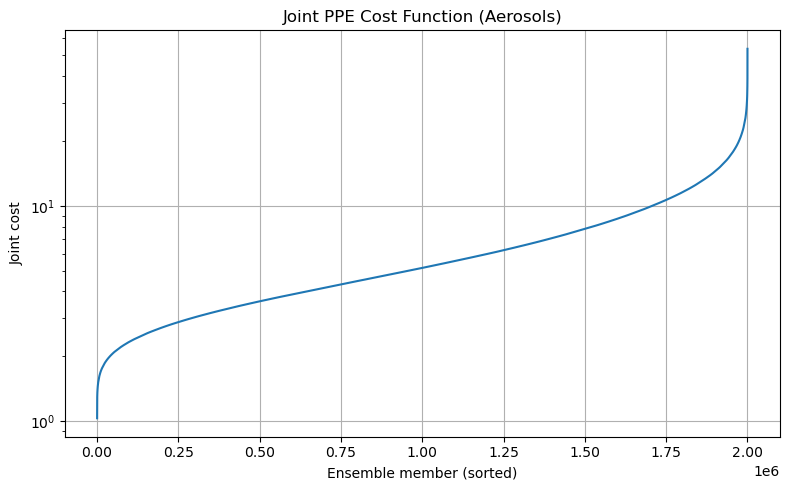


----- INDIVIDUAL VARIABLE COSTS -----
AOD_Mode_1:
   Nobs      = 228
   min cost  = 0.8672
   threshold = 1.2141
   best mems = 2178

   best mems percent = 0.109%

AOD_Mode_Coarse:
   Nobs      = 228
   min cost  = 0.3936
   threshold = 0.5510
   best mems = 8566

   best mems percent = 0.428%

SSA:
   Nobs      = 226
   min cost  = 0.3823
   threshold = 0.5352
   best mems = 422

   best mems percent = 0.021%

AI:
   Nobs      = 228
   min cost  = 0.9599
   threshold = 1.3438
   best mems = 6718

   best mems percent = 0.336%

TAU355_daily:
   Nobs      = 228
   min cost  = 0.2230
   threshold = 0.3122
   best mems = 3631

   best mems percent = 0.182%

CDNC_Filtered_OCI:
   Nobs      = 231
   min cost  = 0.7154
   threshold = 1.0015
   best mems = 166655

   best mems percent = 8.333%



In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("/home/ybhatti/ybhatti2/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New/Regional")

# =======================
# USER CONFIGURATION
# =======================
CHI2_NORM = "L2"
chi2_factor = 1.4

# Variables to include
aerosol_vars = [
    "AOD_Mode_1",
    "AOD_Mode_Coarse",
    "SSA",
    "AI",
    "TAU355_daily",
    # "REFFL_CT_OCI",
    #"CDNC_Filtered_OCI_Hemispheric_Difference",
    "CDNC_Filtered_OCI",

]

# =======================
# BUILD THRESHOLD MATRIX
# =======================
threshold_all = xr.concat([
    threshold_AOD_Mode_1,
    threshold_AOD_Mode_Coarse,
    threshold_SSA,
    threshold_AI,
    threshold_TAU355,
  #  threshold_REFFL_CT_HARP,
#    threshold_REFFL_CT_OCI,
    threshold_CDNC_Filtered_OCI,
    # threshold_CDNC_Filtered_HARP,

    # threshold_CDNC_Filtered_OCI_Hemispheric_Difference
], dim="variable")

threshold_all = threshold_all.assign_coords(variable=[
    "AOD_Mode_1",
    "AOD_Mode_Coarse",
    "SSA",
    "AI",
    "TAU355_daily",
 #   "REFFL_CT_HARP",
#    "REFFL_CT_OCI",
    # "CDNC_Filtered_HARP",
    "CDNC_Filtered_OCI"

])

# =======================
# COST FUNCTION
# =======================
def compute_raw_cost(field, thresholds=None, chi2_norm="L2", custom_threshold=None):
    ppe = field.isel(sample=slice(0, -1))
    obs = field.isel(sample=-1)

    valid = np.isfinite(obs)
    ppe = ppe.where(valid)
    obs = obs.where(valid)

    if custom_threshold is not None:
        _, thresh = xr.broadcast(ppe, custom_threshold)
    else:
        threshold_var = thresholds.sel(variable=field.name)
        _, thresh = xr.broadcast(ppe, threshold_var)

    res = (ppe - obs) / thresh

    if chi2_norm == "L2":
        cost = res**2
    else:
        cost = np.abs(res)

    Nobs = valid.sum().values
   # return cost.sum(dim="z").values, Nobs
    return cost.where(np.isfinite(cost)).sum(dim="z").values, Nobs


# =======================
# INDIVIDUAL COST STORAGE
# =======================
cost_by_var = {}

# =======================
# JOINT COST
# =======================
total_cost = None
Nobs_total = 0

for varname in aerosol_vars:
    print(f"Processing {varname}")
    field = stacked[varname]
    field.name = varname

    if "Hemispheric_Difference" in varname:
        if varname == "CDNC_Filtered_OCI_Hemispheric_Difference":
            cost_raw, Nobs = compute_raw_cost(
                field,
                custom_threshold=threshold_CDNC_Filtered_OCI_Hemispheric_Difference
            )
        if varname == "CDNC_Filtered_HARP_Hemispheric_Difference":
            cost_raw, Nobs = compute_raw_cost(
                field,
                custom_threshold=threshold_CDNC_Filtered_HARP_Hemispheric_Difference
            )
    # elif "CDNC_Filtered" in varname:
    #     if varname == "CDNC_Filtered_OCI":
    #         cost_raw, Nobs = compute_raw_cost(
    #             field,
    #             custom_threshold=threshold_CDNC_Filtered_OCI
    #         )
    #     if varname == "CDNC_Filtered_HARP":
    #         cost_raw, Nobs = compute_raw_cost(
    #             field,
    #             custom_threshold=threshold_CDNC_Filtered_HARP
    #         )

    else:
        cost_raw, Nobs = compute_raw_cost(
            field,
            thresholds=threshold_all,
            chi2_norm=CHI2_NORM
        )

    # Store individual constraint
    cost_by_var[varname] = {
        "raw_cost": cost_raw,
        "norm_cost": cost_raw / Nobs,
        "Nobs": Nobs,
    }

    # Accumulate into joint
    total_cost = cost_raw if total_cost is None else total_cost + cost_raw
    Nobs_total += Nobs


# =======================
# FINAL JOINT COST
# =======================
chi2_total = total_cost / Nobs_total
sorted_idx = np.argsort(chi2_total)
chi2_sorted = chi2_total[sorted_idx]

chi2_min = chi2_sorted[0]
chi2_threshold = chi2_factor * chi2_min
best_idx = sorted_idx[chi2_sorted <= chi2_threshold]

print("\n----- JOINT COST SUMMARY -----")
print(f"Metric      : {CHI2_NORM}")
print(f"Min cost    : {chi2_min:.4f}")
print(f"Threshold   : {chi2_threshold:.4f}")
print(f"Selected    : {len(best_idx)} members")


# =======================
# PLOT JOINT COST
# =======================
plt.figure(figsize=(8,5))
plt.plot(chi2_sorted)
plt.yscale("log")
plt.xlabel("Ensemble member (sorted)")
plt.ylabel("Joint cost")
plt.title("Joint PPE Cost Function (Aerosols)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ======================================================================
#             INDIVIDUAL CONSTRAINT DIAGNOSTICS
# ======================================================================
print("\n----- INDIVIDUAL VARIABLE COSTS -----")
stored_best = []
stored_best_var = []

for var in aerosol_vars:
    raw = cost_by_var[var]["raw_cost"]
    norm = cost_by_var[var]["norm_cost"]
    Nobs = cost_by_var[var]["Nobs"]

    sorted_norm = np.sort(norm)
    vmin = sorted_norm[0]
    vthresh = chi2_factor * vmin
    vbest = np.where(norm <= vthresh)[0]
    stored_best.append(vbest)
    stored_best_var.append(var)

    print(f"{var}:")
    print(f"   Nobs      = {Nobs}")
    print(f"   min cost  = {vmin:.4f}")
    print(f"   threshold = {vthresh:.4f}")
    print(f"   best mems = {len(vbest)}\n")
    print(f"   best mems percent = {len(vbest)/2000000*100:.3f}%\n")

    Accepted_Params_non_norm = ppe_non_normalized_new_samples.iloc[vbest]
    Accepted_Params_norm = ppe_normalized_new_samples.iloc[vbest]
    Accepted_Params_non_norm.to_csv(f'{base_dir}/Accepted_Ensembles/Individual/Accepted_Params_non_norm_{var}_{len(best_idx)}_Optimal_Constraint_chosen_L14.csv')
    Accepted_Params_norm.to_csv(f'{base_dir}/Accepted_Ensembles/Individual/Accepted_Params_norm_{var}_{len(best_idx)}_Optimal_Constraint_chosen_L14.csv')

#     # # Plot per-variable curve
#     # plt.figure(figsize=(6,4))
#     # plt.plot(sorted_norm)
#     # plt.yscale("log")
#     # plt.title(f"Cost distribution — {var}")
#     # plt.xlabel("Sorted ensemble member")
#     # plt.ylabel("Normalized cost")
#     # plt.grid(True)
#     # plt.tight_layout()
#     # plt.show()


Accepted_Params_non_norm = ppe_non_normalized_new_samples.iloc[best_idx]
Accepted_Params_norm = ppe_normalized_new_samples.iloc[best_idx]
Accepted_Params_non_norm.to_csv(f'{base_dir}/Accepted_Ensembles/Accepted_Params_non_norm_{len(best_idx)}_Optimal_Constraint_chosen_L14.csv')
Accepted_Params_norm.to_csv(f'{base_dir}/Accepted_Ensembles/Accepted_Params_norm_{len(best_idx)}_Optimal_Constraint_chosen_L14.csv')



In [10]:
# =======================
# READABLE JOINT COST PLOT (RELATIVE SCALE)
# =======================
plt.figure(figsize=(9, 5))

x = np.arange(len(chi2_sorted))

# Normalize cost by minimum
chi2_rel = chi2_sorted / chi2_min
threshold_rel = chi2_factor  # exactly 1.5

# Plot relative joint cost
plt.plot(
    x,
    chi2_rel,
    color="black",
    lw=1.2,
    alpha=0.85,
    label="Relative joint cost"
)

# Acceptance threshold
plt.axhline(
    threshold_rel,
    color="crimson",
    linestyle="--",
    lw=1.5,
    label="Acceptance threshold"
)

# Shade accepted ensemble region
n_accept = np.sum(chi2_rel <= threshold_rel)
plt.axvspan(
    0,
    n_accept,
    color="crimson",
    alpha=0.15,
    label="Accepted ensemble"
)

# Axis formatting
plt.yscale("log")
plt.yticks([1, 1.5, 2, 5, 10])
plt.gca().set_yticklabels(["1 (best)", "1.5", "2", "5", "10"])

plt.xlabel("Ensemble member (ranked by cost)", fontsize=11)
plt.ylabel("Relative misfit (χ² / χ²ₘᵢₙ)", fontsize=11)
plt.title("Joint Observational Constraint on PPE", fontsize=13)

plt.grid(True, which="major", alpha=0.3)
plt.grid(False, which="minor")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Cost_Function.png", dpi=200, bbox_inches='tight')
plt.show()


/scratch-local/ybhatti2.18205220/ipykernel_2434157/7855761.py:53: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/scratch-local/ybhatti2.18205220/ipykernel_2434157/7855761.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Cost_Function.png", dpi=200, bbox_inches='tight')


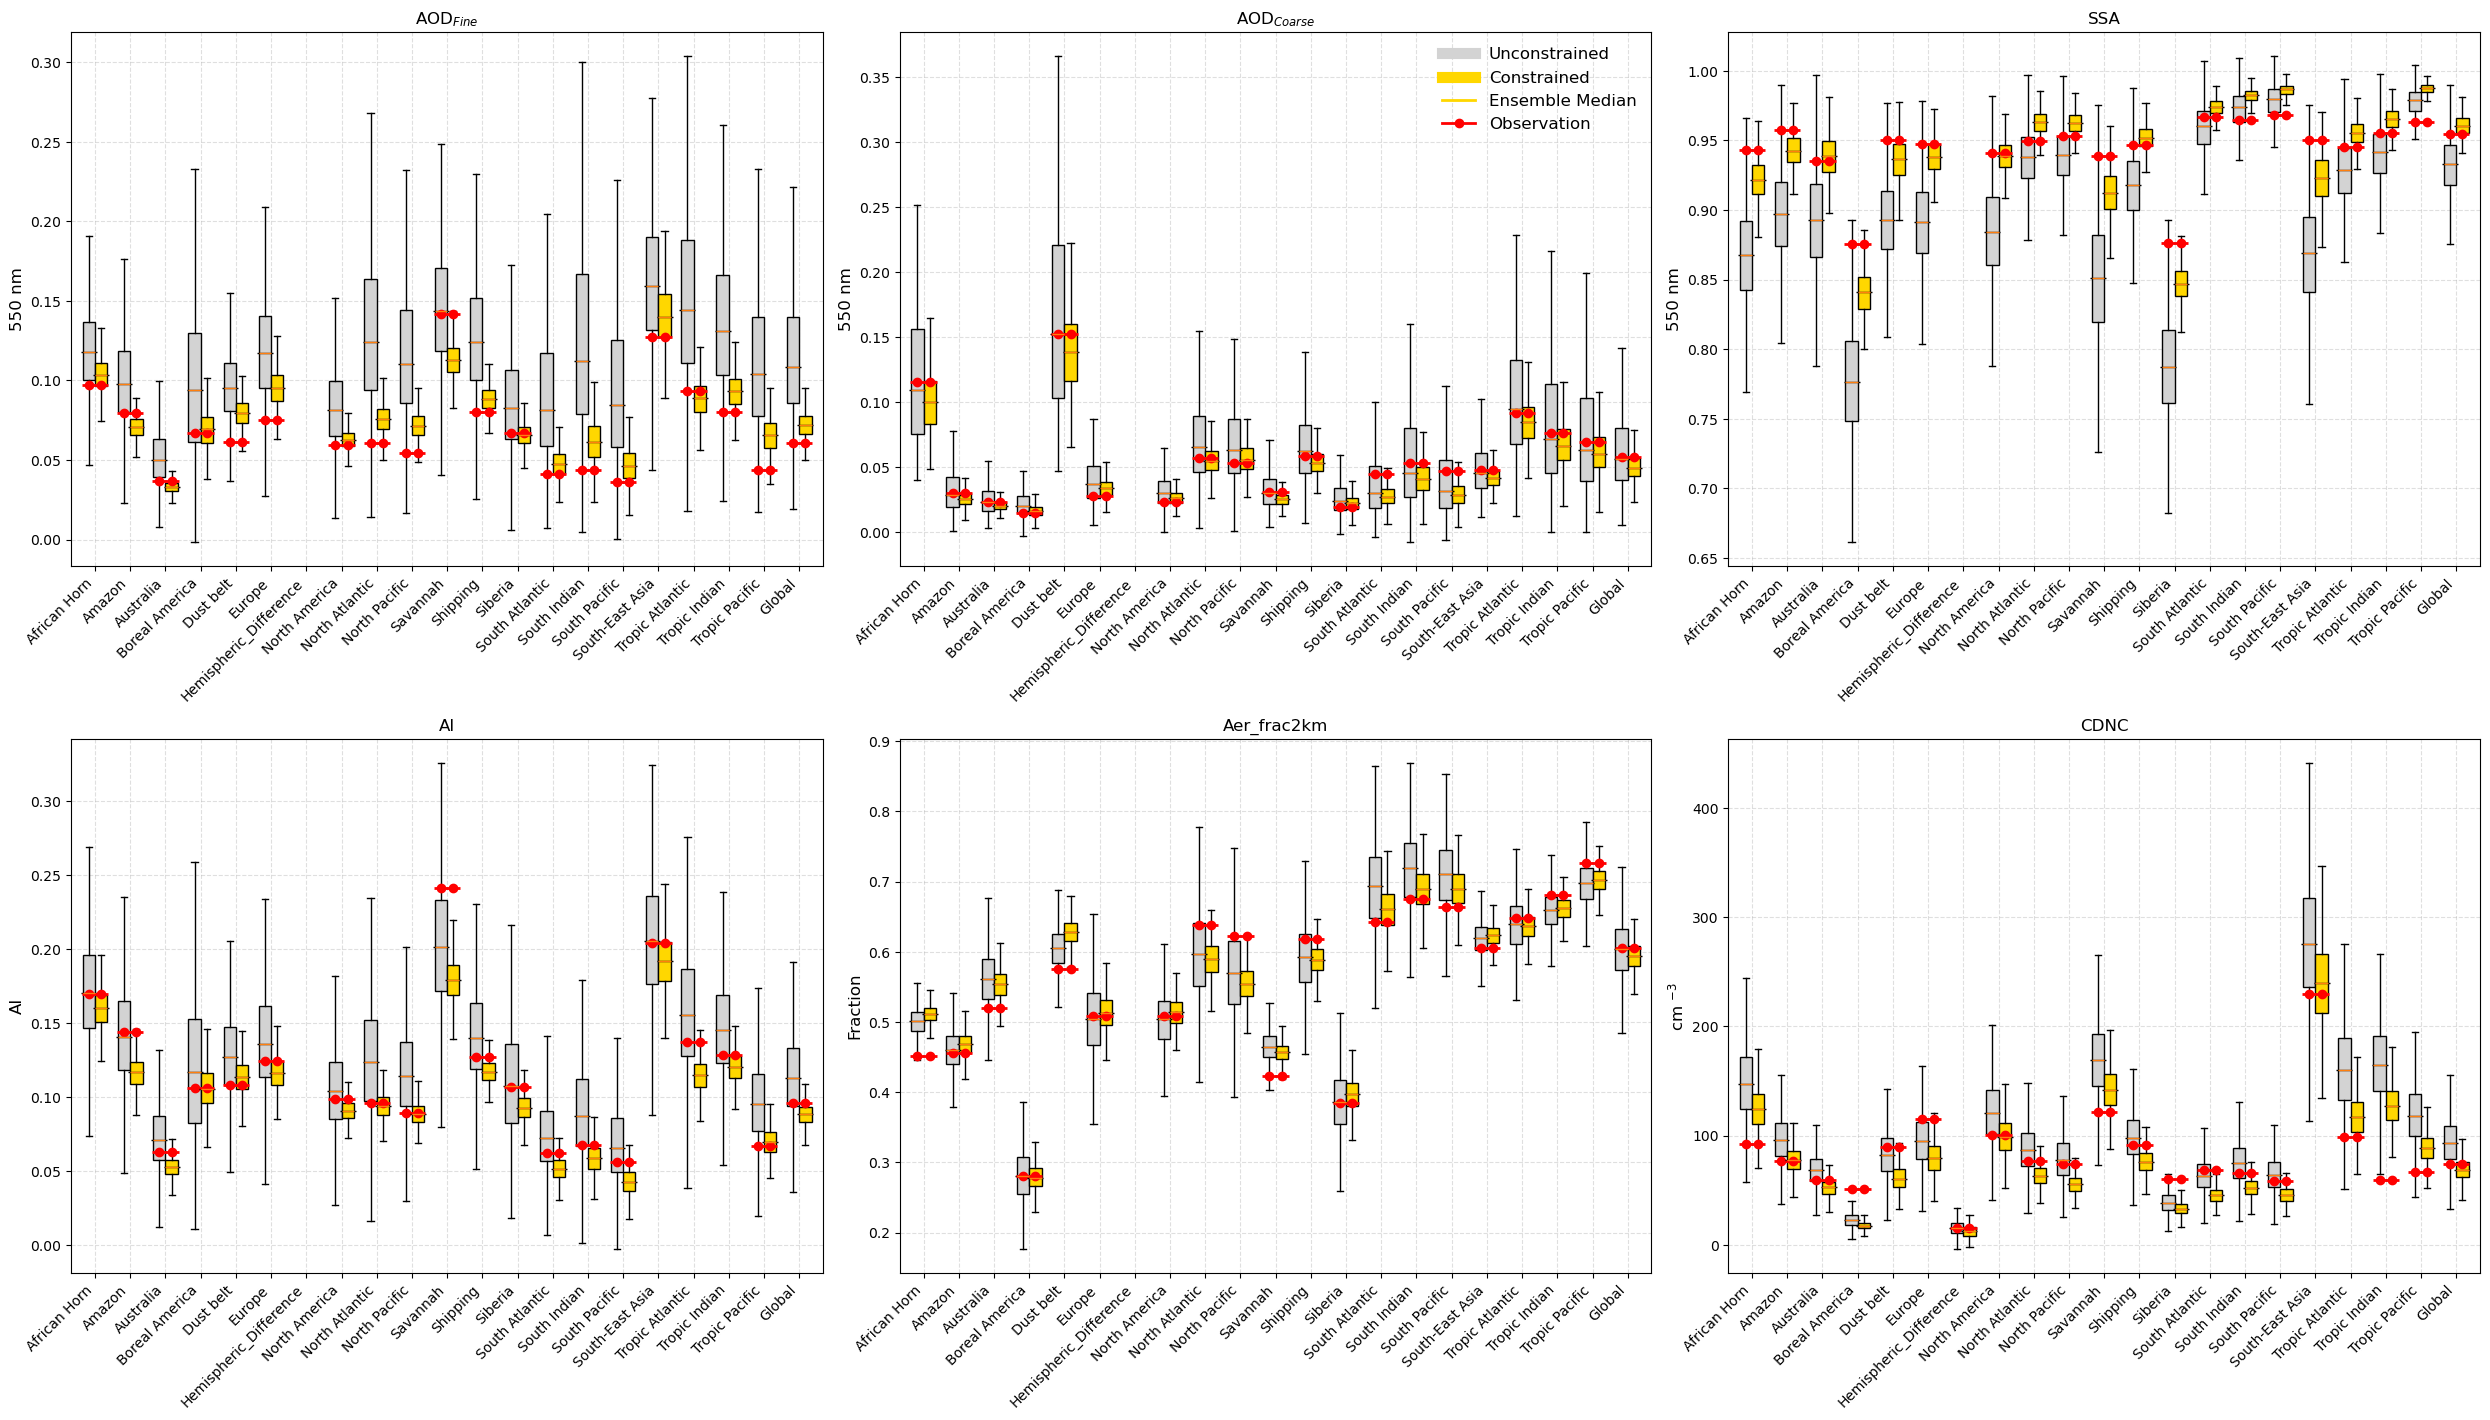

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import mode

# =========================
# Load best indices
# =========================
# Accepted_Params_norm = pd.read_csv(
#     "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Accepted_Params_norm_3970_Best_Constraint.csv"
# )
# Accepted_Params_norm.set_index(Accepted_Params_norm.columns[0], inplace=True)
best_idx = Accepted_Params_norm.reset_index().iloc[:, 0].to_numpy()
best_index = best_idx.flatten()

# =========================
# Region and metric order
# =========================
regions_ordered = [r for r in boxplot_dataset.region.data if r != "Global"] + ["Global"]
metrics_order = [
    "AOD_Mode_1", "AOD_Mode_Coarse", "SSA", "AI",
    "TAU355_daily", "CDNC_Filtered_OCI"
]

OBS_TITLES = [
    "AOD$_{Fine}$",
    "AOD$_{Coarse}$",
    "SSA",
    "AI",
    "Aer_frac2km",
    # "REFFL_CT",
    "CDNC",
]
units = [
    "550 nm",
    "550 nm",
    "550 nm",
    "AI",
    "Fraction",
    # "REFFL_CT",
    "cm $^{-3}$",
]

# =========================
# Plot setup
# =========================
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 20), sharex=False, sharey=False)
axes = axes.flatten()
box_width = 0.35
line_width = 0.2  # half-width of horizontal lines for obs/control
x = np.arange(len(regions_ordered))
regions_order = regions_ordered[::-1]
for ax, var,titles,unit in zip(axes, metrics_order,OBS_TITLES,units):

    data = boxplot_dataset[var]
    data_c = data.sel(sample=best_index)

    obs = data[-1]
    ctrl = data[0]

    # --- Prepare data per region ---
    data_uncon_list = [data.sel(region=r).values for r in regions_ordered]
    data_con_list = [data_c.sel(region=r).values for r in regions_ordered]

    # --- Vertical boxplots side-by-side ---
    bp1 = ax.boxplot(
        data_uncon_list,
        positions=x - box_width/2,
        widths=box_width,
        patch_artist=True,
        vert=True,
        showcaps=True,
        showfliers=False
        
    )
    bp2 = ax.boxplot(
        data_con_list,
        positions=x + box_width/2,
        widths=box_width,
        patch_artist=True,
        vert=True,
        showcaps=True,
        showfliers=False
    )

    for box in bp1['boxes']:
        box.set(facecolor='lightgrey')
    for box in bp2['boxes']:
        box.set(facecolor='gold')

    # --- Overlay ensemble median, observation, control for each region ---
    for i, region in enumerate(regions_ordered):
        # Unconstrained
        #median_uncon = mode(data.sel(region=region).values, keepdims=False).mode
        median_uncon = np.median(data.sel(region=region).values)

        #median_uncon = np.median(data.sel(region=region).values)
        ax.plot(i - box_width/2, median_uncon, 'k_', markersize=12)

        obs_val = obs.sel(region=region).item()
        ax.hlines(
            obs_val, i - box_width/2 - line_width, i - box_width/2 + line_width,
            color='red', linewidth=2
        )
        ax.plot(i - box_width/2, obs_val, 'o', color='red', markersize=6, markerfacecolor='red')

        ctrl_val = ctrl.sel(region=region).item()
        # ax.hlines(
        #     ctrl_val, i - box_width/2 - line_width, i - box_width/2 + line_width,
        #     color='blue', linewidth=2
        # )
     #   ax.plot(i - box_width/2, ctrl_val, 'o', color='blue', markersize=6, markerfacecolor='blue')

        # Constrained
        median_con = np.median(data_c.sel(region=region).values)
        ax.plot(i + box_width/2, median_con, 'k_', markersize=12)

        obs_val_c = obs.sel(region=region).item()
        ax.hlines(
            obs_val_c, i + box_width/2 - line_width, i + box_width/2 + line_width,
            color='red', linewidth=2
        )
        ax.plot(i + box_width/2, obs_val_c, 'o', color='red', markersize=6, markerfacecolor='red')

        ctrl_val_c = ctrl.sel(region=region).item()
        # ax.hlines(
        #     ctrl_val_c, i + box_width/2 - line_width, i + box_width/2 + line_width,
        #     color='blue', linewidth=2
        # )
    #    ax.plot(i + box_width/2, ctrl_val_c, 'o', color='blue', markersize=6, markerfacecolor='blue')
        
    # --- Axes ---
    ax.set_xticks(x)
    ax.set_xticklabels(regions_ordered, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel(unit, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_title(titles)
    
# Remove empty subplots if any
for ax in axes[len(metrics_order):]:
    fig.delaxes(ax)

# --- Legend ---
legend_elements = [
    Line2D([0], [0], color='lightgrey', lw=8, label='Unconstrained'),
    Line2D([0], [0], color='gold', lw=8, label='Constrained'),
    Line2D([0], [0], color='gold', lw=2, marker='_', label='Ensemble Median', markersize=10),
    Line2D([0], [0], color='red', lw=2, marker='o', markersize=6, markerfacecolor='red', label='Observation'),
    # Line2D([0], [0], color='blue', lw=2, marker='o', markersize=6, markerfacecolor='blue', label='Control')
]

axes[1].legend(handles=legend_elements, fontsize=12, loc='upper right', frameon=False)
;
plt.tight_layout()
#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Supplimentary/Constrained_Diagnostics_box.png", dpi=100, bbox_inches='tight')

plt.show()


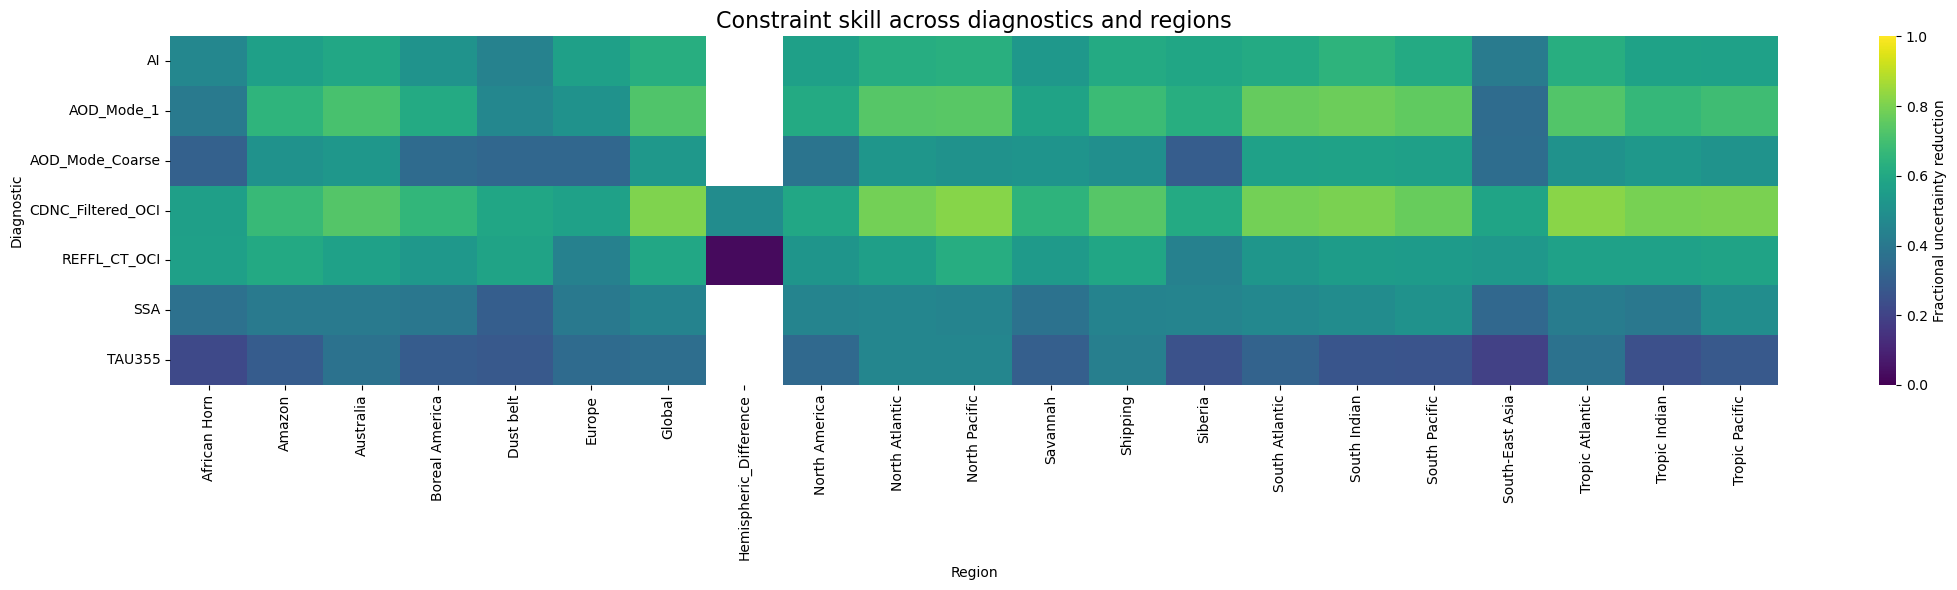

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Build summary table
records = []

for var in metrics_order:
    data = boxplot_dataset[var]
    obs = data[-1]
    uncon = data[:-1]
    con = data.sel(sample=best_idx.flatten())

    for region in boxplot_dataset.region.data:
        u = uncon.sel(region=region)
        c = con.sel(region=region)

        # spread reduction
        frac_reduction = 1 - (c.std().item() / u.std().item())

        # distance change
        dist_uncon = np.abs(u.mean().item() - obs.sel(region=region).item())
        dist_con   = np.abs(c.mean().item() - obs.sel(region=region).item())
        bias_flag = dist_con > dist_uncon

        records.append({
            "Diagnostic": var,
            "Region": region,
            "Frac_Reduction": frac_reduction,
            "Bias": bias_flag
        })

df = pd.DataFrame(records)

# Pivot for heatmap
heatmap_data = df.pivot(index="Diagnostic", columns="Region", values="Frac_Reduction")

plt.figure(figsize=(22, 6))
ax = sns.heatmap(
    heatmap_data,
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws=dict(label="Fractional uncertainty reduction")
)
ﬁ
# # Overlay bias markers
# for _, row in df[df["Bias"]].iterrows():
#     y = heatmap_data.index.tolist().index(row["Diagnostic"])
#     x = heatmap_data.columns.tolist().index(row["Region"])
#     ax.text(x + 0.5, y + 0.5, "×", ha="center", va="center", color="red", fontsize=12)

ax.set_title("Constraint skill across diagnostics and regions", fontsize=16)
plt.tight_layout()
plt.show()


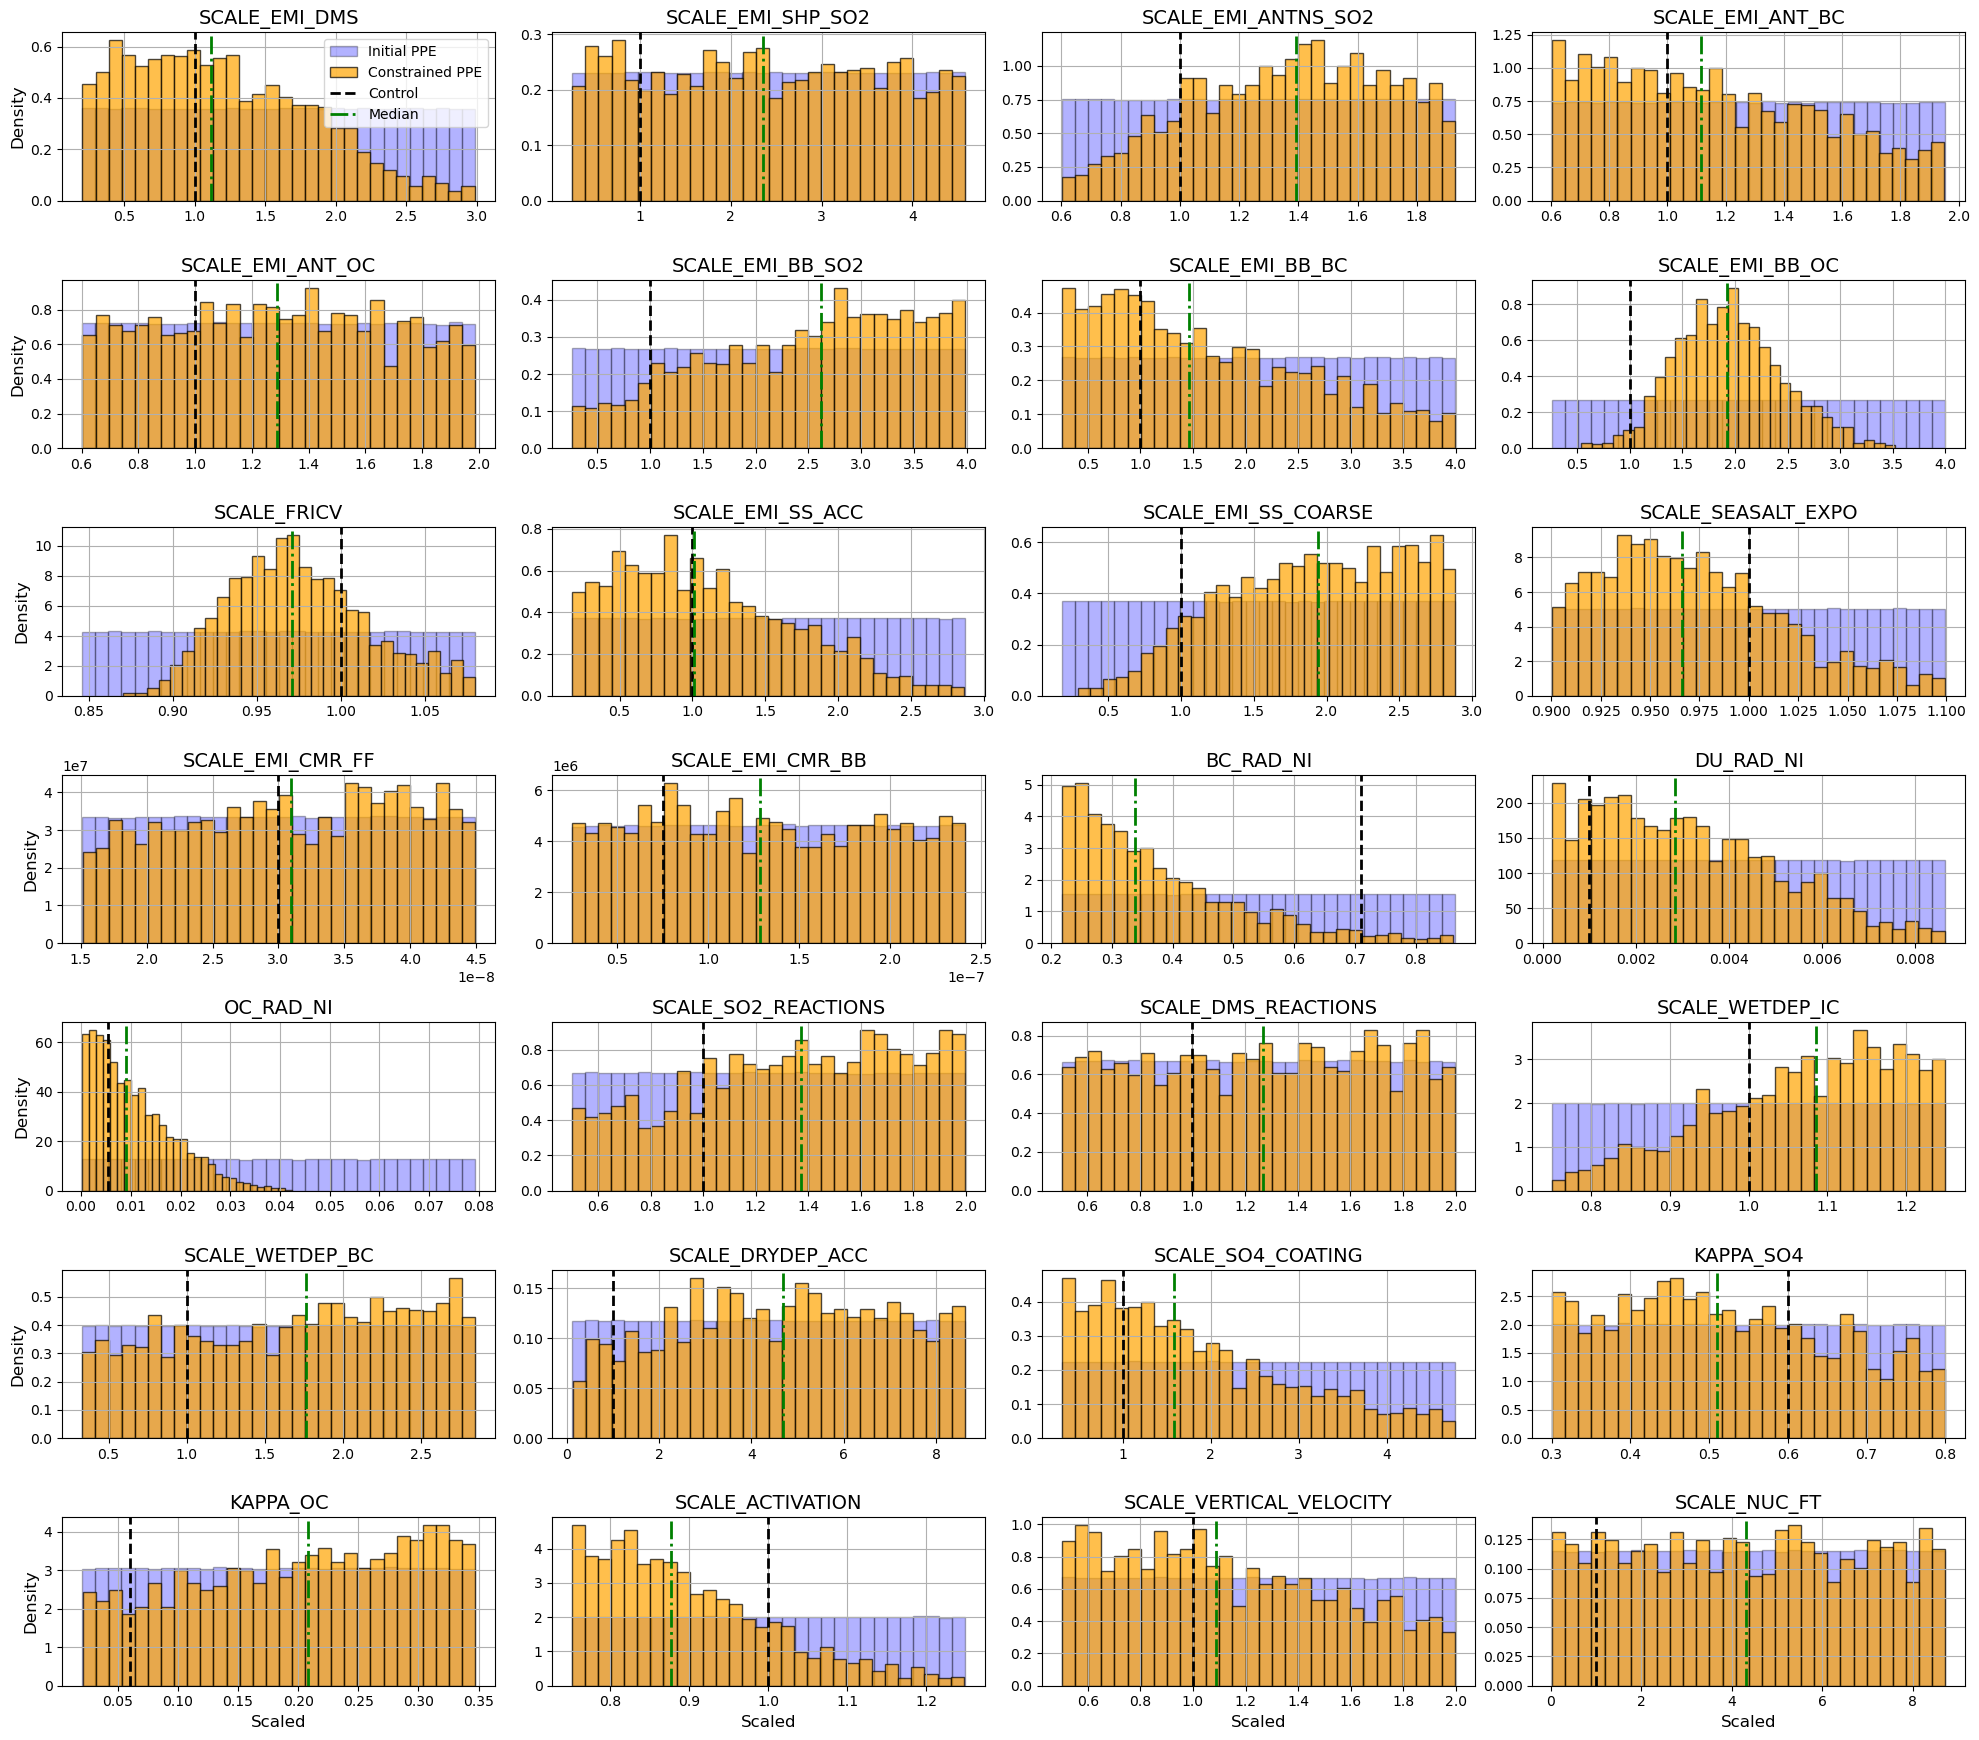

In [13]:
#accepted_members_best = np.where(best_index)[0]  # indices where both conditions true
# Accepted_Params_norm = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Accepted_Params_norm_2566_Best_Constraint.csv')
# Accepted_Params_norm.set_index(Accepted_Params_norm.columns[0], inplace=True)
# best_idx = Accepted_Params_norm.reset_index().iloc[:, 0].to_numpy()


shared_dataset_Southern_Ocean = ppe_non_normalized_new_samples.iloc[best_idx]
control_values = ppe_non_normalized_new_samples.iloc[0]
# best_member_values = ppe_non_normalized_new_samples.iloc[best_idx]
num_cols = len(shared_dataset_Southern_Ocean.columns)
cols_per_row = 4
rows = num_cols // cols_per_row + int(num_cols % cols_per_row > 0)

# First pass: compute max density across all plots
ymax = 0
for col in shared_dataset_Southern_Ocean.columns:
    # hist() with density=True returns n values
    n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
    n_shared, _, _ = plt.hist(shared_dataset_Southern_Ocean[col], bins=30, density=True)
    ymax = max(ymax, n_full.max(), n_shared.max())
plt.close()  # close the dummy figure

# Second pass: actual plotting
fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(20, rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(shared_dataset_Southern_Ocean.columns):
    ax = axes[i]

    # Histogram for full ensemble (blue, transparent)
    ppe_non_normalized_new_samples[col].hist(ax=ax, bins=30, edgecolor='black',
                          color='blue', alpha=0.3, label='Initial PPE', density=True)

    # Histogram for shared ensemble members (orange)
    shared_dataset_Southern_Ocean[col].hist(ax=ax, bins=30, edgecolor='black',
                             color='orange', alpha=0.7, label='Constrained PPE', density=True)

    # Vertical line for control value
    ax.axvline(control_values[col], color="black", linestyle="--", linewidth=2, label="Control")
    # ax.axvline(best_values[col], color="red", linestyle="--", linewidth=2, label="Best Ensemble")
    ax.axvline(shared_dataset_Southern_Ocean[col].median(), color="green", linestyle="dashdot", linewidth=2, label="Median")

    # Inside the plotting loop, after the control line:
    # ax.axvline(best_member_values[col], color='green', linestyle='-', linewidth=2, label='Best-fit')

    # Title for the subplot
    ax.set_title(col, fontsize=14)

    # y-axis label
    if i % cols_per_row != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Density', fontsize=12)

    # x-axis label
    if i < (rows - 1) * cols_per_row:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Scaled', fontsize=12)

    # Set same y-limits across all plots
   # ax.set_ylim(0, ymax * 1.1)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    if i == 0:
        ax.legend(fontsize=10)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
# accepted_pct = 100 * accepted_both.sum().item() / accepted_both.size

# print(f"Accepted BOTH = {accepted_pct:.2f}%")

plt.tight_layout()
#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/PPE_Distribution_Constrained.png", dpi=100, bbox_inches='tight')
#plt.savefig(f"/deos/yusufb/PAPER_2/Plots/PPE_Distribution_Constrained.png", dpi=100, bbox_inches='tight')

plt.show()


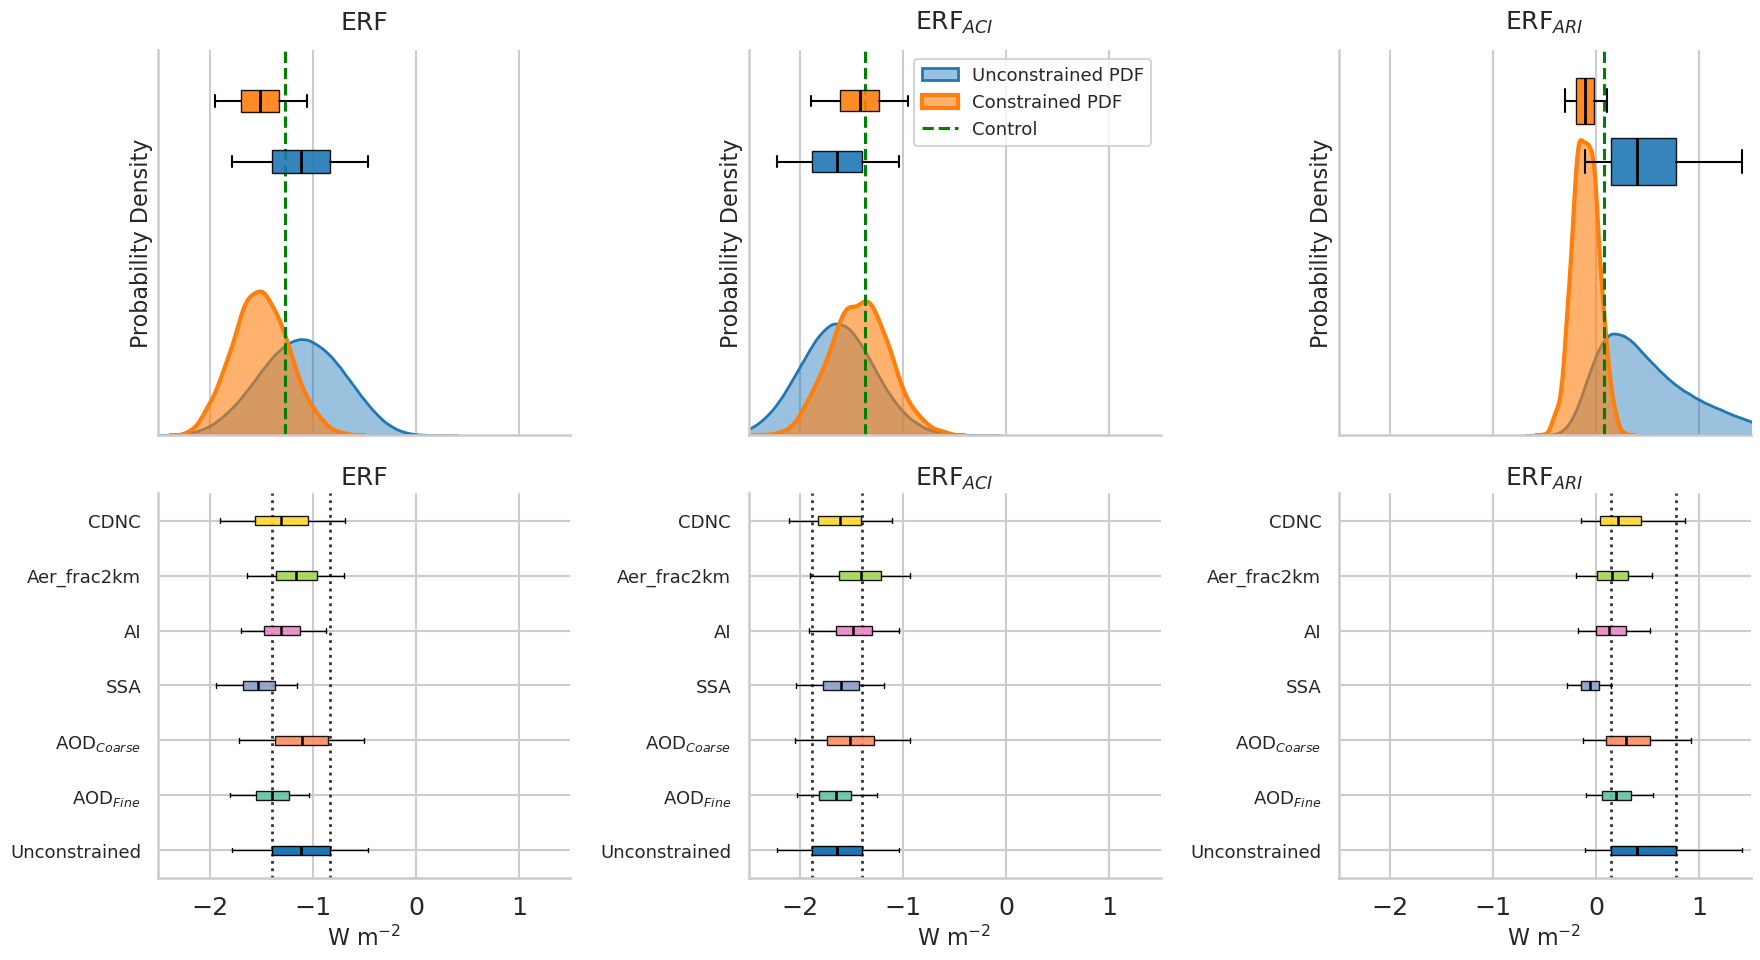

Accepted ERF        5% = -1.948,   95% = -1.056,   Gap = 0.892,   Mean = -1.511
Accepted ERFaci     5% = -1.892,   95% = -0.953,   Gap = 0.939,   Mean = -1.424
Accepted ERFari     5% = -0.301,   95% = 0.101,   Gap = 0.402,   Mean = -0.105
Full ERF            5% = -1.783,   95% = -0.463,   Gap = 1.321,   Mean = -1.115
Full ERFaci         5% = -2.229,   95% = -1.042,   Gap = 1.187,   Mean = -1.640
Full ERFari         5% = -0.108,   95% = 1.415,   Gap = 1.524,   Mean = 0.497


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
stored_best_var = aerosol_vars
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.1)

# ------------------
# Setup
# ------------------
n_samples_new = 2000000
accepted_members_best = best_idx

x_limits = [-2.5, 1.5]

label_2 = [
    "Unconstrained",
    "AOD$_{Fine}$",
    "AOD$_{Coarse}$",
    "SSA",
    "AI",
    "Aer_frac2km",
    # "REFFL_CT",
    "CDNC",
]

# ------------------
# Load data
# ------------------
Full_ERF = xr.open_dataset(
    f'{base_dir}/ERF/emulated_erf_{n_samples_new}.nc'
)['Emulated ERF'].sel(region='Global').mean('month')
Accepted_ERF = Full_ERF.sel(sample=accepted_members_best)

Full_ERFaci = xr.open_dataset(
    f'{base_dir}/ERFaci/emulated_erfaci_{n_samples_new}.nc'
)['Emulated ERFaci'].sel(region='Global').mean('month')
Accepted_ERFaci = Full_ERFaci.sel(sample=accepted_members_best)

Full_ERFari = xr.open_dataset(
    f'{base_dir}/ERFari/emulated_erfari_{n_samples_new}.nc'
)['Emulated ERFari'].sel(region='Global').mean('month')
Accepted_ERFari = Full_ERFari.sel(sample=accepted_members_best)

datasets_full = [
    ("ERF", Full_ERF, Accepted_ERF),
    ("ERF$_{ACI}$", Full_ERFaci, Accepted_ERFaci),
    ("ERF$_{ARI}$", Full_ERFari, Accepted_ERFari),
]

datasets_bottom = [
    ("ERF", Full_ERF),
    ("ERF$_{ACI}$", Full_ERFaci),
    ("ERF$_{ARI}$", Full_ERFari),
]

# ------------------
# Colors for constraints
# ------------------
palette = sns.color_palette("Set2", len(stored_best))
constraint_colors = dict(zip(stored_best_var, palette))

# ------------------
# Figure
# ------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    sharex=True,
    sharey=False
)

# ==========================================================
# TOP ROW: Combined constrained PDFs + boxplots (unchanged)
# ==========================================================
for ax, (title, full, acc) in zip(axes[0], datasets_full):

    sns.kdeplot(
        full, fill=True, ax=ax,
        color="#1f77b4", alpha=0.45, linewidth=2,
        label="Unconstrained PDF"
    )
    sns.kdeplot(
        acc, fill=True, ax=ax,
        color="#ff7f0e", alpha=0.6, linewidth=3,
        label="Constrained PDF"
    )

    ax.axvline(full[0], color="green", linestyle="--", linewidth=2.2, label="Control")
    q1_full, q3_full = np.percentile(full, [25, 75])
    
    # ax.axvline(q1_full, color="black", linestyle=":", linewidth=2, alpha=0.8)
    # ax.axvline(q3_full, color="black", linestyle=":", linewidth=2, alpha=0.8)


    ymax = ax.get_ylim()[1]

    def draw_boxplot(ax, data, y_center, color):
        p = np.percentile(data, [5, 25, 50, 75, 95])
        ax.bxp([{
            'med': p[2],
            'q1':  p[1],
            'q3':  p[3],
            'whislo': p[0],
            'whishi': p[4],
            'fliers': []
        }],
        positions=[y_center],
        widths=0.15 * ymax,
        vert=False,
        patch_artist=True,
        boxprops={'facecolor': color, 'edgecolor': 'black', 'alpha': 0.9},
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5})

    draw_boxplot(ax, full, 2.7, "#1f77b4")
    draw_boxplot(ax, acc,  3.3, "#ff7f0e")

    ax.set_title(title, fontsize=18, pad=15)
    ax.set_xlim(x_limits)
    ax.set_yticks([])
    ax.set_ylabel("Probability Density", fontsize=16)
    if ax is axes[0][1]:
        ax.legend(frameon=True, fontsize=13, loc="upper right")

# ==========================================================
# BOTTOM ROW: Horizontal distribution bars (individual constraints)
# ==========================================================
for ax, (title, full) in zip(axes[1], datasets_bottom):

    y_positions = np.arange(len(stored_best_var) + 1)
    # --- Reference quartiles from unconstrained distribution ---
    q1_full, q3_full = np.percentile(full, [25, 75])
    
    ax.axvline(q1_full, color="black", linestyle=":", linewidth=2, alpha=0.8)
    ax.axvline(q3_full, color="black", linestyle=":", linewidth=2, alpha=0.8)

    # --- Unconstrained ---
    p = np.percentile(full, [5, 25, 50, 75, 95])
    ax.bxp([{
        'med': p[2],
        'q1':  p[1],
        'q3':  p[3],
        'whislo': p[0],
        'whishi': p[4],
        'fliers': []
    }],
    positions=[y_positions[0]],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#1f77b4", edgecolor="black"),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"))

    # --- Individual constraints ---
    for i, (name, ens) in enumerate(zip(aerosol_vars, stored_best), start=1):
        # if i == 2:
        #     end
        acc = full.sel(sample=ens)
        p = np.percentile(acc, [5, 25, 50, 75, 95])

        ax.bxp([{
            'med': p[2],
            'q1':  p[1],
            'q3':  p[3],
            'whislo': p[0],
            'whishi': p[4],
            'fliers': []
        }],
        positions=[y_positions[i]],
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor=constraint_colors[name], edgecolor="black", alpha=0.9),
        medianprops=dict(color="black", linewidth=1.8),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"))

    ax.set_title(title, fontsize=18)
    ax.set_xlim(x_limits)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(label_2, fontsize=13)
    ax.set_xlabel("W m$^{-2}$", fontsize=16)

# ------------------
# Legend (bottom, shared)
# ------------------
handles = [
    plt.Line2D([0], [0], color="#1f77b4", lw=10),
] + [
    plt.Line2D([0], [0], color=constraint_colors[n], lw=10)
    for n in stored_best_var
]

# fig.legend(
#     handles,
#     label_2,
#     loc="lower center",
#     ncol=4,
#     frameon=True,
#     fontsize=18,
#     bbox_to_anchor=(0.5, -0.06)
# )

sns.despine()
plt.tight_layout()
# plt.savefig(
#     "/home/ybhatti2/Figures/Manuscript_Figures/ERF_PDF.png",
#     dpi=300,
#     bbox_inches="tight"
# )
# plt.savefig(
#     "/home/ybhatti2/Figures/Manuscript_Figures/ERF_PDF.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()


datasets = {
    "Accepted ERF":     Accepted_ERF,
    "Accepted ERFaci":  Accepted_ERFaci,
    "Accepted ERFari":  Accepted_ERFari,
    "Full ERF":         Full_ERF,
    "Full ERFaci":      Full_ERFaci,
    "Full ERFari":      Full_ERFari,
}

for name, data in datasets.items():
    p5  = np.percentile(data, 5)
    p95 = np.percentile(data, 95)
    gap = p95 - p5
    mean  = np.nanmean(data)
    gap_half  = (gap/2)

    print(f"{name:18s}  5% = {p5:.3f},   95% = {p95:.3f},   Gap = {gap:.3f},   Mean = {mean:.3f}")


In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# SETUP
# =========================
n_samples_new = 2000000
n_samples = 2000000

# =========================
# LOAD ERF VARIABLES
# =========================
Full_ERF = xr.open_dataset(
    f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERF/emulated_erf_{n_samples_new}.nc'
)['Emulated ERF'].sel(region='Global').mean('month')

Full_ERFaci = xr.open_dataset(
    f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFaci/emulated_erfaci_{n_samples_new}.nc'
)['Emulated ERFaci'].sel(region='Global').mean('month')

Full_ERFari = xr.open_dataset(
    f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFari/emulated_erfari_{n_samples_new}.nc'
)['Emulated ERFari'].sel(region='Global').mean('month')

# =========================
# LOAD PARAMETERS
# =========================
params = pd.read_csv(
    f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_{n_samples_new}.csv'
)
params.set_index(params.columns[0], inplace=True)

params_original = pd.read_csv(
    '/home/ybhatti2/prjs1474/Datasets/Normalized_PPE_Parameters.csv'
)
params_original.set_index(params_original.columns[0], inplace=True)

# =========================
# LOAD rwet / rdry (EXPLICIT)
# =========================
rwet_AS = areaweight(
    xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/rwet_AS_PPE.nc')
    .rwet_AS.mean('time').sum('lev'),
    lats
)

rwet_KS = areaweight(
    xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/rwet_KS_PPE.nc')
    .rwet_KS.mean('time').sum('lev'),
    lats
)


rdry_AS = areaweight(
    xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/rdry_AS_PPE.nc')
    .rdry_AS.mean('time').sum('lev'),
    lats
)

rdry_KS = areaweight(
    xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/rdry_KS_PPE.nc')
    .rdry_KS.mean('time').sum('lev'),
    lats
)

rdry_KI = areaweight(
    xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/rdry_KI_PPE.nc')
    .rdry_KI.mean('time').sum('lev'),
    lats
)

# =========================
# COMPUTE CORRELATIONS
# =========================
corr_ERF = params.apply(lambda col: np.corrcoef(col.values, Full_ERF)[0, 1])
corr_ERFaci = params.apply(lambda col: np.corrcoef(col.values, Full_ERFaci)[0, 1])
corr_ERFari = params.apply(lambda col: np.corrcoef(col.values, Full_ERFari)[0, 1])

corr_ssa = params.apply(
    lambda col: np.corrcoef(col.values, boxplot_dataset['SSA'].sel(region='Global')[:-1])[0, 1]
)

corr_aod_mode_1 = params.apply(
    lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_1'].sel(region='Global')[:-1])[0, 1]
)

corr_aod_mode_coarse = params.apply(
    lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_Coarse'].sel(region='Global')[:-1])[0, 1]
)

corr_ai = params.apply(
    lambda col: np.corrcoef(col.values, boxplot_dataset['AI'].sel(region='Global')[:-1])[0, 1]
)

corr_cdnc_filtered = params.apply(
    lambda col: np.corrcoef(col.values, boxplot_dataset['CDNC_Filtered_OCI'].sel(region='Global')[:-1])[0, 1]
)

corr_reffl_ct = params.apply(
    lambda col: np.corrcoef(col.values, boxplot_dataset['REFFL_CT_OCI'].sel(region='Global')[:-1])[0, 1]
)

corr_tau = params.apply(
    lambda col: np.corrcoef(col.values, boxplot_dataset['TAU355'].sel(region='Global')[:-1])[0, 1]
)

# rwet / rdry correlations (EXPLICIT)
corr_rwet_AS = params_original.apply(lambda col: np.corrcoef(col.values, rwet_AS)[0, 1])
corr_rwet_KS = params_original.apply(lambda col: np.corrcoef(col.values, rwet_KS)[0, 1])

corr_rdry_AS = params_original.apply(lambda col: np.corrcoef(col.values, rdry_AS)[0, 1])
corr_rdry_KS = params_original.apply(lambda col: np.corrcoef(col.values, rdry_KS)[0, 1])
corr_rdry_KI = params_original.apply(lambda col: np.corrcoef(col.values, rdry_KI)[0, 1])

# =========================
# BUILD RESULTS DATAFRAME
# =========================
results_all = pd.DataFrame({
    'Parameter': params.columns,
    'ERF': corr_ERF.values,
    'ERFaci': corr_ERFaci.values,
    'ERFari': corr_ERFari.values,
    'TAU355': corr_tau.values,
    'SSA': corr_ssa.values,
    'AOD_Mode_1': corr_aod_mode_1.values,
    'AOD_Mode_Coarse': corr_aod_mode_coarse.values,
    'AI': corr_ai.values,
    'CDNC_Filtered_OCI': corr_cdnc_filtered.values,
    'REFFL_CT_OCI': corr_reffl_ct.values,
    'rwet_AS': corr_rwet_AS.values,
    'rwet_KS': corr_rwet_KS.values,
    'rdry_AS': corr_rdry_AS.values,
    'rdry_KS': corr_rdry_KS.values,
    'rdry_KI': corr_rdry_KI.values
}).melt(
    id_vars='Parameter',
    var_name='Diagnostic',
    value_name='corrcoef'
)

# =========================
# CLEAN PARAMETER NAMES
# =========================
results_all["Parameter"] = results_all["Parameter"].str.replace(
    "SCALE_", "", regex=False
)

# =========================
# ORDERING
# =========================
params_order = (
    results_all[results_all['Diagnostic'] == 'ERF']
    .sort_values('corrcoef', ascending=False)['Parameter']
    .tolist()
)

diagnostics_order = [
    "ERF", "ERFaci", "ERFari", "TAU355", "SSA",
    "AOD_Mode_1", "AOD_Mode_Coarse",
    "AI", "CDNC_Filtered_OCI", "REFFL_CT_OCI",
    "rwet_AS", "rwet_KS",
    "rdry_AS", "rdry_KS", "rdry_KI"
]

# =========================
# PLOT HEATMAP (UNCHANGED)
# =========================
fig, axes = plt.subplots(
    1, len(diagnostics_order),
    figsize=(7, 10),
    sharey=True
)

plt.subplots_adjust(
    left=0.05, right=1.4, bottom=0.1, top=0.95, wspace=0.5
)

vlim = np.nanmax(np.abs(results_all['corrcoef']))

for ax, diag in zip(axes, diagnostics_order):

    sub = results_all[results_all["Diagnostic"] == diag]
    mat = (
        sub.set_index('Parameter')['corrcoef']
        .reindex(params_order)
        .values[:, np.newaxis]
    )
    ax.set_title(diag, fontsize=7,rotation=45, pad=12, weight='bold')

    sns.heatmap(
        mat,
        ax=ax,
        cmap="coolwarm",
        center=0,
        vmin=-vlim,
        vmax=vlim,
        cbar=False,
        xticklabels=[diag],
        yticklabels=params_order,
        linewidths=0.2,
        linecolor='grey'
    )

    ax.tick_params(axis='both', length=0)

# =========================
# COLORBAR
# =========================
cbar_ax = fig.add_axes([1.63, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(
    cmap="coolwarm",
    norm=plt.Normalize(vmin=-vlim, vmax=vlim)
)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Correlation Coefficient", fontsize=12)

plt.show()


NameError: name 'titles' is not defined

/scratch-local/ybhatti2.18487745/ipykernel_1732400/907024135.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])
/scratch-local/ybhatti2.18487745/ipykernel_1732400/907024135.py:144: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 0.91, 1])


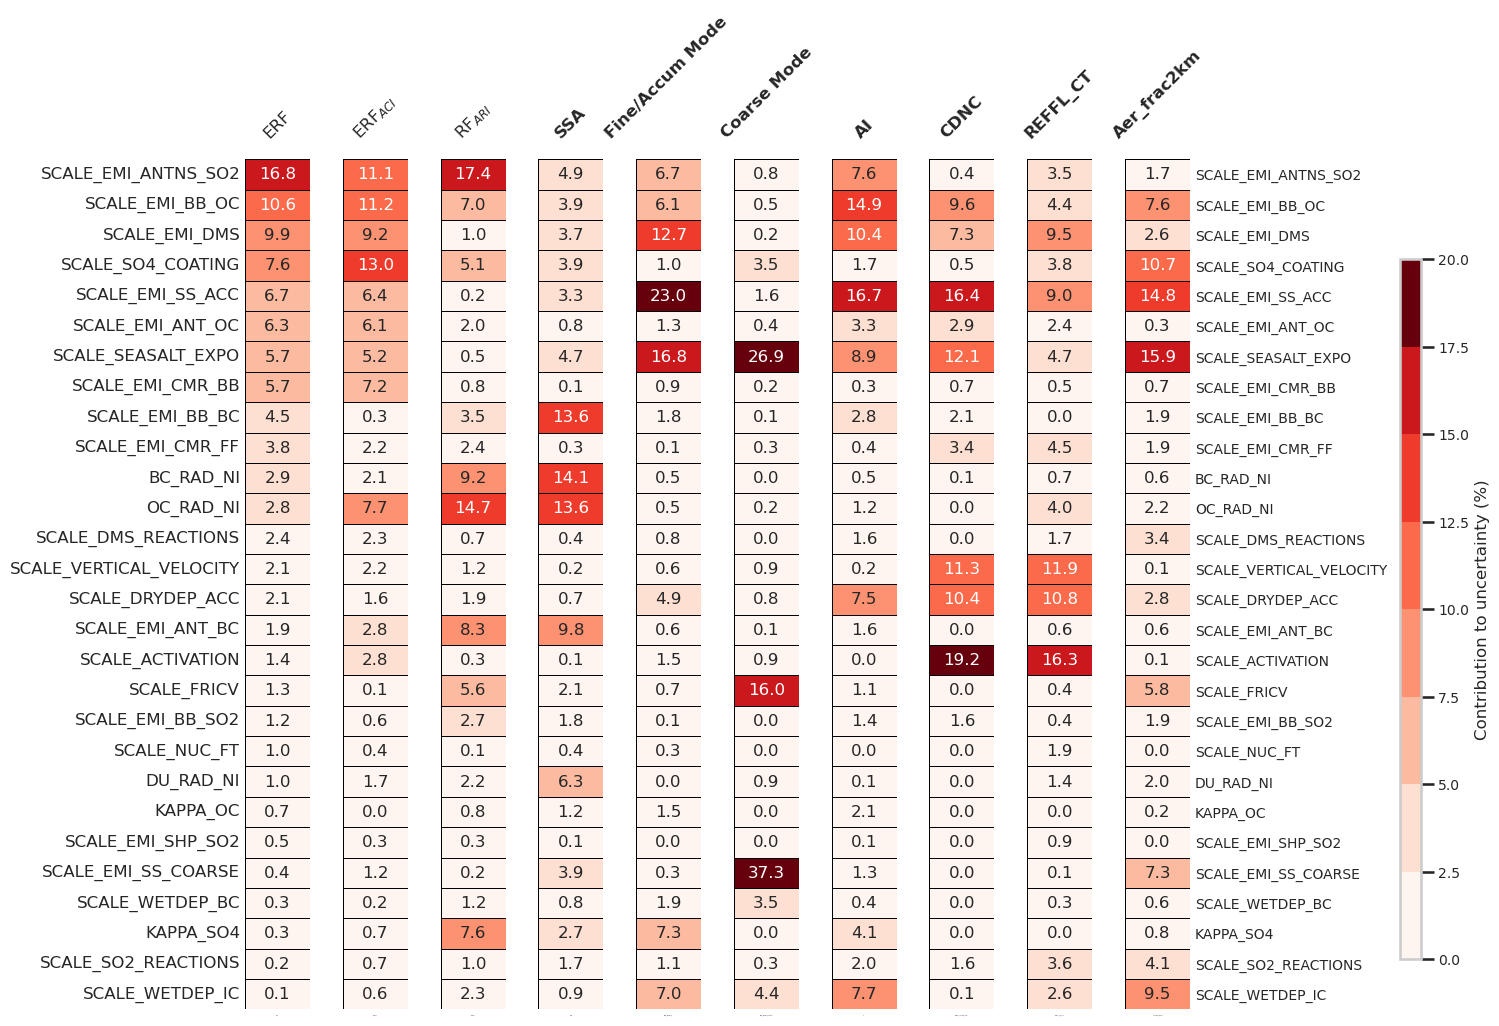

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Combined_Uncertainty_Contributionss = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/All_Uncertainty_Contributions_2000000.csv')
#Combined_Uncertainty_Contribution = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Uncertainty_Contributions_2000000.csv')
results_df = pd.read_csv("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Global_Annual_Uncertainty_Contributions_2000000_for_heatmap.csv")
results_df.set_index(results_df.columns[0], inplace=True)
results_df = pd.read_csv("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Global_Annual_Uncertainty_Contributions_2000000_for_heatmap_v2.csv")
results_df.set_index(results_df.columns[0], inplace=True)


Combined_Uncertainty_Contribution = (
    results_df
    .pivot_table(
        index='Variable',
        columns='Observation',
        values='Original_Uncertainty',
        aggfunc='sum'
    )
    .reset_index()
)

# df_merged from before
Combined_Uncertainty_Contributions = Combined_Uncertainty_Contribution.sort_values(
    by='ERF', ascending=False
)

# Melt to long format for plotting
results_all = Combined_Uncertainty_Contributions.melt(
    id_vars='Variable',
    var_name='Diagnostic',
    value_name='corrcoef'  # using your CSV numbers instead of computed correlation
)

# Clean parameter names
results_all["Parameter"] = results_all["Variable"].str.replace("SCALE_", "", regex=False)
#Diag = sorted(Combined_Uncertainty_Contributions["Diagnostic"].unique())

# Optional: define order of parameters
# params_order = sorted(results_all["Parameter"].unique())
# params_order = results_all[results_all['Diagnostic']=='ERF']\
#                 .sort_values('ERF', ascending=False)['Parameter'].tolist()
params_order = Combined_Uncertainty_Contributions['Variable'].values

diagnostics_order = [
    "ERF", "ERFaci", "ERFari", "SSA",
    "AOD_Mode_1", "AOD_Mode_Coarse",
    "AI", "CDNC_Filtered_OCI","REFFL_CT_OCI","TAU355_daily"
]
titles = [
    "ERF", "ERF$_{ACI}$", "RF$_{ARI}$",
    "SSA",
    "Fine/Accum Mode ",
    "Coarse Mode", "AI", "CDNC","REFFL_CT","Aer_frac2km"
]

# Plot heatmap
fig, axes = plt.subplots(1, len(diagnostics_order),
                         figsize=(7,10),
                         sharey=True)
plt.subplots_adjust(left=0.05, right=1.4, bottom=0.1, top=0.95, wspace=0.5)

if len(diagnostics_order) == 1:
    axes = [axes]

vlim = results_all['corrcoef'].max()
cmap = 'cividis'
bounds = [0, 5, 10, 15, 20]
cmap = mcolors.ListedColormap(["#fff5f0", "#fcbba1", "#fb6a4a", "#67000d"])  # light to dark red
bounds = np.arange(0, 22.5, 2.5)  # 0, 2.5, 5, ..., 20

# Generate a gradient of reds for each bin
colors = ["#fff5f0", "#fee0d2", "#fcbba1", "#fc9272", "#fb6a4a",
          "#ef3b2c", "#cb181d", "#67000d"]  # light to dark red
cmap = mcolors.LinearSegmentedColormap.from_list("red_gradient", colors, N=len(bounds)-1)

norm = mcolors.BoundaryNorm(bounds, cmap.N)
bold_titles = {    "SSA",
    "Fine/Accum Mode",
    "Coarse Mode", "AI", "CDNC","REFFL_CT","Aer_frac2km" }


for ax_i, (ax, diag) in enumerate(zip(axes, diagnostics_order)):
    sub = results_all[results_all["Diagnostic"] == diag]
    mat = sub.set_index('Parameter')['corrcoef'].values[:, np.newaxis]

    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        norm=norm,
        cbar=False,
        xticklabels=[diag],
        yticklabels=params_order,
        linewidths=0.5,
        linecolor="black",
        annot=np.round(mat, 1),  # <-- show numbers in each box
        fmt=".1f",
        annot_kws={"fontsize":12}
    )
    
    title_text = titles[ax_i]
    fw = "bold" if title_text in bold_titles else "normal"

    ax.text(
        0.5, 1.025,
        title_text,
        transform=ax.transAxes,
        fontsize=12,
        fontweight=fw,
        ha='center',
        rotation=45
    )


  #  ax.set_title(titles[ax_i], fontsize=7, pad=12, weight='bold',rotate=45)
    ax.set_xticklabels([diag], rotation=0, fontsize=0)
    ax.set_yticklabels(params_order, rotation=0, fontsize=12)
    ax.tick_params(axis='both', length=0)
    
    if ax_i == len(axes)-1:
        ax_right = ax.twinx()
        ax_right.set_ylim(ax.get_ylim())
        ax_right.set_yticks(np.arange(0.5, len(params_order)+0.5))
        ax_right.set_yticklabels(params_order, rotation=0, fontsize=10)
        ax_right.tick_params(axis='y', length=0)
        
        # Make spines and frame invisible
        for spine in ax_right.spines.values():
            spine.set_visible(False)
        ax_right.set_frame_on(False)
        
        # Remove horizontal grid lines that may be drawn by Seaborn
        ax_right.grid(False)

# Shared colorbar
cbar_ax = fig.add_axes([1.7, 0.15, 0.03, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=20))  # vmax fixed at 20
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Contribution to uncertainty (%)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig(f"/home/ybhatti2/Figures/Manuscript_Figures/Heat_Map_Contribution_Original_Final.png",dpi=100,bbox_inches = 'tight')
plt.show()

# Combined_Uncertainty_Contribution_filtered_ERF = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERF'] > 2.5
# ]
# Combined_Uncertainty_Contribution_filtered_ERFaci = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERFaci'] > 2.5
# ]
# Combined_Uncertainty_Contribution_filtered_ERFari = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERFari'] > 2.5
# ]

# # Convert to sets
# ERF_set    = set(Combined_Uncertainty_Contribution_filtered_ERF['Variable'])
# ERFaci_set = set(Combined_Uncertainty_Contribution_filtered_ERFaci['Variable'])
# ERFari_set = set(Combined_Uncertainty_Contribution_filtered_ERFari['Variable'])

# # Unique to each diagnostic
# unique_ERF    = ERF_set - (ERFaci_set | ERFari_set)
# unique_ERFaci = ERFaci_set - (ERF_set | ERFari_set)
# unique_ERFari = ERFari_set - (ERF_set | ERFaci_set)

# # Shared / others (appear in more than one diagnostic)
# others = (ERF_set & ERFaci_set) | (ERF_set & ERFari_set) | (ERFaci_set & ERFari_set)

# # Display
# print("Unique to ERF:", sorted(unique_ERF))
# print("Unique to ERFaci:", sorted(unique_ERFaci))
# print("Unique to ERFari:", sorted(unique_ERFari))
# print("Shared (others):", sorted(others))

# # 1. Combine interesting parameters
# interesting_params = sorted(ERF_set | ERFaci_set | ERFari_set)
# print("Interesting parameters:", interesting_params)


/scratch-local/ybhatti2.18487745/ipykernel_1732400/1316625376.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])
/scratch-local/ybhatti2.18487745/ipykernel_1732400/1316625376.py:146: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 0.91, 1])


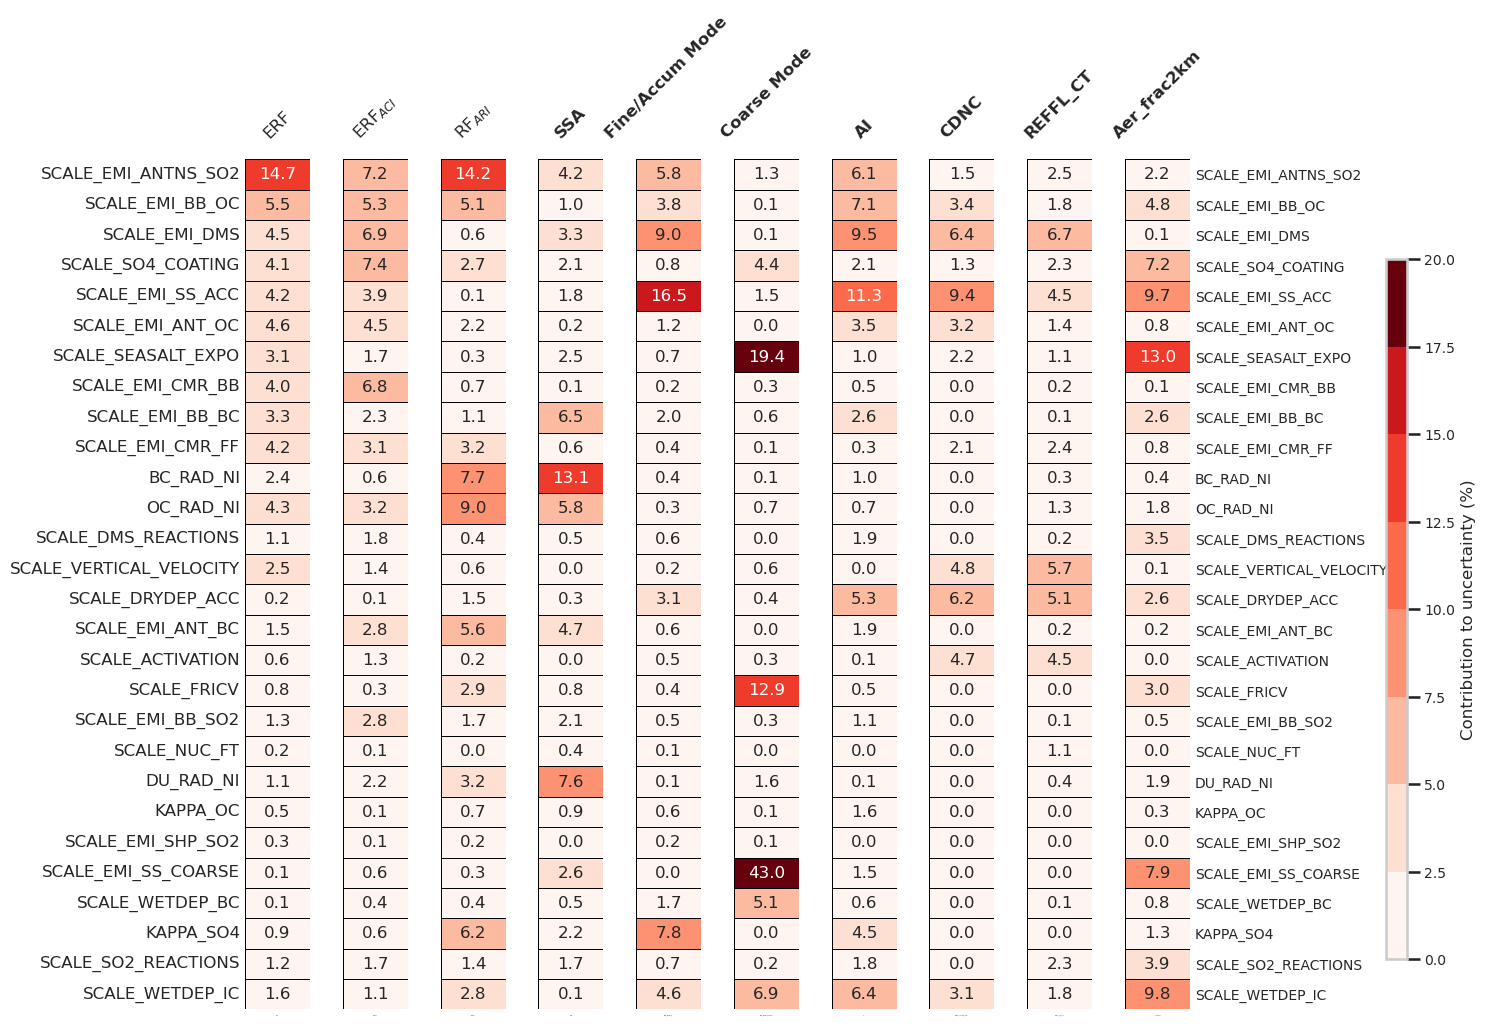

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Combined_Uncertainty_Contributionss = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/All_Uncertainty_Contributions_2000000.csv')
#Combined_Uncertainty_Contribution = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Uncertainty_Contributions_2000000.csv')

Combined_Uncertainty_Contribution = (
    results_df
    .pivot_table(
        index='Variable',
        columns='Observation',
        values='Constrained_Uncertainty',
        aggfunc='sum'
    )
    .reset_index()
)

# df_merged from before
# Combined_Uncertainty_Contributions = Combined_Uncertainty_Contribution.sort_values(
#     by='ERF', ascending=False
# )

Combined_Uncertainty_Contributions = (
    Combined_Uncertainty_Contribution
    .set_index('Variable')
    .reindex(params_order)
    .reset_index()
)

# Melt to long format for plotting
results_all = Combined_Uncertainty_Contributions.melt(
    id_vars='Variable',
    var_name='Diagnostic',
    value_name='corrcoef'  # using your CSV numbers instead of computed correlation
)

# Clean parameter names
results_all["Parameter"] = results_all["Variable"].str.replace("SCALE_", "", regex=False)
#Diag = sorted(Combined_Uncertainty_Contributions["Diagnostic"].unique())

# Optional: define order of parameters
# params_order = sorted(results_all["Parameter"].unique())
# params_order = results_all[results_all['Diagnostic']=='ERF']\
#                 .sort_values('ERF', ascending=False)['Parameter'].tolist()
#params_order = Combined_Uncertainty_Contributions['Variable'].values

diagnostics_order = [
    "ERF", "ERFaci", "ERFari", "SSA",
    "AOD_Mode_1", "AOD_Mode_Coarse",
    "AI", "CDNC_Filtered_OCI","REFFL_CT_OCI","TAU355"
]
titles = [Global_Annual_Uncertainty_Contributions_2000000_for_heatmap
    "ERF", "ERF$_{ACI}$", "RF$_{ARI}$",
    "SSA",
    "Fine/Accum Mode ",
    "Coarse Mode", "AI", "CDNC","REFFL_CT","Aer_frac2km"
]

# Plot heatmap
fig, axes = plt.subplots(1, len(diagnostics_order),
                         figsize=(7,10),
                         sharey=True)
plt.subplots_adjust(left=0.05, right=1.4, bottom=0.1, top=0.95, wspace=0.5)

if len(diagnostics_order) == 1:
    axes = [axes]

vlim = results_all['corrcoef'].max()
cmap = 'cividis'
bounds = [0, 5, 10, 15, 20]
cmap = mcolors.ListedColormap(["#fff5f0", "#fcbba1", "#fb6a4a", "#67000d"])  # light to dark red
bounds = np.arange(0, 22.5, 2.5)  # 0, 2.5, 5, ..., 20

# Generate a gradient of reds for each bin
colors = ["#fff5f0", "#fee0d2", "#fcbba1", "#fc9272", "#fb6a4a",
          "#ef3b2c", "#cb181d", "#67000d"]  # light to dark red
cmap = mcolors.LinearSegmentedColormap.from_list("red_gradient", colors, N=len(bounds)-1)

norm = mcolors.BoundaryNorm(bounds, cmap.N)
bold_titles = {    "SSA",
    "Fine/Accum Mode ",
    "Coarse Mode", "AI", "CDNC","REFFL_CT","Aer_frac2km" }


for ax_i, (ax, diag) in enumerate(zip(axes, diagnostics_order)):
    sub = results_all[results_all["Diagnostic"] == diag]
    mat = sub.set_index('Parameter')['corrcoef'].values[:, np.newaxis]

    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        norm=norm,
        cbar=False,
        xticklabels=[diag],
        yticklabels=params_order,
        linewidths=0.5,
        linecolor="black",
        annot=np.round(mat, 1),  # <-- show numbers in each box
        fmt=".1f",
        annot_kws={"fontsize":12}
    )
    
    title_text = titles[ax_i]
    fw = "bold" if title_text in bold_titles else "normal"

    ax.text(
        0.5, 1.025,
        title_text,
        transform=ax.transAxes,
        fontsize=12,
        fontweight=fw,
        ha='center',
        rotation=45
    )


  #  ax.set_title(titles[ax_i], fontsize=7, pad=12, weight='bold',rotate=45)
    ax.set_xticklabels([diag], rotation=0, fontsize=0)
    ax.set_yticklabels(params_order, rotation=0, fontsize=12)
    ax.tick_params(axis='both', length=0)
    
    if ax_i == len(axes)-1:
        ax_right = ax.twinx()
        ax_right.set_ylim(ax.get_ylim())
        ax_right.set_yticks(np.arange(0.5, len(params_order)+0.5))
        ax_right.set_yticklabels(params_order, rotation=0, fontsize=10)
        ax_right.tick_params(axis='y', length=0)
        
        # Make spines and frame invisible
        for spine in ax_right.spines.values():
            spine.set_visible(False)
        ax_right.set_frame_on(False)
        
        # Remove horizontal grid lines that may be drawn by Seaborn
        ax_right.grid(False)

# Shared colorbar
cbar_ax = fig.add_axes([1.68, 0.15, 0.03, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=20))  # vmax fixed at 20
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Contribution to uncertainty (%)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig(f"/home/ybhatti2/Figures/Manuscript_Figures/Heat_Map_Contribution_Constrained_Final.png",dpi=100,bbox_inches = 'tight')
plt.show()

# Combined_Uncertainty_Contribution_filtered_ERF = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERF'] > 2.5
# ]
# Combined_Uncertainty_Contribution_filtered_ERFaci = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERFaci'] > 2.5
# ]
# Combined_Uncertainty_Contribution_filtered_ERFari = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERFari'] > 2.5
# ]

# # Convert to sets
# ERF_set    = set(Combined_Uncertainty_Contribution_filtered_ERF['Variable'])
# ERFaci_set = set(Combined_Uncertainty_Contribution_filtered_ERFaci['Variable'])
# ERFari_set = set(Combined_Uncertainty_Contribution_filtered_ERFari['Variable'])

# # Unique to each diagnostic
# unique_ERF    = ERF_set - (ERFaci_set | ERFari_set)
# unique_ERFaci = ERFaci_set - (ERF_set | ERFari_set)
# unique_ERFari = ERFari_set - (ERF_set | ERFaci_set)

# # Shared / others (appear in more than one diagnostic)
# others = (ERF_set & ERFaci_set) | (ERF_set & ERFari_set) | (ERFaci_set & ERFari_set)

# # Display
# print("Unique to ERF:", sorted(unique_ERF))
# print("Unique to ERFaci:", sorted(unique_ERFaci))
# print("Unique to ERFari:", sorted(unique_ERFari))
# print("Shared (others):", sorted(others))

# # 1. Combine interesting parameters
# interesting_params = sorted(ERF_set | ERFaci_set | ERFari_set)
# print("Interesting parameters:", interesting_params)


/scratch-local/ybhatti2.18487745/ipykernel_1732400/582191029.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])
/scratch-local/ybhatti2.18487745/ipykernel_1732400/582191029.py:143: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 0.91, 1])


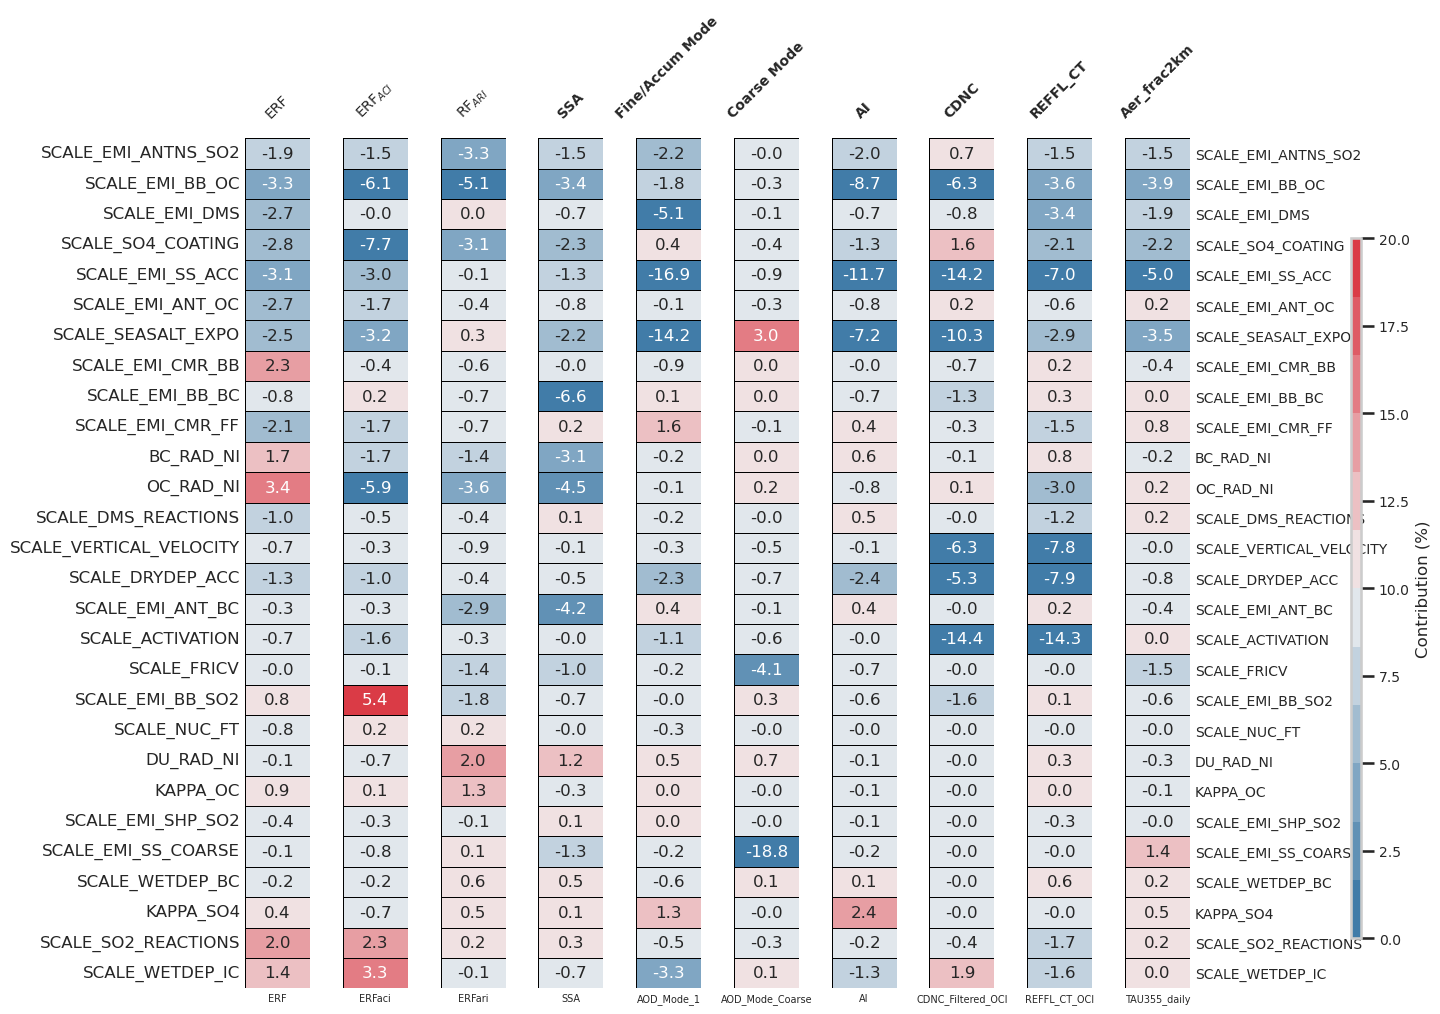

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Combined_Uncertainty_Contributionss = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/All_Uncertainty_Contributions_2000000.csv')
#Combined_Uncertainty_Contribution = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Uncertainty_Contributions_2000000.csv')

Combined_Uncertainty_Contribution = (
    results_df
    .pivot_table(
        index='Variable',
        columns='Observation',
        values='Delta',
        aggfunc='sum'
    )
    .reset_index()
)

# df_merged from before
# Combined_Uncertainty_Contributions = Combined_Uncertainty_Contribution.sort_values(
#     by='ERF', ascending=False
# )

Combined_Uncertainty_Contributions = (
    Combined_Uncertainty_Contribution
    .set_index('Variable')
    .reindex(params_order)
    .reset_index()
)

# Melt to long format for plotting
results_all = Combined_Uncertainty_Contributions.melt(
    id_vars='Variable',
    var_name='Diagnostic',
    value_name='corrcoef'  # using your CSV numbers instead of computed correlation
)

# Clean parameter names
results_all["Parameter"] = results_all["Variable"].str.replace("SCALE_", "", regex=False)
#Diag = sorted(Combined_Uncertainty_Contributions["Diagnostic"].unique())

# Optional: define order of parameters
# params_order = sorted(results_all["Parameter"].unique())
# params_order = results_all[results_all['Diagnostic']=='ERF']\
#                 .sort_values('ERF', ascending=False)['Parameter'].tolist()
#params_order = Combined_Uncertainty_Contributions['Variable'].values

diagnostics_order = [
    "ERF", "ERFaci", "ERFari", "SSA",
    "AOD_Mode_1", "AOD_Mode_Coarse",
    "AI", "CDNC_Filtered_OCI","REFFL_CT_OCI","TAU355_daily"
]

titles = [
    "ERF", "ERF$_{ACI}$", "RF$_{ARI}$",
    "SSA",
    "Fine/Accum Mode ",
    "Coarse Mode", "AI", "CDNC","REFFL_CT","Aer_frac2km"
]

# Plot heatmap
fig, axes = plt.subplots(1, len(diagnostics_order),
                         figsize=(7,10),
                         sharey=True)
plt.subplots_adjust(left=0.05, right=1.4, bottom=0.1, top=0.95, wspace=0.5)

if len(diagnostics_order) == 1:
    axes = [axes]

vlim = results_all['corrcoef'].max()
cmap = 'cividis'
bounds = [0, 5, 10, 15, 20]
cmap = mcolors.ListedColormap(["#fff5f0", "#fcbba1", "#fb6a4a", "#67000d"])  # light to dark red
bounds = np.arange(-6, 6+1, 1)
colors = sns.diverging_palette(240, 10, n=len(bounds)-1, as_cmap=False)  # blue to red
cmap = mcolors.LinearSegmentedColormap.from_list("diverging_red_blue", colors, N=len(bounds)-1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
bold_titles = {    "SSA",
    "Fine/Accum Mode ",
    "Coarse Mode", "AI", "CDNC","REFFL_CT","Aer_frac2km" }


for ax_i, (ax, diag) in enumerate(zip(axes, diagnostics_order)):
    sub = results_all[results_all["Diagnostic"] == diag]
    mat = sub.set_index('Parameter')['corrcoef'].values[:, np.newaxis]

    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        norm=norm,
        cbar=False,
        xticklabels=[diag],
        yticklabels=params_order,
        linewidths=0.5,
        linecolor="black",
        annot=np.round(mat, 1),  # <-- show numbers in each box
        fmt=".1f",
        annot_kws={"fontsize":12}
    )
    
    title_text = titles[ax_i]
    fw = "bold" if title_text in bold_titles else "normal"

    ax.text(
        0.5, 1.025,
        title_text,
        transform=ax.transAxes,
        fontsize=10,
        fontweight=fw,
        ha='center',
        rotation=45
    )


  #  ax.set_title(titles[ax_i], fontsize=7, pad=12, weight='bold',rotate=45)
    ax.set_xticklabels([diag], rotation=0, fontsize=7)
    ax.set_yticklabels(params_order, rotation=0, fontsize=12)
    ax.tick_params(axis='both', length=0)
    
    if ax_i == len(axes)-1:
        ax_right = ax.twinx()
        ax_right.set_ylim(ax.get_ylim())
        ax_right.set_yticks(np.arange(0.5, len(params_order)+0.5))
        ax_right.set_yticklabels(params_order, rotation=0, fontsize=10)
        ax_right.tick_params(axis='y', length=0)
        
        # Make spines and frame invisible
        for spine in ax_right.spines.values():
            spine.set_visible(False)
        ax_right.set_frame_on(False)
        
        # Remove horizontal grid lines that may be drawn by Seaborn
        ax_right.grid(False)

# Shared colorbar
cbar_ax = fig.add_axes([1.63, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=20))  # vmax fixed at 20
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Contribution (%)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Heat_Map_Contribution_Constrained_Diff_Final.png",
           dpi=100, bbox_inches='tight')
plt.show()

# Combined_Uncertainty_Contribution_filtered_ERF = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERF'] > 2.5
# ]
# Combined_Uncertainty_Contribution_filtered_ERFaci = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERFaci'] > 2.5
# ]
# Combined_Uncertainty_Contribution_filtered_ERFari = Combined_Uncertainty_Contribution[
#     Combined_Uncertainty_Contribution['ERFari'] > 2.5
# ]

# # Convert to sets
# ERF_set    = set(Combined_Uncertainty_Contribution_filtered_ERF['Variable'])
# ERFaci_set = set(Combined_Uncertainty_Contribution_filtered_ERFaci['Variable'])
# ERFari_set = set(Combined_Uncertainty_Contribution_filtered_ERFari['Variable'])

# # Unique to each diagnostic
# unique_ERF    = ERF_set - (ERFaci_set | ERFari_set)
# unique_ERFaci = ERFaci_set - (ERF_set | ERFari_set)
# unique_ERFari = ERFari_set - (ERF_set | ERFaci_set)

# # Shared / others (appear in more than one diagnostic)
# others = (ERF_set & ERFaci_set) | (ERF_set & ERFari_set) | (ERFaci_set & ERFari_set)

# # Display
# print("Unique to ERF:", sorted(unique_ERF))
# print("Unique to ERFaci:", sorted(unique_ERFaci))
# print("Unique to ERFari:", sorted(unique_ERFari))
# print("Shared (others):", sorted(others))

# # 1. Combine interesting parameters
# interesting_params = sorted(ERF_set | ERFaci_set | ERFari_set)
# print("Interesting parameters:", interesting_params)


Plotting AOD_Mode_1: 3856 accepted members


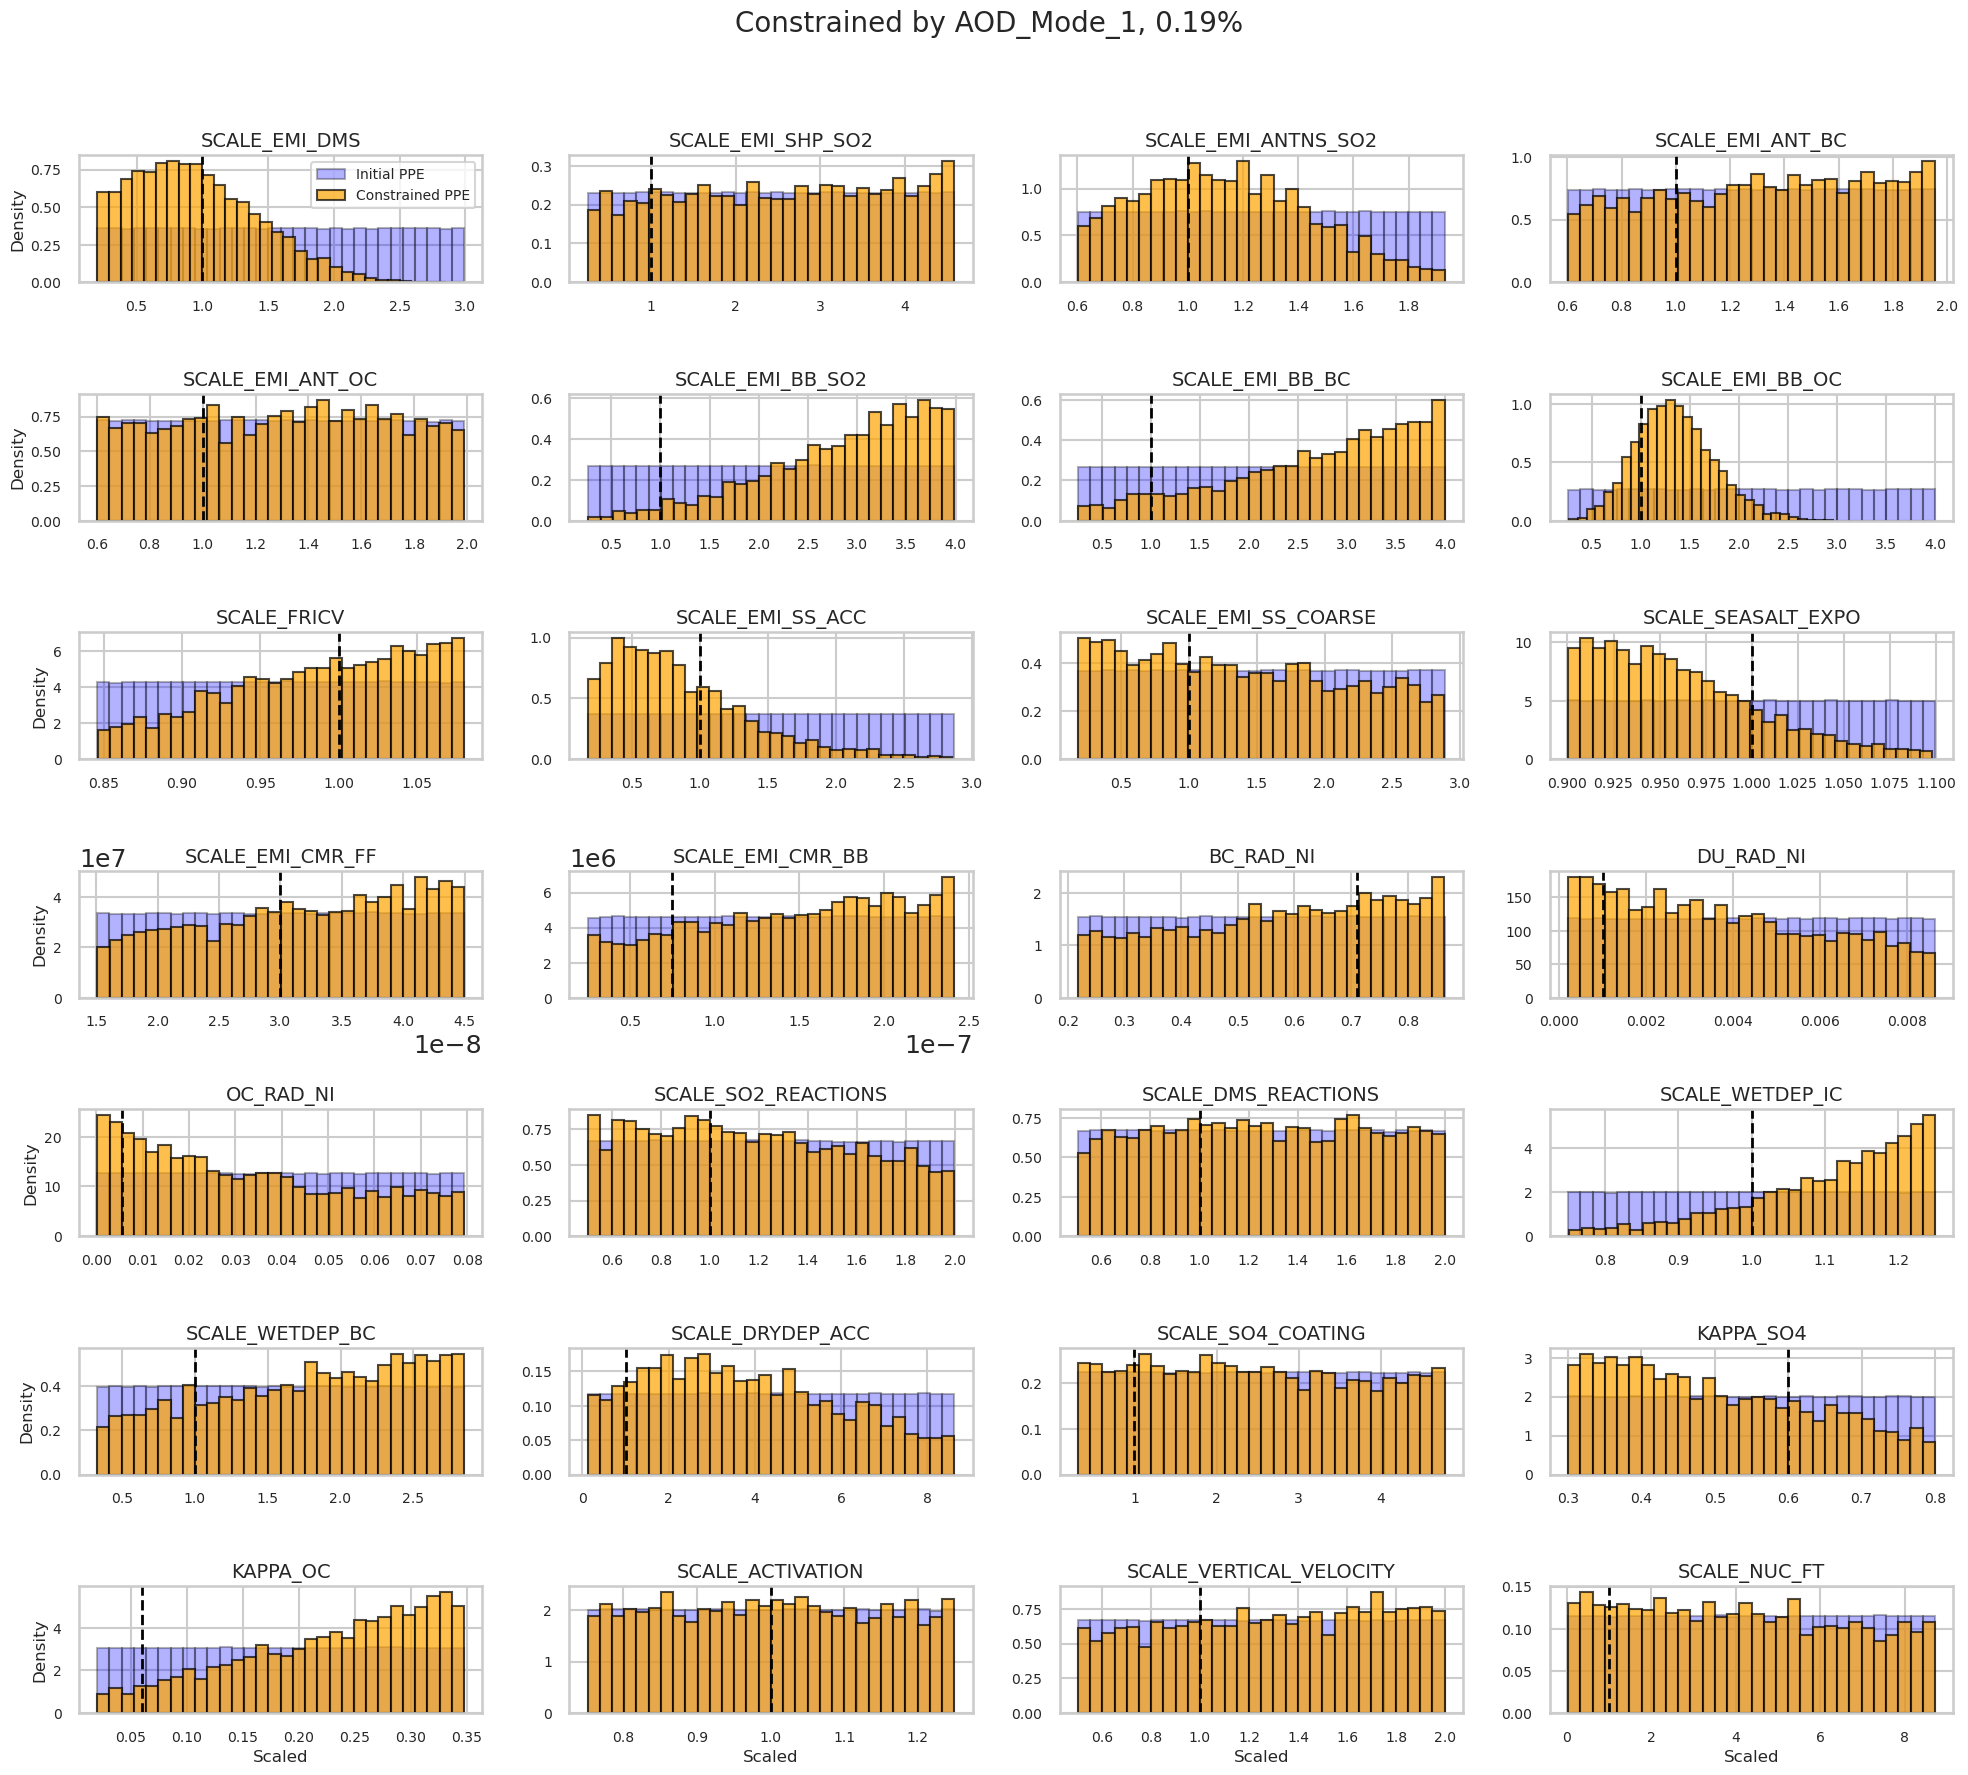

Plotting AOD_Mode_Coarse: 7694 accepted members


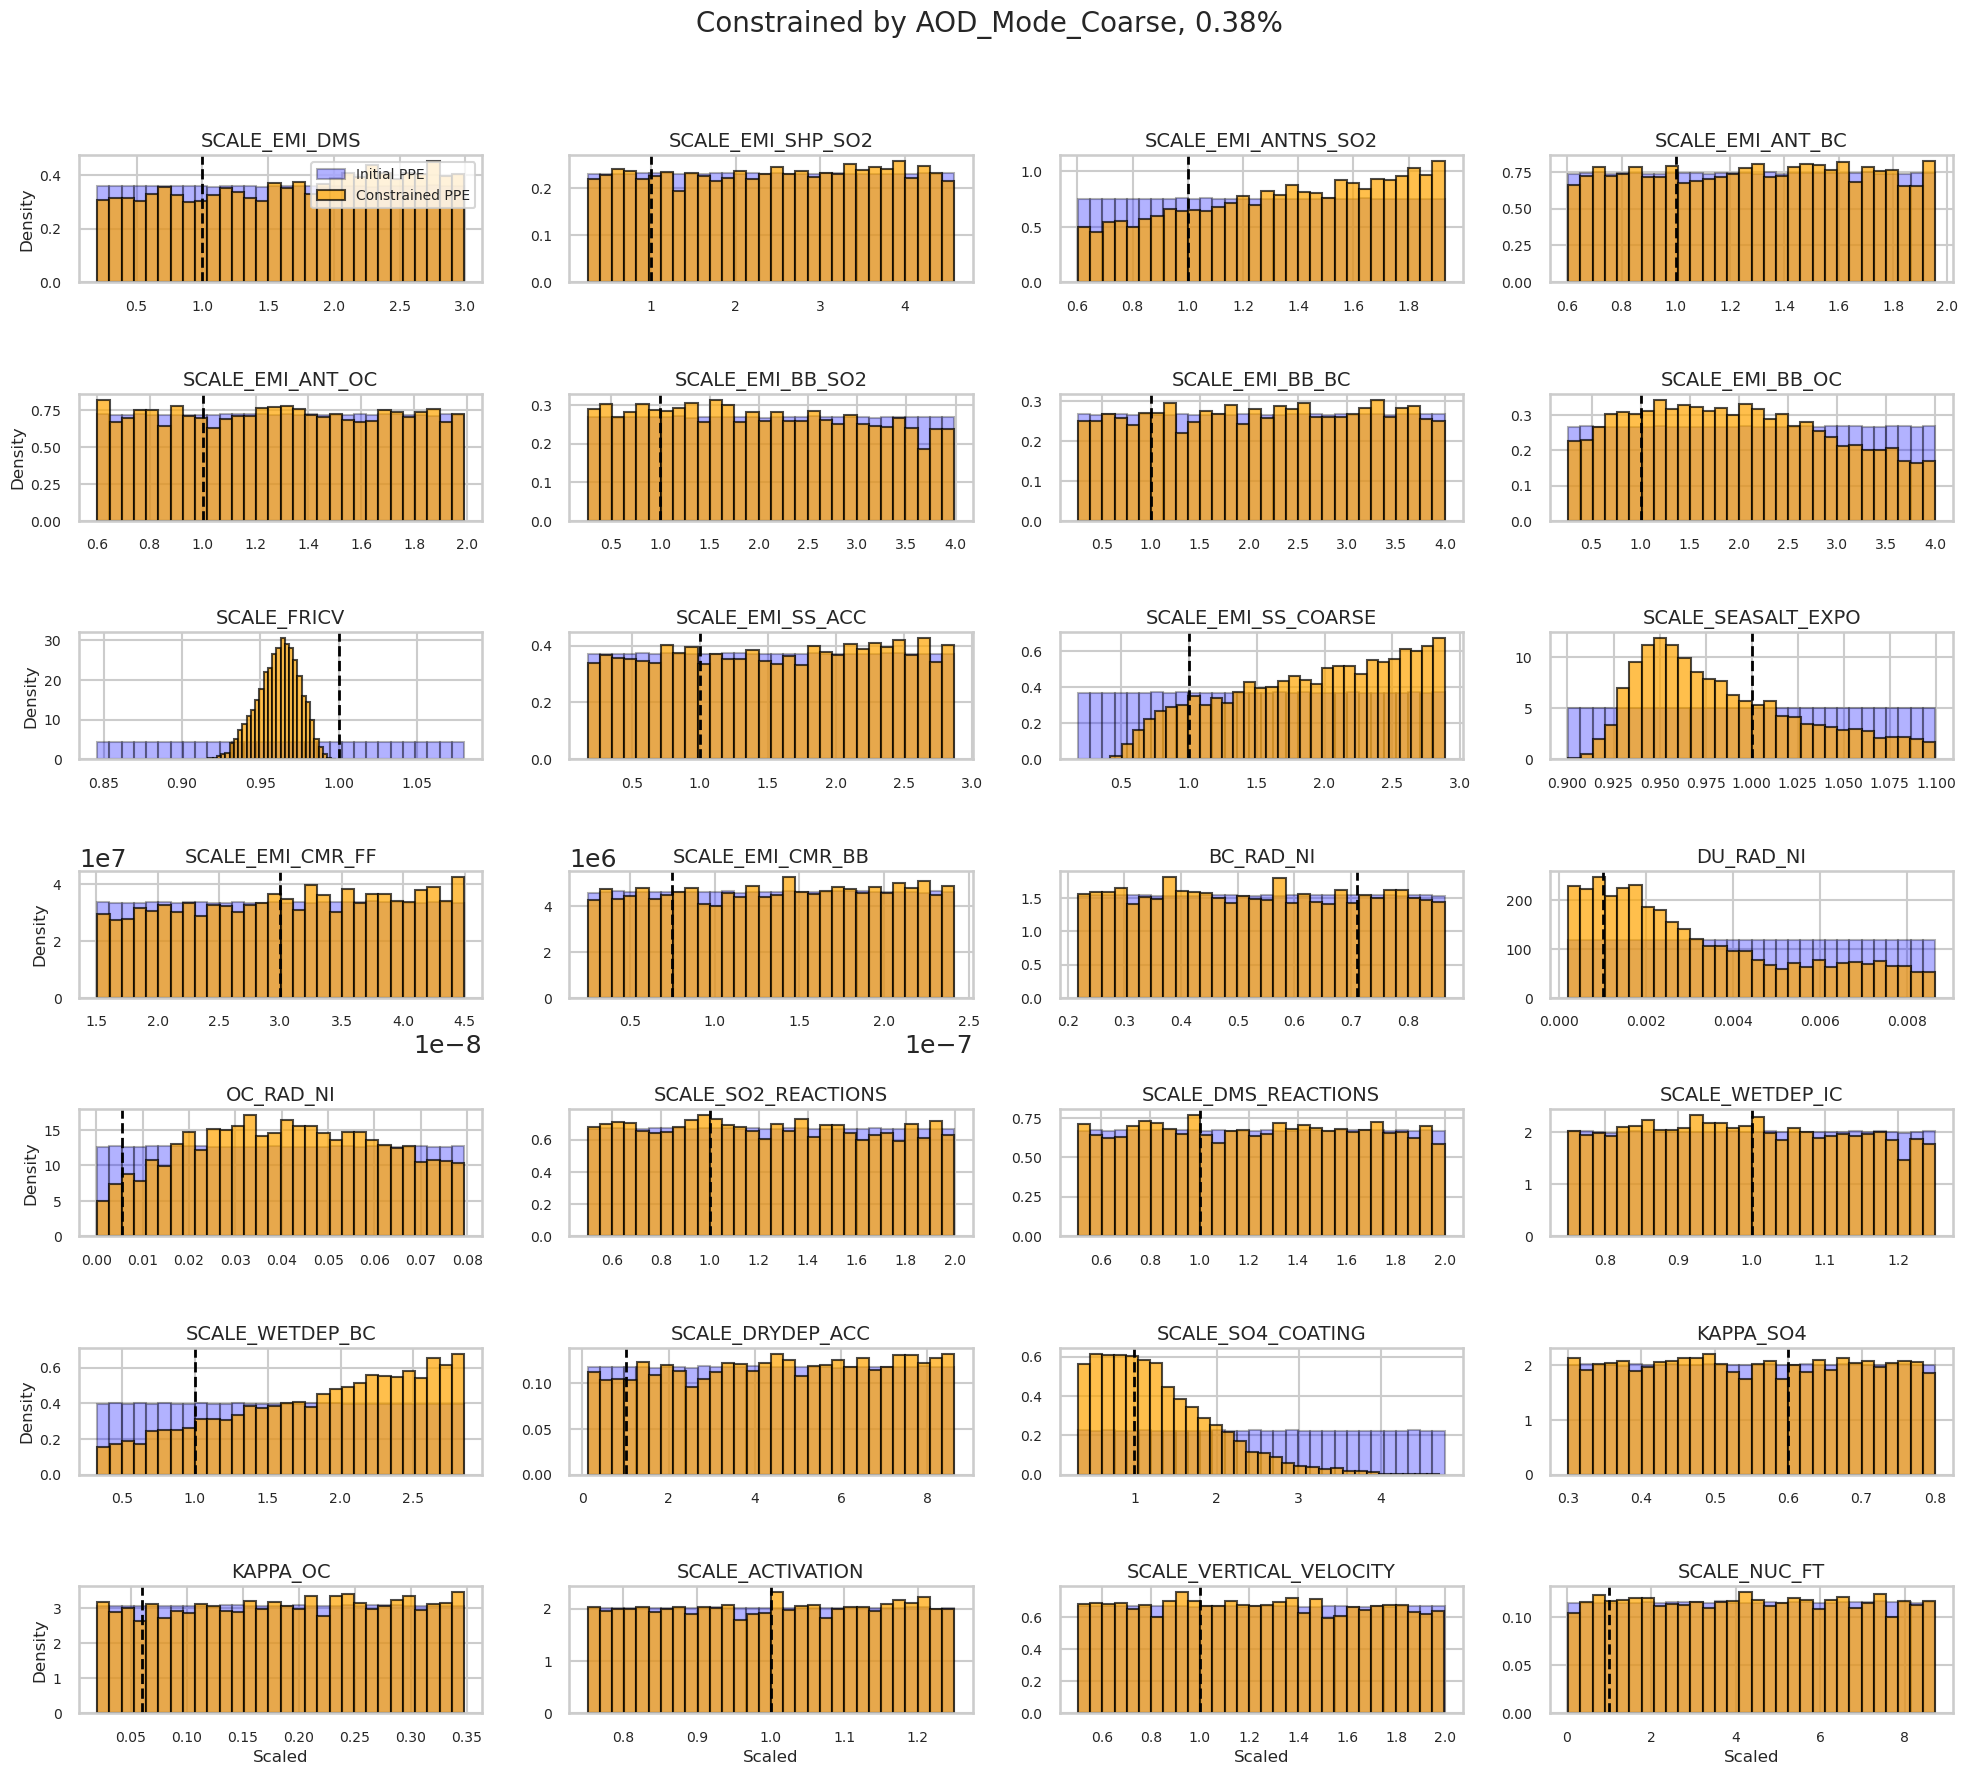

Plotting SSA: 456 accepted members


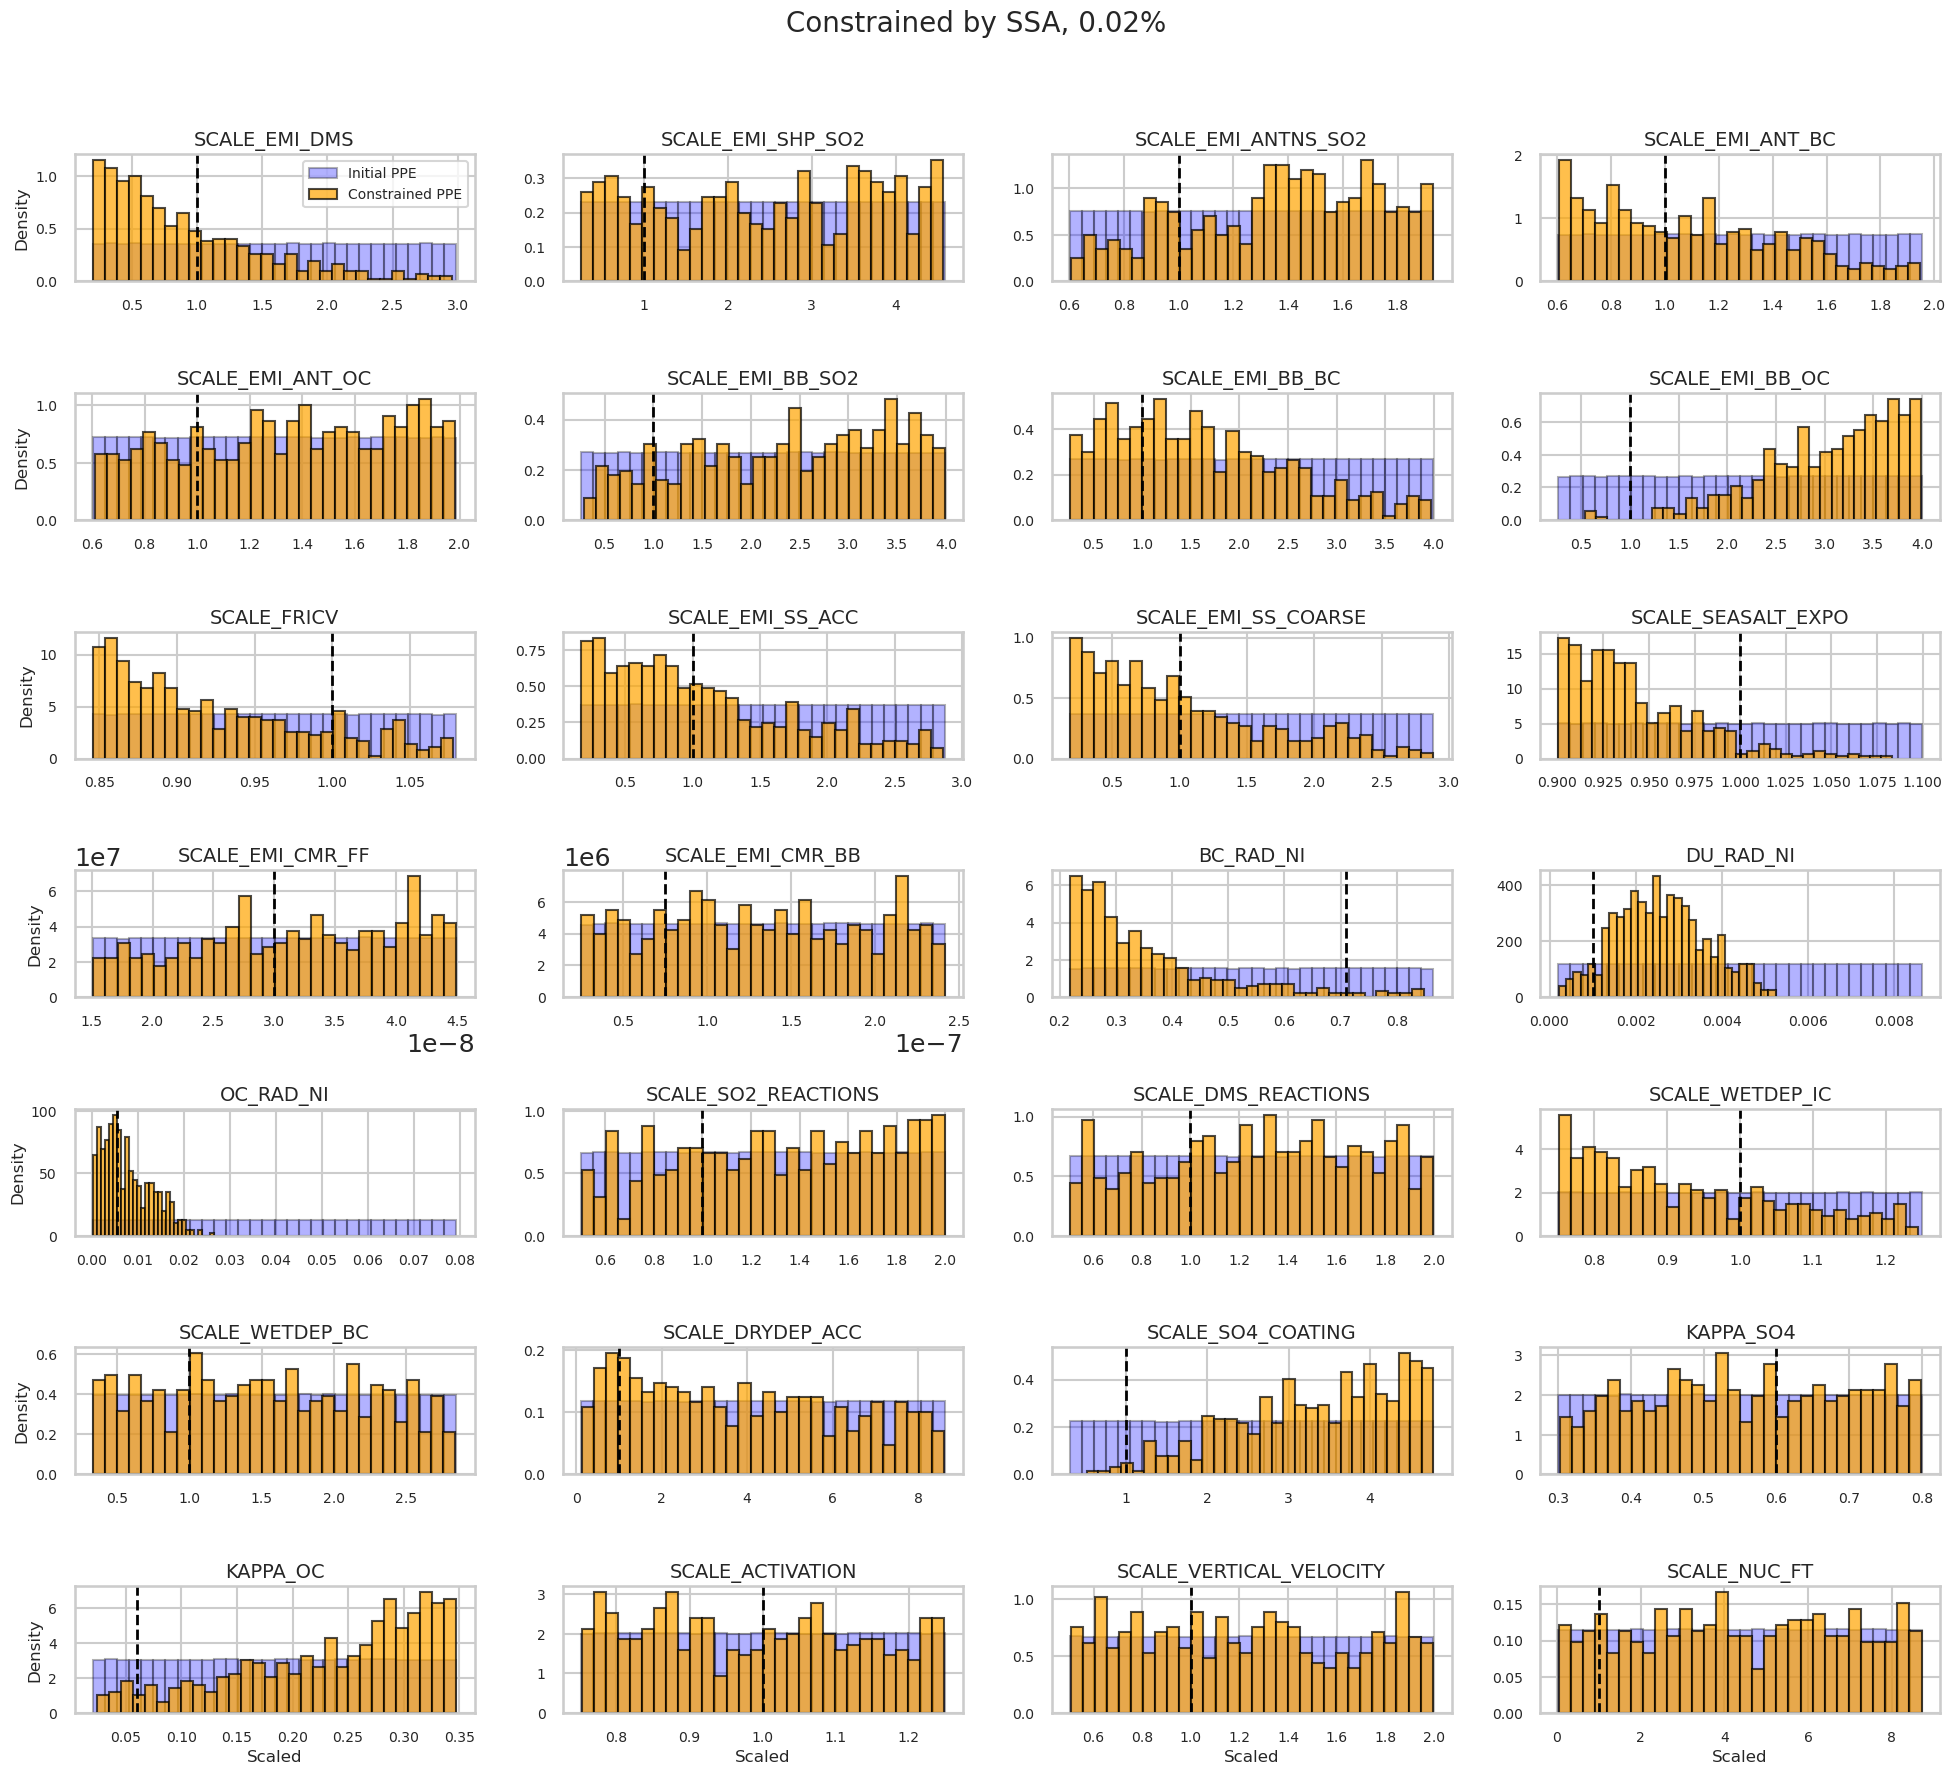

Plotting AI: 4010 accepted members


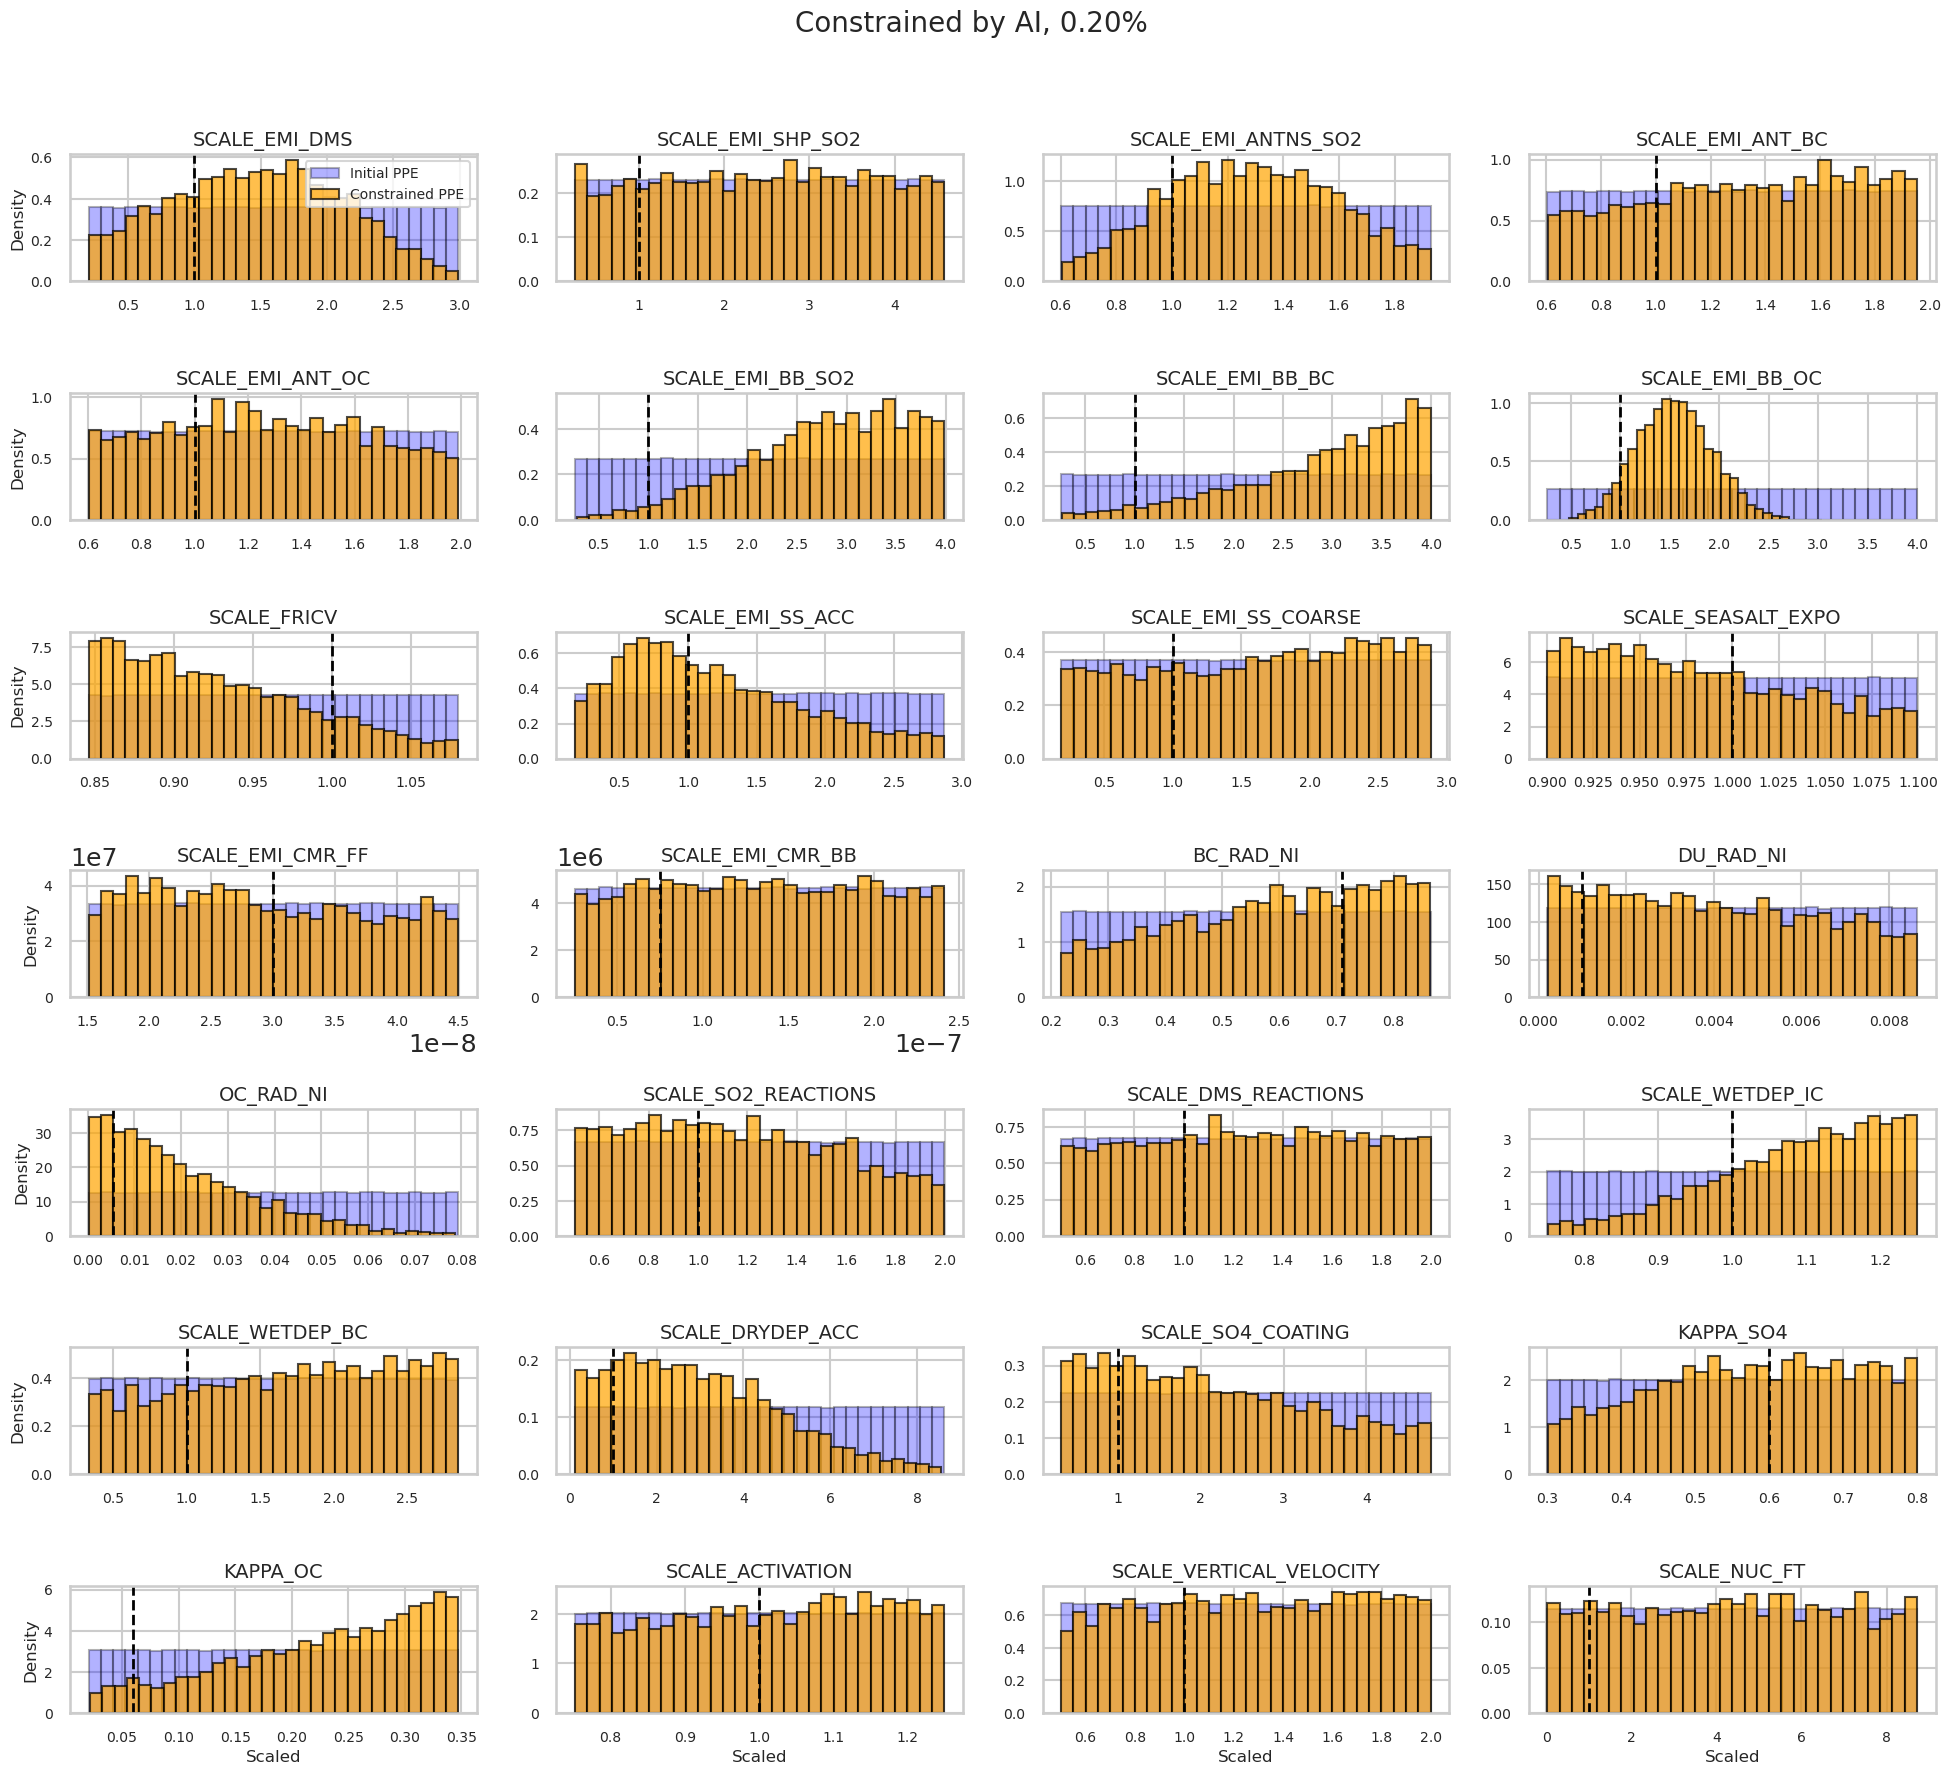

Plotting TAU355_daily: 11900 accepted members


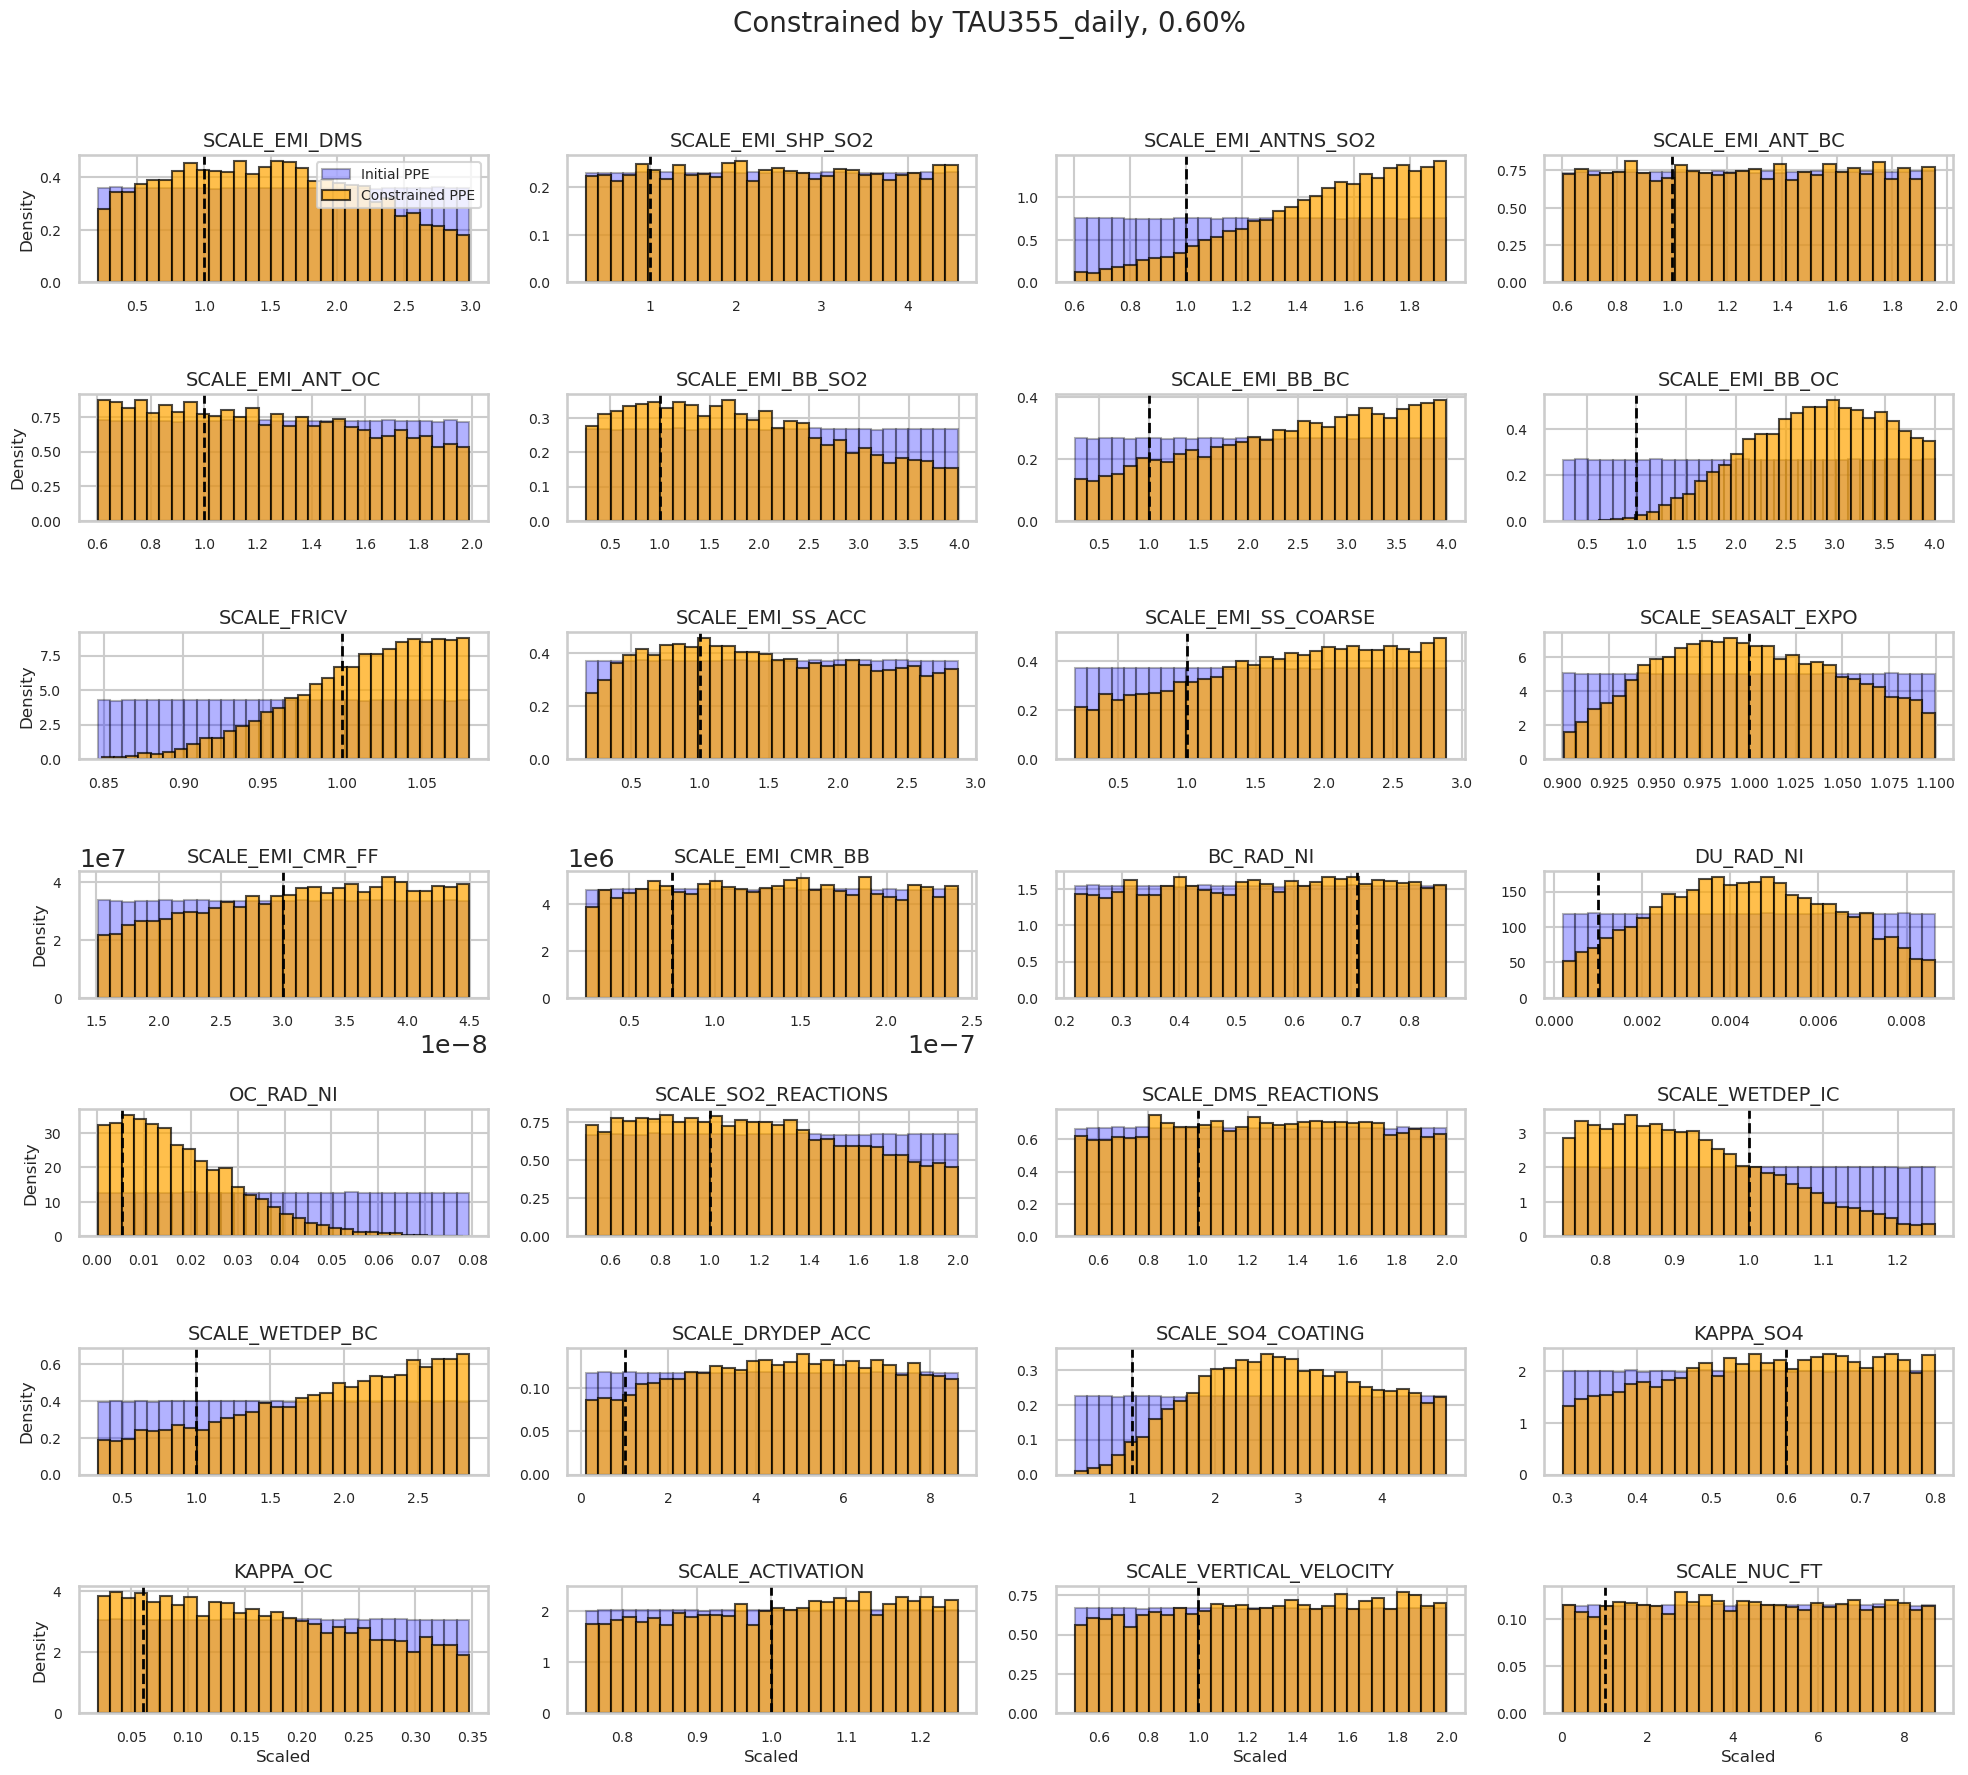

Plotting CDNC_Filtered_OCI: 238944 accepted members


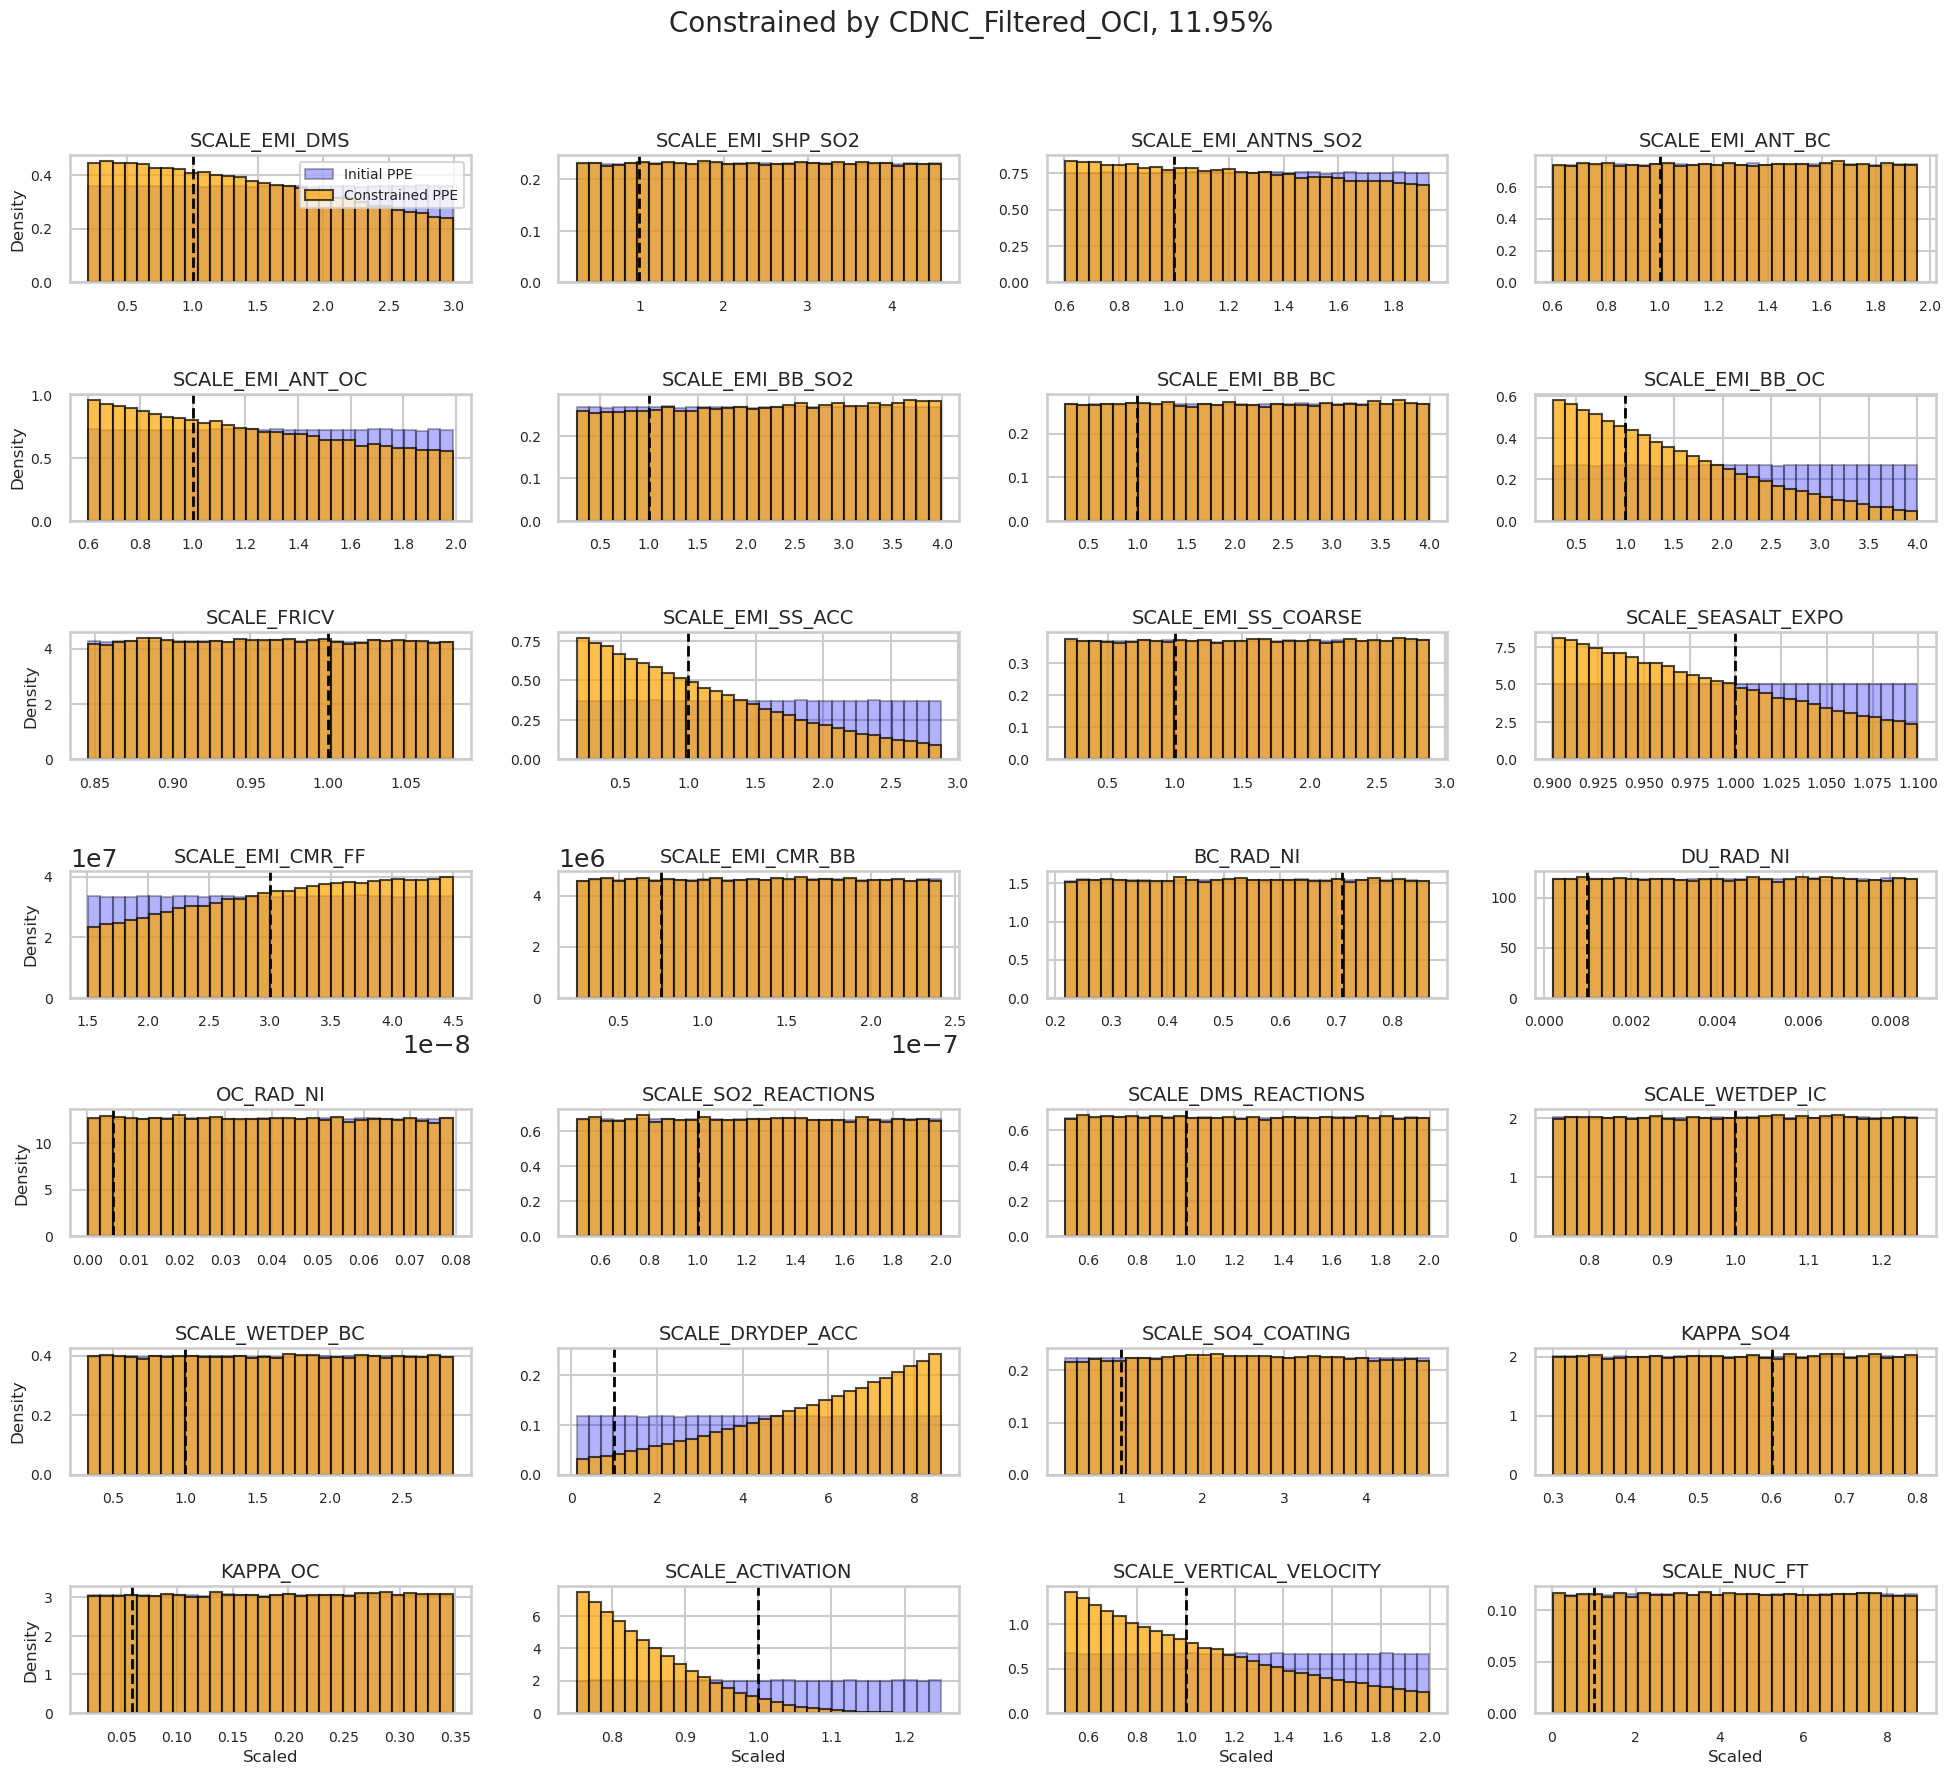

In [19]:
n_samples_new = 2000000

for name, ens in zip(stored_best_var,stored_best):
    print(f"Plotting {name}: {len(ens)} accepted members")


    shared_dataset_Southern_Ocean = ppe_non_normalized_new_samples.iloc[ens]
    control_values = ppe_non_normalized_new_samples.iloc[0]

    num_cols = len(shared_dataset_Southern_Ocean.columns)
    cols_per_row = 4
    rows = num_cols // cols_per_row + int(num_cols % cols_per_row > 0)

    # ---- FIRST PASS: get ymax ----
    ymax = 0
    for col in shared_dataset_Southern_Ocean.columns:
        n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
        n_shared, _, _ = plt.hist(shared_dataset_Southern_Ocean[col], bins=30, density=True)
        ymax = max(ymax, n_full.max(), n_shared.max())
    plt.close()

    # ---- SECOND PASS: plotting ----
    fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(20, rows * 2.5))
    axes = axes.flatten()

    for i, col in enumerate(shared_dataset_Southern_Ocean.columns):
        ax = axes[i]

        # Full ensemble
        ppe_non_normalized_new_samples[col].hist(
            ax=ax, bins=30, edgecolor='black',
            color='blue', alpha=0.3, density=True, label='Initial PPE'
        )

        # Accepted ensemble
        shared_dataset_Southern_Ocean[col].hist(
            ax=ax, bins=30, edgecolor='black',
            color='orange', alpha=0.7, density=True, label='Constrained PPE'
        )

        # Control
        ax.axvline(control_values[col], color="black", linestyle="--", linewidth=2)

        ax.set_title(col, fontsize=14)

        if i % cols_per_row == 0:
            ax.set_ylabel('Density', fontsize=12)
        else:
            ax.set_ylabel('')

        if i < (rows - 1) * cols_per_row:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Scaled', fontsize=12)

        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        if i == 0:
            ax.legend(fontsize=10)

    # Remove leftover empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    #plt.suptitle(f"Constrained by {name}", fontsize=18)
    plt.suptitle(f"Constrained by {name}, {(len(ens) / n_samples_new) * 100:.2f}%", fontsize=20, y=1.02)

    plt.tight_layout()
    #plt.savefig(f"/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Least_Square/{name}_pdf_distributions_Least_Square.png",dpi=100,bbox_inches = 'tight')
    plt.show()


Plotting AOD_Mode_1: 3856 accepted members


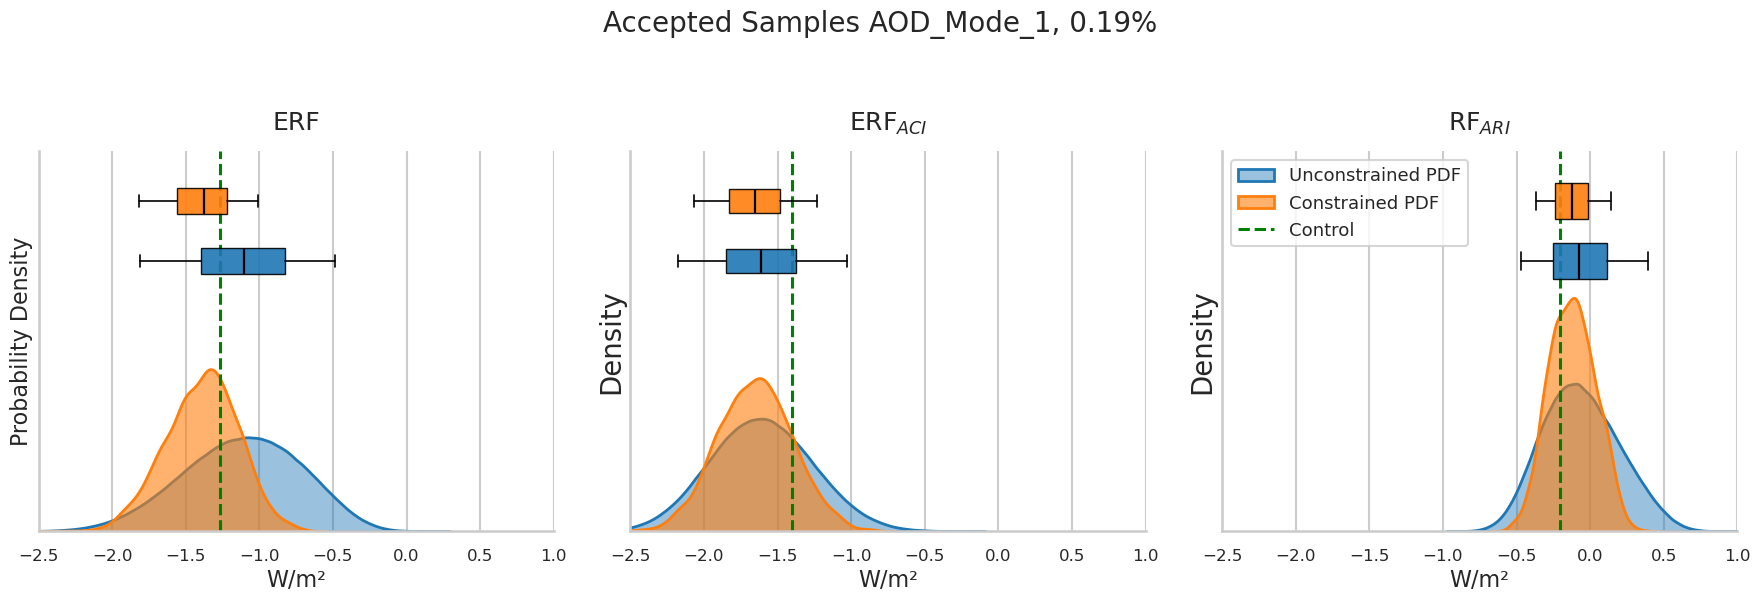

Plotting AOD_Mode_Coarse: 7694 accepted members


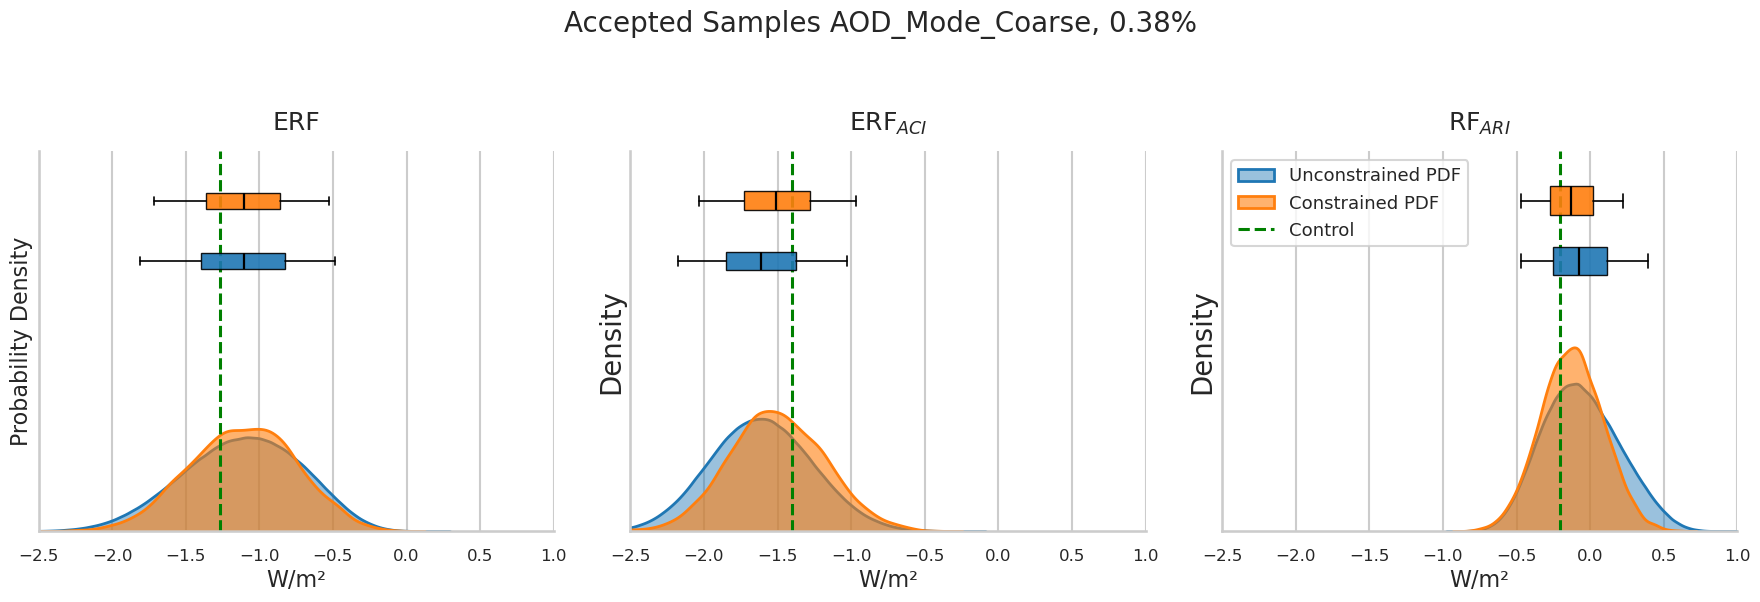

Plotting SSA: 456 accepted members


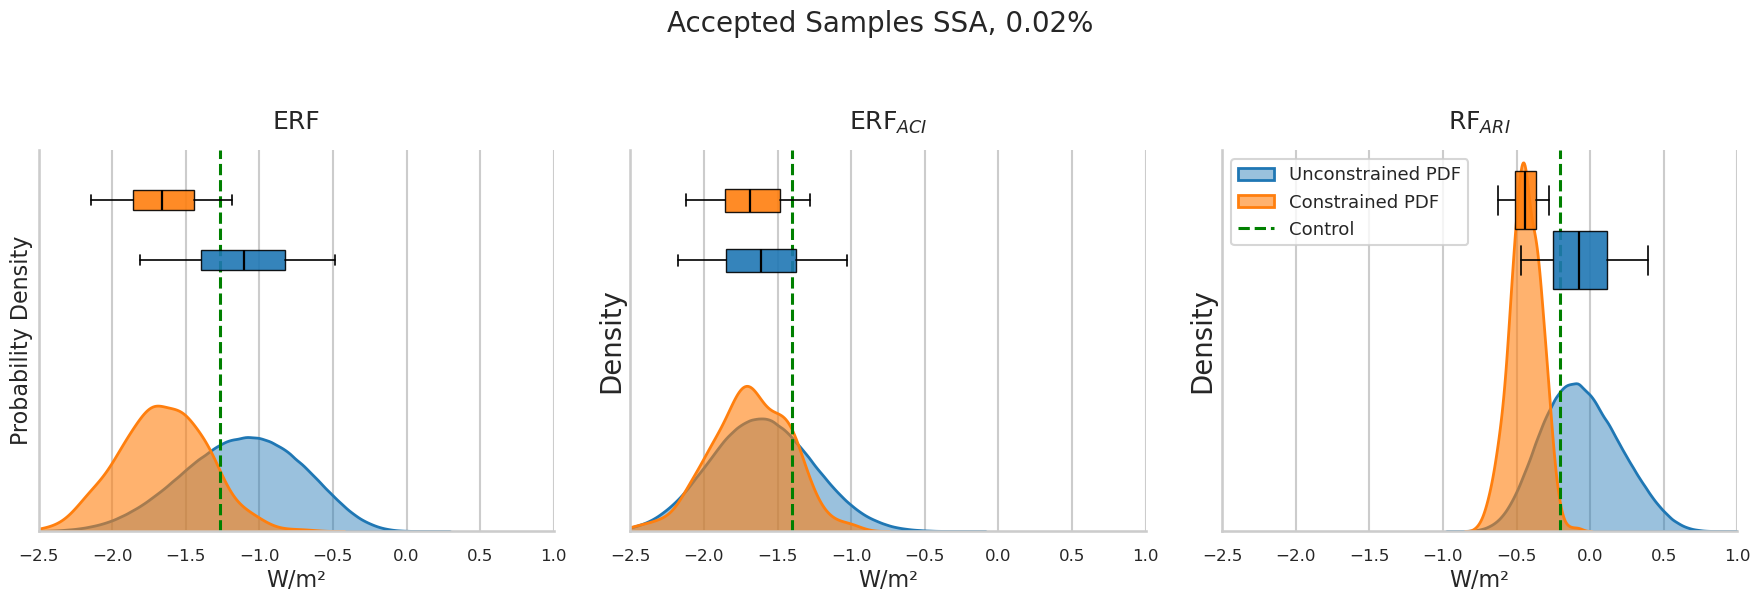

Plotting AI: 4010 accepted members


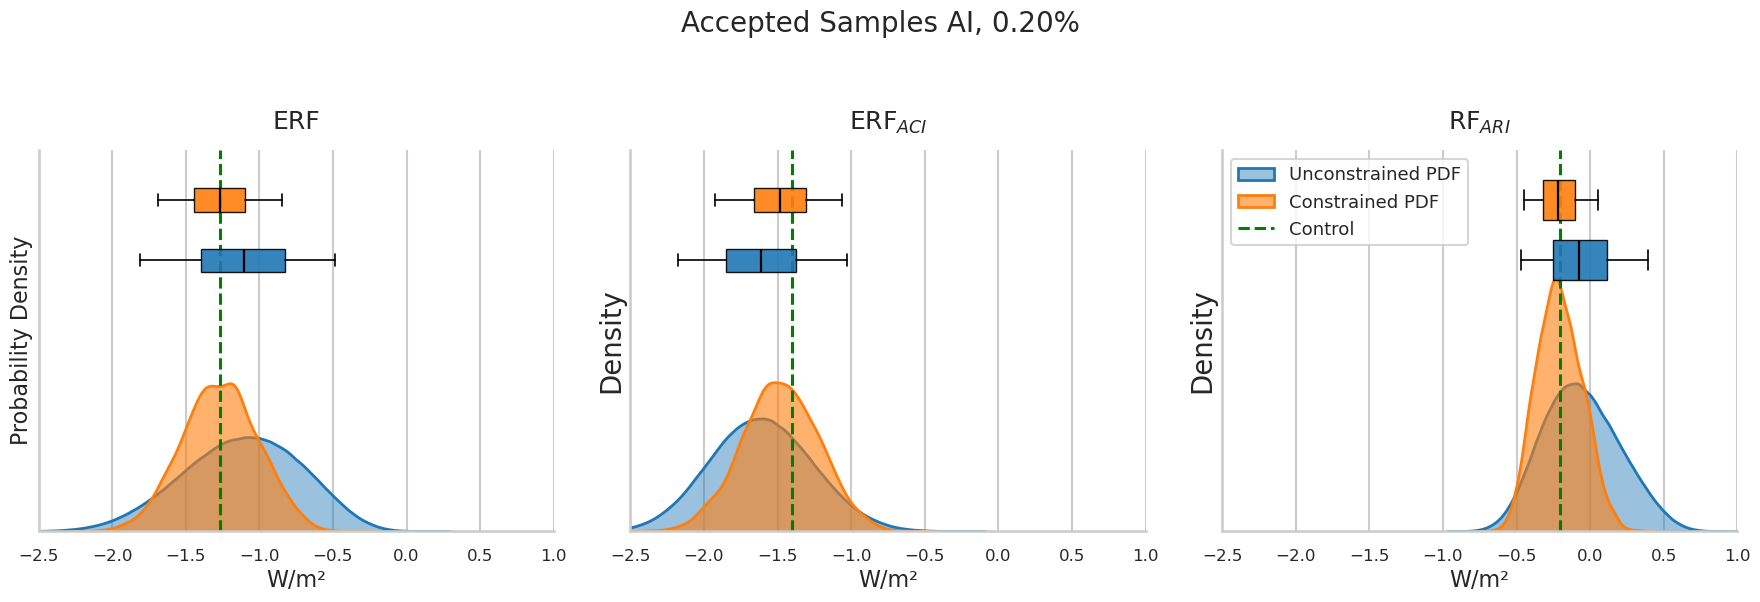

Plotting TAU355_daily: 11900 accepted members


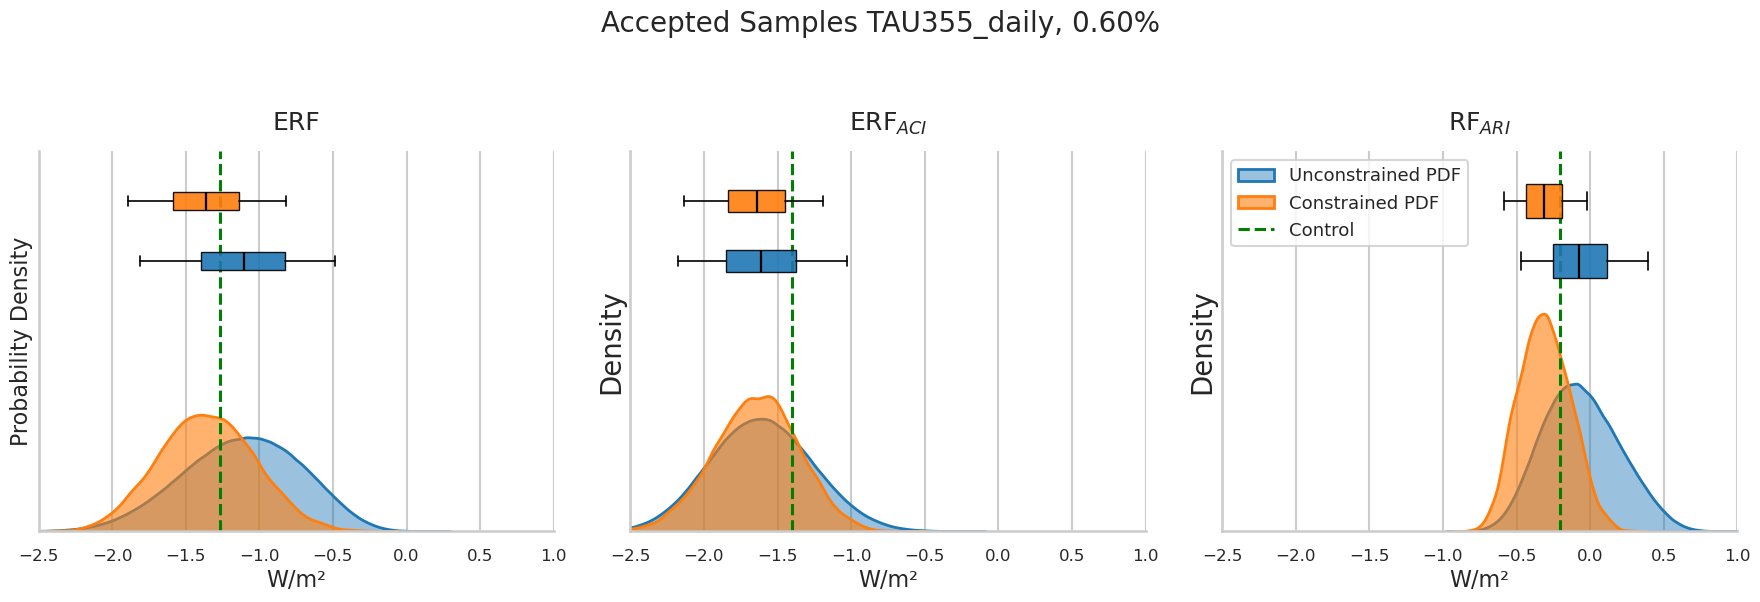

Plotting CDNC_Filtered_OCI: 238944 accepted members


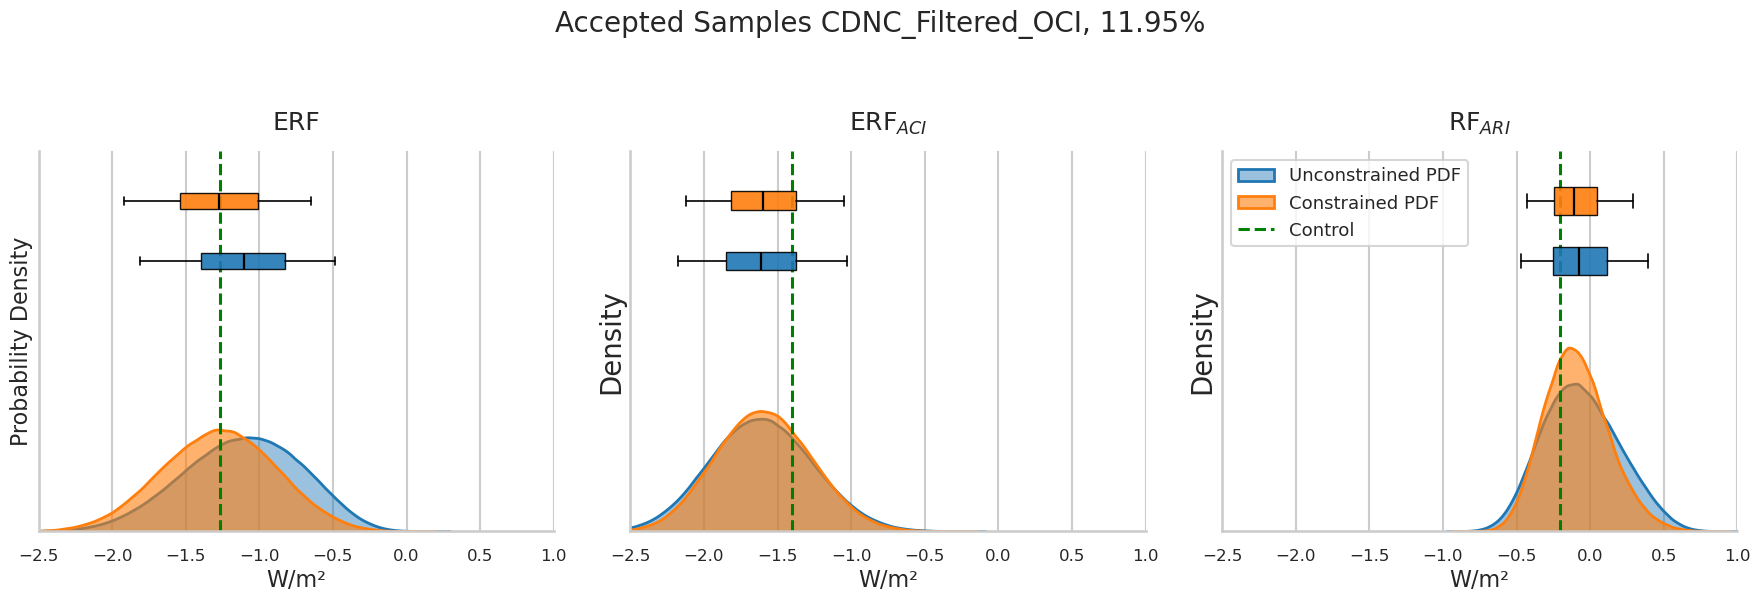

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.1)


# --- List of diagnostics and corresponding accepted masks ---
# accepted_list = {
#     # "AOD": fraction_per_sample_aod > 0.67,
#     # "ANG": fraction_per_sample_ang > 0.67,
#     "SSA": fraction_per_sample_ssa > 0.67,
#     # "AAOD": fraction_per_sample_aaod > 0.67,
#     "AOD_Mode_1": fraction_per_sample_aod_mode_1 > 0.67,
#     # "AOD_Mode_2": fraction_per_sample_aod_mode_2 > 0.67,
#     # "AOD_Mode_3": fraction_per_sample_aod_mode_3 > 0.67,
#     "AI": fraction_per_sample_ai > 0.67,
#     "AOD_Mode_Coarse": fraction_per_sample_aod_mode_coarse > 0.67,
#     # "CDNC": fraction_per_sample_cdnc > 0.67,
#     # "CDNC_Filtered": accepted_cdnc_filtered,
#     "REFFL_CT": accepted_reffl_ct,
#     "TAU355": accepted_tau355,

# }



# --- Load full datasets ---
n_samples_new = 2000000
# Prepare accepted datasets
Full_ERF = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERF/emulated_erf_{n_samples_new}.nc')['Emulated ERF'].sel(region='Global').mean('month')

Full_ERFaci = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFaci/emulated_erfaci_{n_samples_new}.nc')['Emulated ERFaci'].sel(region='Global').mean('month')

Full_ERFari = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFari/emulated_erfari_{n_samples_new}.nc')['Emulated ERFari'].sel(region='Global').mean('month')

datasets = [
    ("ERF", Full_ERF),
    ("ERF$_{ACI}$", Full_ERFaci),
    ("RF$_{ARI}$", Full_ERFari),
]

colors = {"full": "#1f77b4", "acc": "#ff7f0e"}  # blue/orange for PDFs
box_colors = {"full": "#d62728", "acc": "#ff7f0e"}  # red/orange for boxes

# --- Loop over each accepted mask ---
for name, ens in zip(stored_best_var,stored_best):
    print(f"Plotting {name}: {len(ens)} accepted members")

    # Select accepted samples
    Accepted_ERF = Full_ERF.sel(sample=ens)
    Accepted_ERFaci = Full_ERFaci.sel(sample=ens)
    Accepted_ERFari = Full_ERFari.sel(sample=ens)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

    for ax, (title, full, acc) in zip(axes, [
        ("ERF", Full_ERF, Accepted_ERF),
        ("ERF$_{ACI}$", Full_ERFaci, Accepted_ERFaci),
        ("RF$_{ARI}$", Full_ERFari, Accepted_ERFari),
    ]):
        # --- KDE plots ---
        sns.kdeplot(full, fill=True, ax=ax, color=colors["full"], alpha=0.45, linewidth=2, label="Unconstrained PDF")
        sns.kdeplot(acc, fill=True, ax=ax, color=colors["acc"], alpha=0.6, linewidth=2, label="Constrained PDF")

        # --- Control line ---
        ax.axvline(full[0], color="green", linestyle="--", linewidth=2.2, label="Control")

        # --- Boxplot positions ---
        ymax = ax.get_ylim()[1]

        def draw_boxplot(ax, data, y_center, color):
            p = np.percentile(data, [5, 25, 50, 75, 95])
            ax.bxp([{
                'med': p[2],
                'q1':  p[1],
                'q3':  p[3],
                'whislo': p[0],
                'whishi': p[4],
                'mean': None,
                'fliers': []
            }], positions=[y_center], widths=0.15*ymax, vert=False,
            patch_artist=True,
            boxprops={'facecolor': color, 'edgecolor': 'black', 'alpha': 0.9},
            medianprops={'color': 'black', 'linewidth': 1.6},
            whiskerprops={'color': 'black', 'linewidth': 1.2},
            capprops={'color': 'black', 'linewidth': 1.2})

        draw_boxplot(ax, full, 2.7, colors["full"])
        draw_boxplot(ax, acc, 3.3, box_colors["acc"])

        # --- Labels & titles ---
        ax.set_title(title, fontsize=18, pad=15)
        ax.set_xlabel("W/m²", fontsize=16)
        ax.tick_params(axis="x", labelsize=12)
        if ax is axes[0]:
            ax.set_ylabel("Probability Density", fontsize=16)
        ax.set_xlim([-2.5,1])
        ax.set_yticks([])  # removes y-axis labels

        # Legend
        if ax is axes[2]:
            ax.legend(frameon=True, fontsize=13, loc="upper left")

 #   plt.suptitle(f"Accepted Samples: {name}, {(mask.sum().item() / mask.size) * 100:.2f}%", fontsize=20, y=1.02)
    plt.suptitle(f"Accepted Samples {name}, {(len(ens) / n_samples_new) * 100:.2f}%", fontsize=20, y=1.02)

    sns.despine()
    plt.tight_layout()
#    plt.show()
    #plt.savefig(f"/home/ybhatti2/Figures/Manuscript_Figures/PDFs/{name}_ERF_pdf_Least_Squares.png",dpi=100,bbox_inches = 'tight')

    plt.show()


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -----------------------------
# Setup (your code)
# -----------------------------
# n_samples = 2000000
# base_dir = Path("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional")

# ppe_normalized_new_samples = pd.read_csv(
#     f"/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_{n_samples}.csv"
# )
# ppe_normalized_new_samples.set_index(ppe_normalized_new_samples.columns[0], inplace=True)

# ppe_path = base_dir / f"../ppe_params_non_norm_{n_samples}.csv"
# ppe_non_normalized_new_samples = pd.read_csv(ppe_path)
# ppe_non_normalized_new_samples.set_index(ppe_non_normalized_new_samples.columns[0], inplace=True)

# Accepted_Params_norm = pd.read_csv(
#     "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Accepted_Params_norm_1969_Best_Constraint_chosen.csv"
# )
# Accepted_Params_norm.set_index(Accepted_Params_norm.columns[0], inplace=True)
# best_idx = Accepted_Params_norm.reset_index().iloc[:, 0].to_numpy().astype(int)

# Full/combined sets
shared_dataset_combined = ppe_non_normalized_new_samples.iloc[best_idx]
control_values = ppe_non_normalized_new_samples.iloc[0]
OBS_TITLES = [
    "AOD$_{Fine}",
    "AOD$_{Coarse}",
    "SSA",
    "AI",
    "Aer_frac2km",
    # "REFFL_CT",
    "CDNC",
]

# -----------------------------
# Heatmap table (your definition, kept)
# -----------------------------
obs_names = ["Combined"] + list(OBS_TITLES)
heatmap_data = pd.DataFrame(index=shared_dataset_combined.columns, columns=obs_names, dtype=float)

full_median = ppe_non_normalized_new_samples.median()
full_std = ppe_non_normalized_new_samples.std().replace(0, np.nan)

# Your "signed pull" relative to full ensemble median:
heatmap_data["Combined"] = (shared_dataset_combined.median() - full_median) / full_std

for name, ens,titles in zip(stored_best_var, stored_best,OBS_TITLES):
    shared_dataset_obs = ppe_non_normalized_new_samples.iloc[np.asarray(ens, dtype=int)]
    heatmap_data[titles] = (shared_dataset_obs.median() - full_median) / full_std

print(heatmap_data.head())

# -----------------------------
# Robust blanking: bootstrap CI on the median shift
# -----------------------------
def bootstrap_ci_median_shift(full_series, subset_series, n_boot=500, ci=95, seed=0):
    """
    Returns (lo, hi) CI for (median(subset) - median(full)), using bootstrap resampling of subset.
    """
    rng = np.random.default_rng(seed)

    x_full = full_series.to_numpy()
    x_sub = subset_series.to_numpy()

    # drop NaNs
    x_full = x_full[np.isfinite(x_full)]
    x_sub = x_sub[np.isfinite(x_sub)]
    if len(x_sub) < 20 or len(x_full) < 20:
        return np.nan, np.nan

    med_full = np.median(x_full)

    boots = rng.choice(x_sub, size=(n_boot, len(x_sub)), replace=True)
    med_boot = np.median(boots, axis=1)

    shift = med_boot - med_full
    alpha = (100 - ci) / 2
    lo = np.percentile(shift, alpha)
    hi = np.percentile(shift, 100 - alpha)
    return lo, hi

# Build a mask of "significant" cells (CI excludes 0)
sig_mask = pd.DataFrame(False, index=heatmap_data.index, columns=heatmap_data.columns)
heatmap_err = pd.DataFrame(np.nan, index=heatmap_data.index, columns=heatmap_data.columns, dtype=float)

# Precompute the full series per parameter once
full_df = ppe_non_normalized_new_samples  # shorthand

# Columns -> index arrays
constraint_indices = {"Combined": best_idx}
for ens,titles in zip(stored_best,OBS_TITLES):
    constraint_indices[titles] = np.asarray(ens, dtype=int)

# Bootstrap significance test per cell
N_BOOT = 1000         # bump to 1000 if you want, but 500 is usually stable
CI = 90
SEED_BASE = 123

for j, cname in enumerate(heatmap_data.columns):
    idx = constraint_indices[cname]
    subset_df = ppe_non_normalized_new_samples.iloc[idx]

    for i, param in enumerate(heatmap_data.index):
        lo, hi = bootstrap_ci_median_shift(
            full_df[param], subset_df[param],
            n_boot=N_BOOT, ci=CI, seed=SEED_BASE + 10*j + i
        )

        if np.isfinite(lo) and np.isfinite(hi):
            # half-width of CI on the median shift
            err_shift = 0.5 * (hi - lo)

            # normalize to match heatmap units (same denom as heatmap_data)
            denom = full_std[param]
            heatmap_err.loc[param, cname] = err_shift / denom if np.isfinite(denom) and denom != 0 else np.nan

            # significant if CI excludes 0
            if (lo > 0) or (hi < 0):
                sig_mask.loc[param, cname] = True


annot = heatmap_data.copy().astype(object)
for r in heatmap_data.index:
    for c in heatmap_data.columns:
        v = heatmap_plot.loc[r, c]
        e = heatmap_err.loc[r, c]
        if pd.isna(v):
            annot.loc[r, c] = ""
        elif pd.isna(e):
            annot.loc[r, c] = f"{v:.2f}"
        else:
            annot.loc[r, c] = f"{v:.2f}±{e:.2f}"


# Optional: also require a minimum *effect size* to keep the figure readable
# (this is no longer "significance", it's a practical-importance filter)
EFFECT_MIN = 0.2  # your example; keep if you want
effect_mask = heatmap_data.abs() >= EFFECT_MIN

# Final mask to display: significant AND (optionally) large enough
display_mask = sig_mask & effect_mask  # or just `sig_mask` if you don't want EFFECT_MIN

# Apply masking: values not passing become NaN -> plotted as white
heatmap_plot = heatmap_data.where(display_mask)


                     Combined  AOD$_{Fine}  AOD$_{Coarse}       SSA        AI  \
SCALE_EMI_DMS       -0.459547    -0.856371       0.140880 -1.015228 -0.124952   
SCALE_EMI_SHP_SO2    0.015594     0.072125       0.016478  0.126087  0.012445   
SCALE_EMI_ANTNS_SO2  0.254380    -0.336688       0.278826  0.412735  0.049901   
SCALE_EMI_ANT_BC    -0.433117     0.160167       0.033829 -0.659315  0.146983   
SCALE_EMI_ANT_OC    -0.015020     0.001012      -0.001212  0.219878 -0.062211   

                     Aer_frac2km      CDNC  
SCALE_EMI_DMS          -0.138659 -0.287057  
SCALE_EMI_SHP_SO2      -0.004151 -0.002379  
SCALE_EMI_ANTNS_SO2     0.663621 -0.107111  
SCALE_EMI_ANT_BC        0.028103  0.001088  
SCALE_EMI_ANT_OC       -0.122784 -0.241039  


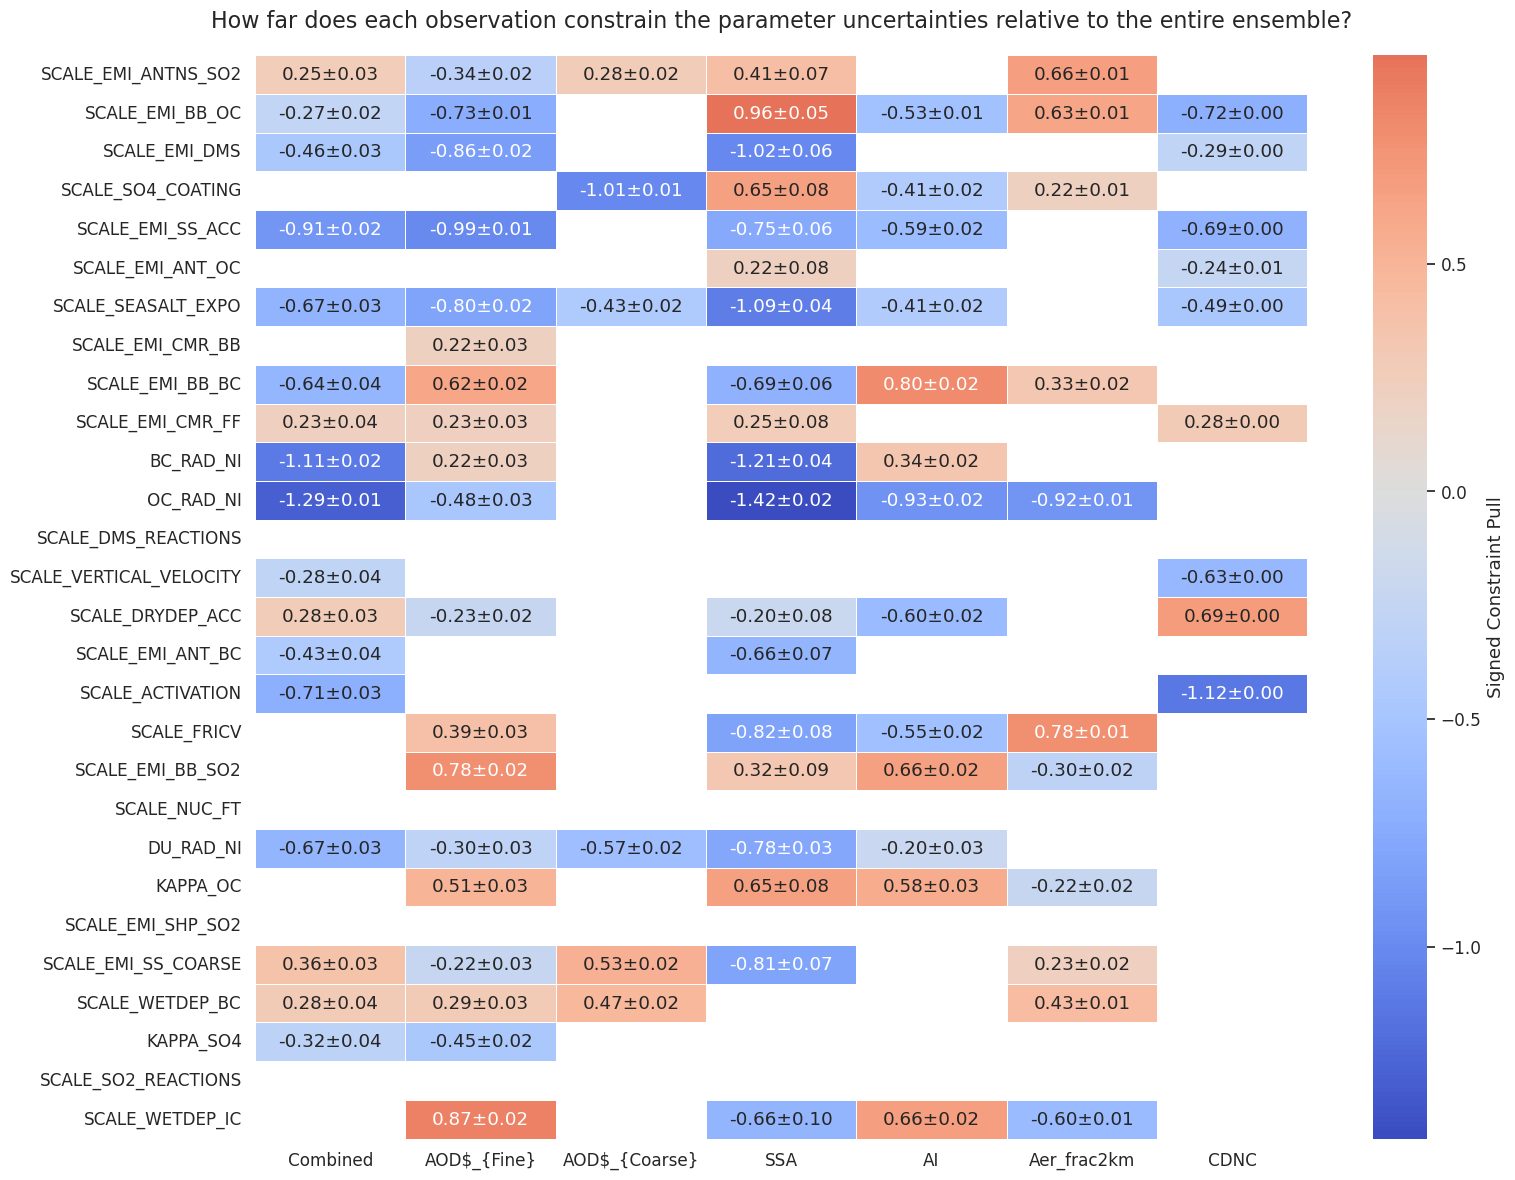

In [61]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
results_df = pd.read_csv("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Global_Annual_Uncertainty_Contributions_2000000_for_heatmap_Final.csv")
results_df.set_index(results_df.columns[0], inplace=True)

Combined_Uncertainty_Contribution = (
    results_df
    .pivot_table(
        index='Variable',
        columns='Observation',
        values='Original_Uncertainty',
        aggfunc='sum'
    )
    .reset_index()
)

# df_merged from before
Combined_Uncertainty_Contributions = Combined_Uncertainty_Contribution.sort_values(
    by='ERF', ascending=False
)

params_order = Combined_Uncertainty_Contributions['Variable'].values
obs_title = ['Combined' ,'AOD$_{Fine}', 'AOD$_{Coarse}', 'SSA', 'AI', 'Aer_frac2km', 'CDNC']

# -----------------------------
# 6️⃣ Plot heatmap
# -----------------------------
plt.figure(figsize=(16, 12))
sns.set(style='whitegrid', font_scale=1.1)
heatmap_plots = heatmap_plot.reindex(index=params_order, columns=obs_title)
heatmap_datas = heatmap_plots

annots = annot.reindex(index=params_order, columns=obs_title)
# annots = annot

# ax = sns.heatmap(
#     heatmap_datas,
#     cmap='coolwarm',       # blue = negative, red = positive
#     center=0,              # center colormap at 0
#     annot=True,            # show values
#     fmt=".2f",
#     linewidths=0.5,
#     cbar_kws={'label': 'Signed Constraint Pull'},
#     mask=heatmap_datas.isna()

# )
ax = sns.heatmap(
    heatmap_datas,
    cmap='coolwarm',
    center=0,
    annot=annots,
    fmt="",
    linewidths=0.5,
    cbar_kws={'label': 'Signed Constraint Pull'},
    mask=heatmap_datas.isna()
)


# ax.set_xlabel('Observational Constraint', fontsize=14)
# ax.set_ylabel('PPE Parameter', fontsize=14)
ax.set_title('How far does each observation constrain the parameter uncertainties relative to the entire ensemble?', fontsize=16, pad=20)
ax.grid(False)
plt.tight_layout()
#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Parameter_Distance_for_each_observation.png", dpi=150)
#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Parameter_Distance_for_each_observation.pdf", dpi=150)
plt.show()  


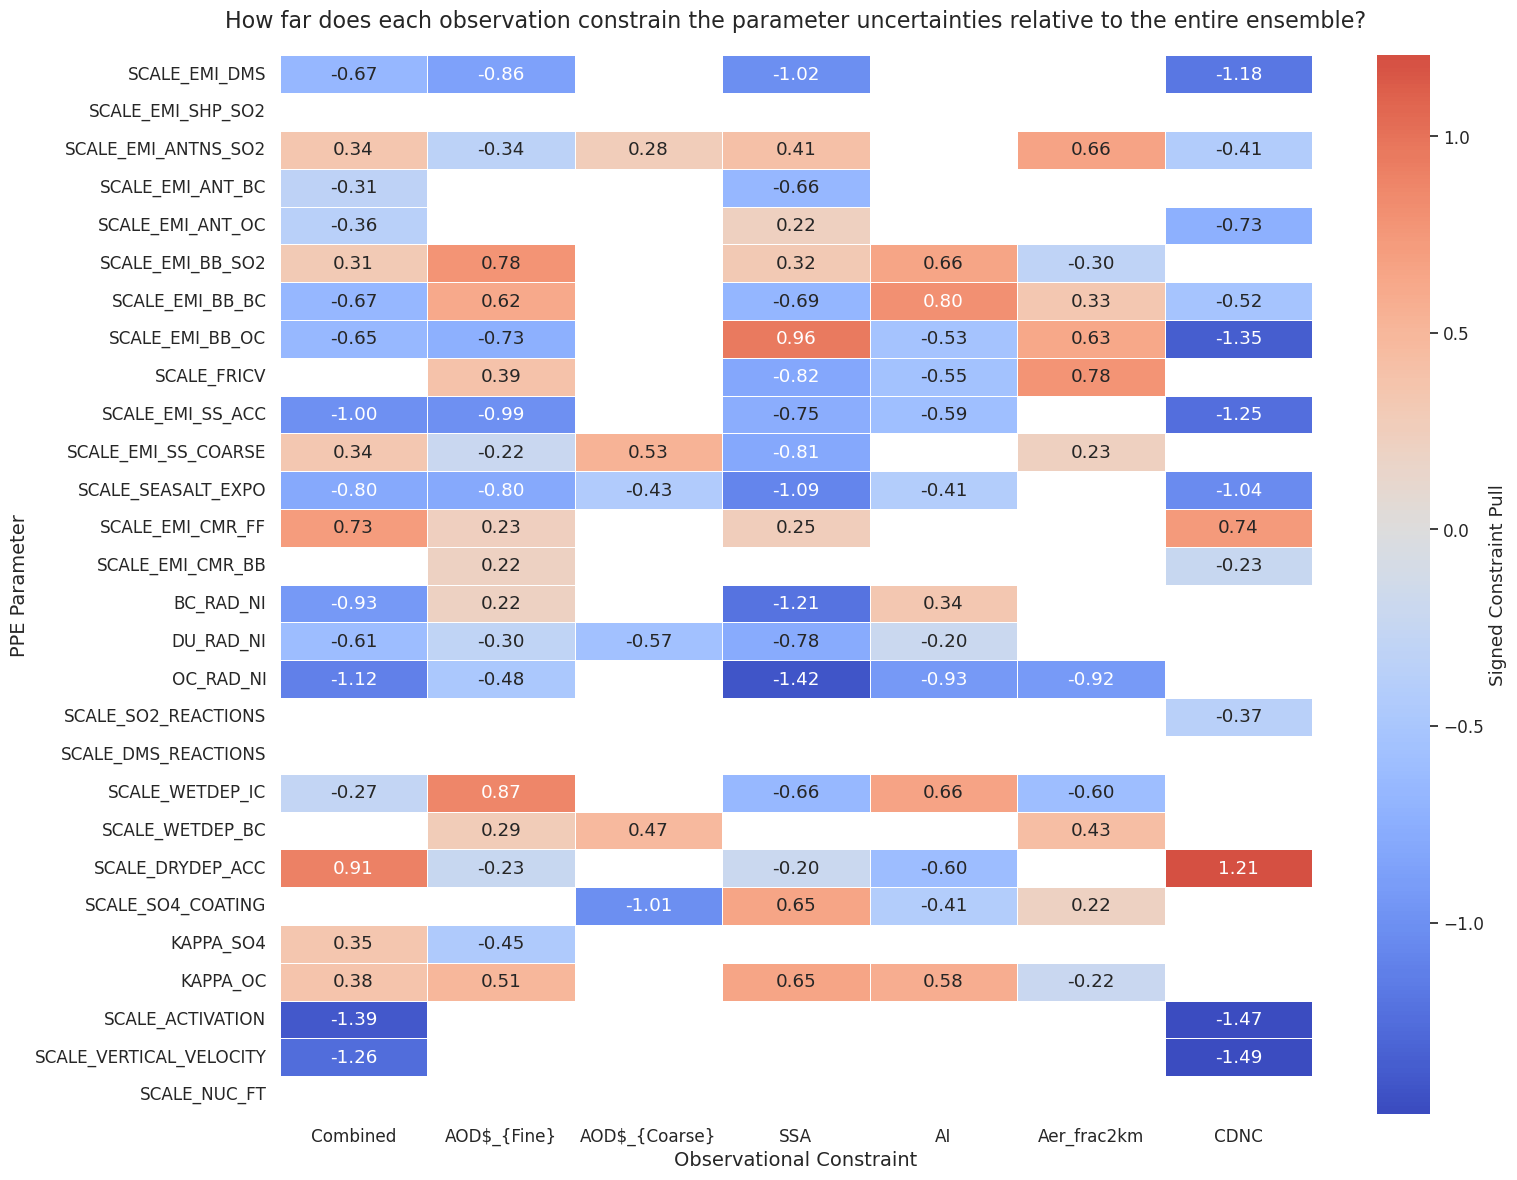

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -----------------------------
# 6️⃣ Plot heatmap
# -----------------------------
plt.figure(figsize=(16, 12))
sns.set(style='whitegrid', font_scale=1.1)
OBS_TITLES = [
    "AOD$_{Fine}",
    "AOD$_{Coarse}",
    "SSA",
    "AI",
    "Aer_frac2km",
    # "REFFL_CT",
    "CDNC",
]

ax = sns.heatmap(
    heatmap_data,
    cmap='coolwarm',       # blue = negative, red = positive
    center=0,              # center colormap at 0
    annot=True,            # show values
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Signed Constraint Pull'},
    mask=heatmap_plot.isna()

)

ax.set_xlabel('Observational Constraint', fontsize=14)
ax.set_ylabel('PPE Parameter', fontsize=14)
ax.set_title('How far does each observation constrain the parameter uncertainties relative to the entire ensemble?', fontsize=16, pad=20)
ax.grid(False)
plt.tight_layout()
plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Supplimentary/Parameter_Distance_for_each_observation.png", dpi=150)
plt.show()  


Testing AI vs CDNC and Fine mode AOD with CDNC.

we need a good range of median values for ERFaci. So lets choose those. \

tol = 1e-6    
median_value = Full_ERFaci.median().item()  # get median as scalar \
indices = np.where(np.isclose(Full_ERFaci, median_value, atol=tol)) 


This gives us a median range of ERFaci values. Now we need those indicies \

testCDNC = Full_CDNC.sel(sample=indices[0])

\
Giving us a range of samples.

In [4]:
from pathlib import Path

# --- Configuration ---
n_samples = 2000000  # You can easily change this once at the top

#base_dir = Path("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional")
base_dir = Path("/home/ybhatti/ybhatti2/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New/Regional")


vars_to_load = [
    "SSA", "AOD_Mode_1", "AI",
    "AOD_Mode_Coarse", "TAU355_daily",

    "CDNC_OCI_spx"]#, 
    #"REFFL_CT_OCI"]#, "REFFL_CT_SPEXone", "REFFL_CT_HARP"


ppe_normalized_new_samples = pd.read_csv(f'{base_dir}/../ppe_params_{n_samples}.csv')
#ppe_normalized_new_samples = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_{n_samples}_Important_Parameters.csv')
ppe_normalized_new_samples.set_index(ppe_normalized_new_samples.columns[0], inplace=True)

ppe_path = base_dir / f"../ppe_params_non_norm_{n_samples}.csv"
#ppe_path = base_dir / f"../ppe_params_non_norm_{n_samples}_Important_Parameters.csv"
ppe_non_normalized_new_samples = pd.read_csv(ppe_path)
ppe_non_normalized_new_samples.set_index(ppe_non_normalized_new_samples.columns[0], inplace=True)

# --- Containers ---
# regional_datas = {}
boxplot_datas = {}
ppe_params = None

# --- Load variable data efficiently ---
for var in vars_to_load:
    var_dir = base_dir / var

    # Regional Uncertainty files
    reg_file = var_dir / f"emulated_{var.lower()}_{n_samples}.nc"
    #reg_file = var_dir / f"emulated_{var.lower()}_{n_samples}_Important_Parameters.nc"

 #   end
   # box_file = var_dir / f"Boxplot_Unconstrained_Uncertainty_{var.lower()}_{n_samples}.nc"
    try:
        with xr.open_dataset(reg_file) as ds_reg:
            # Extract variable by name dynamically
#            regional_datas[var] = ds_reg[f"Emulated {var}"]
            boxplot_datas[var] = ds_reg[f"Emulated {var}"].mean('month')#, skipna=True)
    except:
        print(f"⚠️ Missing: {var}")

# --- Load PPE parameters ---

# regional_dataset = xr.Dataset({
#     "SSA": regional_datas["SSA"],
#     "AOD_Mode_1": regional_datas["AOD_Mode_1"],
#     "AI": regional_datas["AI"],
#     "AOD_Mode_Coarse": regional_datas["AOD_Mode_Coarse"],
#     "TAU355": regional_datas["TAU355"],
#     "CDNC_Filtered_OCI": regional_datas["CDNC_Filtered_OCI"],
#     "REFFL_CT_OCI": regional_datas["REFFL_CT_OCI"],
# })
# --- Extract Hemispheric_Difference as its own variable ---
hem_vars = ["CDNC_OCI_spx"]#, "CDNC_Filtered_HARP"]

# for hv in hem_vars:
#     if hv in regional_dataset:
#         regional_dataset[f"{hv}_Hemispheric_Difference"] = (
#             regional_dataset[hv].sel(region="Hemispheric_Difference")
#         )
# for var in ["REFFL_CT_OCI"]:#, "REFFL_CT_SPEXone", "REFFL_CT_HARP"]:
#     regional_dataset[var] = regional_dataset[var].drop_sel(region="Hemispheric_Difference")


boxplot_dataset = xr.Dataset({
    "SSA": boxplot_datas["SSA"],
    "AOD_Mode_1": boxplot_datas["AOD_Mode_1"],
    "AI": boxplot_datas["AI"],
    "AOD_Mode_Coarse": boxplot_datas["AOD_Mode_Coarse"],
    "TAU355_daily": boxplot_datas["TAU355_daily"],
    "CDNC_Filtered_OCI": boxplot_datas["CDNC_OCI_spx"],
#    "REFFL_CT_OCI": boxplot_datas["REFFL_CT_OCI"],
})
hem_vars = ["CDNC_Filtered_OCI"]#, "CDNC_Filtered_HARP"]

for hv in hem_vars:
    if hv in boxplot_dataset:
        boxplot_dataset[f"{hv}_Hemispheric_Difference"] = (
            boxplot_dataset[hv].sel(region="Hemispheric_Difference")
        )


#regional_dataset = regional_dataset.where(regional_dataset != 0, np.nan)
boxplot_dataset = boxplot_dataset.where(boxplot_dataset != 0, np.nan)


region_names = [
    'Australia', 'Europe', 'South-East Asia', 'Siberia','Savannah',
    'North America', 'Boreal America',
    'Amazon', 'North Atlantic', 'South Atlantic', 'North Pacific',
    'South Pacific', 'Tropic Atlantic' , 'Tropic Pacific', 'Tropic Indian', 'South Indian',
    'Dust belt','Shipping','African Horn', 'Global'
]

Accepted_Params_norm = pd.read_csv(f'{base_dir}/Accepted_Ensembles/Accepted_Params_norm_1918_Optimal_Constraint_chosen_L14.csv')
Accepted_Params_norm.set_index(Accepted_Params_norm.columns[0], inplace=True)
best_idx = Accepted_Params_norm.reset_index().iloc[:, 0].to_numpy()
accepted_members_best = (best_idx)

aerosol_vars = [
    "AOD_Mode_1",
    "AOD_Mode_Coarse",
    "SSA",
    "AI",
    "TAU355_daily",
#    "REFFL_CT_OCI",
    #"CDNC_Filtered_OCI_Hemispheric_Difference",
    "CDNC_Filtered_OCI",

]
stored_best = []
stored_best_var = []

for var in aerosol_vars:
#    Accepted_Params_non_norm_obs = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/Accepted_Ensembles/Individual/Accepted_Params_non_norm_{var}_1969_Best_Constraint_chosen.csv')
    Accepted_Params_non_norm_obs = pd.read_csv(f'{base_dir}/Accepted_Ensembles/Individual/Accepted_Params_non_norm_{var}_1918_Optimal_Constraint_chosen_L14.csv')
    Accepted_Params_non_norm_obs.set_index(Accepted_Params_non_norm_obs.columns[0], inplace=True)
    stored_best.append(Accepted_Params_non_norm_obs.reset_index().iloc[:, 0].to_numpy())


In [11]:
base_dir = f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New/Regional'
Accepted_Params_norm = pd.read_csv(f'{base_dir}/Accepted_Ensembles/Accepted_Params_norm_1918_Optimal_Constraint_chosen_L14.csv')
Accepted_Params_norm.set_index(Accepted_Params_norm.columns[0], inplace=True)
best_idx = Accepted_Params_norm.reset_index().iloc[:, 0].to_numpy()
accepted_members_best = (best_idx)

accepted_members_best = (best_idx)
n_samples_new = 2000000
# Prepare accepted datasets
Full_ERF = xr.open_dataset(f'{base_dir}/ERF/emulated_Full_Ensemble_ERF_2000000.nc')['Emulated __xarray_dataarray_variable__']
#Full_ERF_month = xr.open_dataset(f'{base_dir}/ERF/emulated_Full_Ensemble_ERF_2000000_month_spread.nc')['Emulated __xarray_dataarray_variable__']
Accepted_ERF = Full_ERF.sel(sample=accepted_members_best)
#Accepted_ERF_month = Full_ERF_month.sel(sample=accepted_members_best)
print('done with ERF')

Full_ERFaci = xr.open_dataset(f'{base_dir}/ERFaci/emulated_Full_Ensemble_ERFaci_2000000.nc')['Emulated __xarray_dataarray_variable__']
#Full_ERFaci_month = xr.open_dataset(f'{base_dir}/ERFaci/emulated_Full_Ensemble_ERFaci_2000000_month_spread.nc')['Emulated __xarray_dataarray_variable__']
Accepted_ERFaci = Full_ERFaci.sel(sample=accepted_members_best)
#Accepted_ERFaci_month = Full_ERFaci_month.sel(sample=accepted_members_best)
print('done with ERFaci')

Full_ERFari = xr.open_dataset(f'{base_dir}/ERFari/emulated_Full_Ensemble_ERFari_2000000.nc')['Emulated __xarray_dataarray_variable__']
#Full_ERFari_month = xr.open_dataset(f'{base_dir}/ERFari/emulated_Full_Ensemble_ERFari_2000000_month_spread.nc')['Emulated __xarray_dataarray_variable__']
Accepted_ERFari = Full_ERFari.sel(sample=accepted_members_best)
#Accepted_ERFari_month = Full_ERFari_month.sel(sample=accepted_members_best)
print('done with ERFari')

print('done with part 1')
#ERF_mean_full = Full_ERF.mean(dim="sample")
ERF_mean_acc = Accepted_ERF.mean(dim="sample")
ERFaci_mean_acc = Accepted_ERFaci.mean(dim="sample")
ERFari_mean_acc = Accepted_ERFari.mean(dim="sample")

#ERF_mean_acc_month = Accepted_ERF_month.mean(dim="sample")

#ERF_std_full = Full_ERF.std(dim="sample")
ERF_std_acc = Accepted_ERF.std(dim="sample")
ERFaci_std_acc = Accepted_ERFaci.std(dim="sample")
print("part ERFaci_std_acc")
ERFari_std_acc = Accepted_ERFari.std(dim="sample")
print("part ERFari_std_acc")

ERF_std_acc = Accepted_ERF.std(dim="sample")
print("part ERF_std_acc")


print('done with part 2')
# Full_ERFari.std('sample').to_netcdf(f'{base_dir}/ERFari/ERFari_std_full_2000000.nc')

# Full_ERFaci.std('sample').to_netcdf(f'{base_dir}/ERFaci/ERFaci_std_full_2000000.nc')

# Full_ERF.std('sample').to_netcdf(f'{base_dir}/ERF/ERF_std_full_2000000.nc')

# # full_month_ERF = Full_ERF_month.mean('sample')
# # full_month_ERF.to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERF/ERF_mean_full_month_2_million.nc')
ERF_mean_full=xr.open_dataset(f'{base_dir}/ERF/ERF_mean_full_2000000.nc')['Emulated __xarray_dataarray_variable__']
ERF_std_full=xr.open_dataset(f'{base_dir}/ERF/ERF_std_full_2000000.nc')['Emulated __xarray_dataarray_variable__']
print('done with part 3')

ERFaci_mean_full=xr.open_dataset(f'{base_dir}/ERFaci/ERFaci_mean_full_2000000.nc')['Emulated __xarray_dataarray_variable__']
ERFaci_std_full=xr.open_dataset(f'{base_dir}/ERFaci/ERFaci_std_full_2000000.nc')['Emulated __xarray_dataarray_variable__']
print('done with part 4')

ERFari_mean_full=xr.open_dataset(f'{base_dir}/ERFari/ERFari_mean_full_2000000.nc')['Emulated __xarray_dataarray_variable__']
ERFari_std_full=xr.open_dataset(f'{base_dir}/ERFari/ERFari_std_full_2000000.nc')['Emulated __xarray_dataarray_variable__']

# ERF_mean_accs = []
# ERF_std_accs  = []

# # =========================
# # Loop once only
# # =========================
# for i, var_name in enumerate(aerosol_vars):

#     print(f"Precomputing {i}: {var_name}")

#     Accepted_ERF = Full_ERF.sel(sample=stored_best[i])

#     ERF_mean_acc = Accepted_ERF.mean("sample")
#     ERF_std_acc  = Accepted_ERF.std("sample")
    
#     ERF_mean_accs.append(ERF_mean_acc.assign_coords(constraint=var_name))
#     ERF_std_accs.append(ERF_std_acc.assign_coords(constraint=var_name))

# # =========================
# # Stack and save
# # =========================
# ds_out = xr.Dataset(
#     {
#         "ERF_mean_acc": xr.concat(
#             ERF_mean_accs,
#             dim=xr.IndexVariable("constraint", aerosol_vars),
#         ),
#         "ERF_std_acc": xr.concat(
#             ERF_std_accs,
#             dim=xr.IndexVariable("constraint", aerosol_vars),
#         ),
#     }
# )

# ds_out.to_netcdf("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
#     "Emulated_data/Implausibility/New/Regional/ERF/"
#     "ERF_constraint_mean_from_observations_new_cdnc_tighter.nc")


# ERF_mean_accs = []
# ERF_std_accs  = []

# # =========================
# # Loop once only
# # =========================
# for i, var_name in enumerate(aerosol_vars):

#     print(f"Precomputing {i}: {var_name}")

#     Accepted_ERF = Full_ERFaci.sel(sample=stored_best[i])

#     ERF_mean_acc = Accepted_ERF.mean("sample")
#     ERF_std_acc  = Accepted_ERF.std("sample")
    
#     ERF_mean_accs.append(ERF_mean_acc.assign_coords(constraint=var_name))
#     ERF_std_accs.append(ERF_std_acc.assign_coords(constraint=var_name))

# # =========================
# # Stack and save
# # =========================
# ds_out = xr.Dataset(
#     {
#         "ERF_mean_acc": xr.concat(
#             ERF_mean_accs,
#             dim=xr.IndexVariable("constraint", aerosol_vars),
#         ),
#         "ERF_std_acc": xr.concat(
#             ERF_std_accs,
#             dim=xr.IndexVariable("constraint", aerosol_vars),
#         ),
#     }
# )

# ds_out.to_netcdf("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
#     "Emulated_data/Implausibility/New/Regional/ERF/"
#     "ERFaci_constraint_mean_from_observations_new_cdnc_tighter.nc")

# ERF_mean_accs = []
# ERF_std_accs  = []

# # =========================
# # Loop once only
# # =========================
# for i, var_name in enumerate(aerosol_vars):

#     print(f"Precomputing {i}: {var_name}")

#     Accepted_ERF = Full_ERFari.sel(sample=stored_best[i])

#     ERF_mean_acc = Accepted_ERF.mean("sample")
#     ERF_std_acc  = Accepted_ERF.std("sample")
    
#     ERF_mean_accs.append(ERF_mean_acc.assign_coords(constraint=var_name))
#     ERF_std_accs.append(ERF_std_acc.assign_coords(constraint=var_name))

# # =========================
# # Stack and save
# # =========================
# ds_out = xr.Dataset(
#     {
#         "ERF_mean_acc": xr.concat(
#             ERF_mean_accs,
#             dim=xr.IndexVariable("constraint", aerosol_vars),
#         ),
#         "ERF_std_acc": xr.concat(
#             ERF_std_accs,
#             dim=xr.IndexVariable("constraint", aerosol_vars),
#         ),
#     }
# )

# ds_out.to_netcdf("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
#     "Emulated_data/Implausibility/New/Regional/ERF/"
#     "ERFari_constraint_mean_from_observations_new_cdnc_tighter.nc")



done with ERF
done with ERFaci
done with ERFari
done with part 1
part ERFaci_std_acc
part ERFari_std_acc
part ERF_std_acc
done with part 2
done with part 3
done with part 4


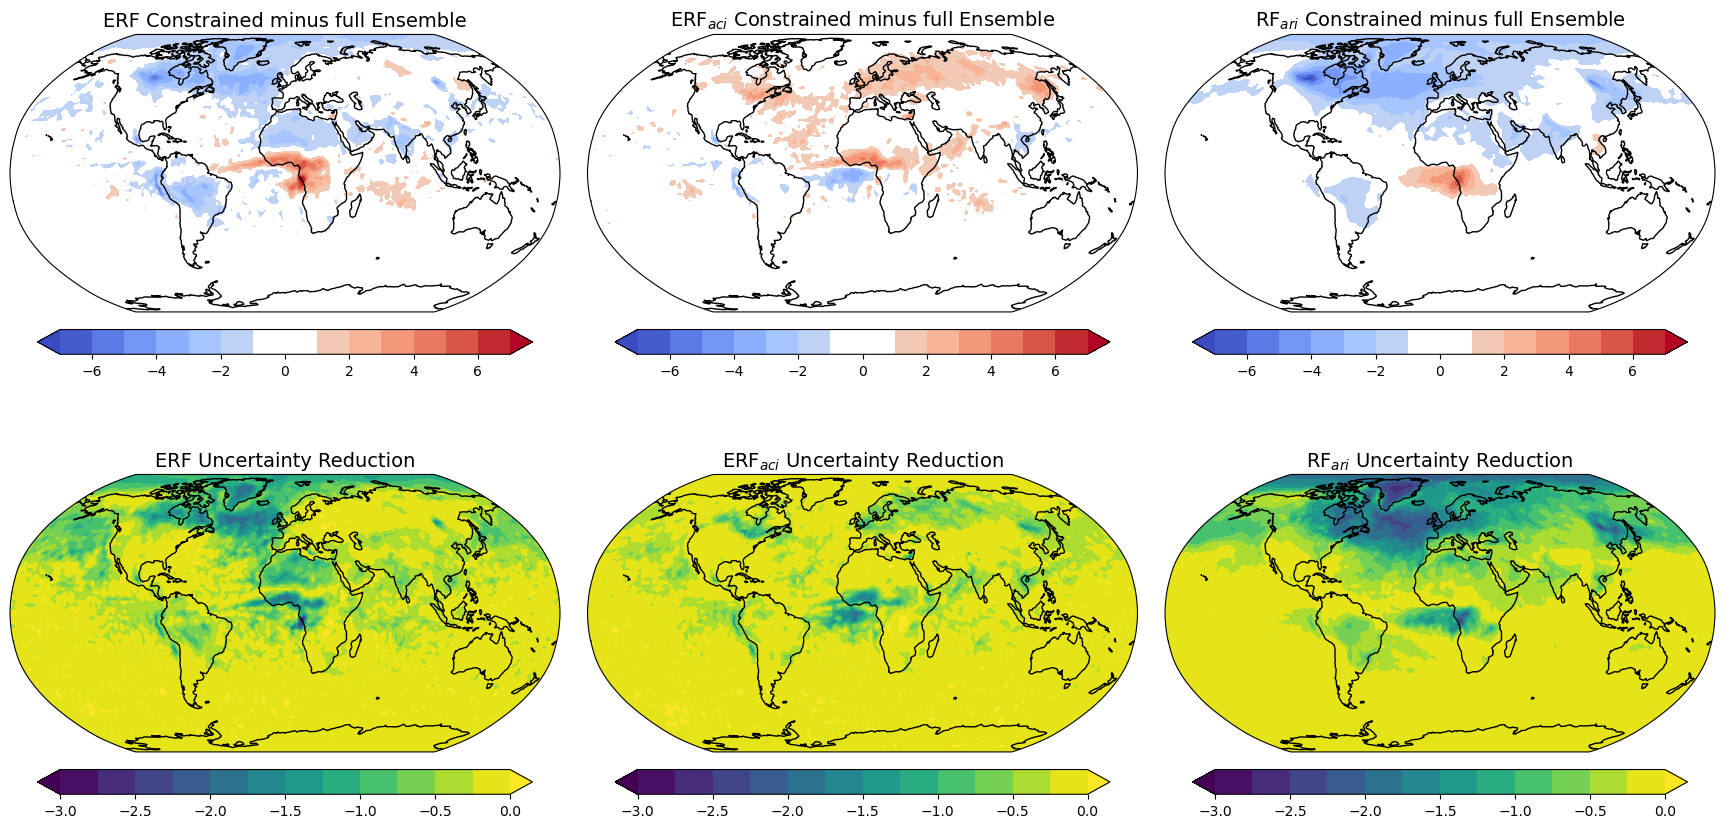

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
#Accepted_ERF = ERF_mean_full.sel(sample=accepted_members_best)


# =========================
# Contour levels
# =========================
clevs = np.arange(-7, 8, 1)
clevsstd = np.arange(0, 3.3, 0.3)
clevs_ratio = np.arange(-50, 0+5, 5)
clevs_ratio = np.arange(-100, 100+10, 10)

clevsstd_diff = np.arange(-3, 0+0.25, 0.25)
clevsstd_ratio = np.arange(0, 1+0.1, 0.1)

# =========================
# Derived fields
# =========================
mean_diff = ERF_mean_acc - ERF_mean_full
std_diff  = ERF_std_acc - ERF_std_full
mean_diff_aci = ERFaci_mean_acc - ERFaci_mean_full
std_diff_aci  = ERFaci_std_acc - ERFaci_std_full
mean_diff_ari = ERFari_mean_acc - ERFari_mean_full
std_diff_ari  = ERFari_std_acc - ERFari_std_full

# std_diff_lim = np.nanmax(np.abs(std_diff))
# mean_ratio = 100.0 * (ERF_mean_acc - ERF_mean_full) / ERF_mean_full
# meanstd_ratio = 100.0 * (ERF_std_acc - ERF_std_full) / ERF_std_full
#meanstd_ratio = 1 - (ERF_std_acc / ERF_std_full) * 100

# =========================
# Helper
# =========================
def cyclic_da(da):
    data_cyc, lon_cyc = add_cyclic_point(da.values, coord=da.lon.values)
    return lon_cyc, da.lat.values, data_cyc

# =========================
# Data registry
# =========================
coolwarm_data_diff = plt.cm.coolwarm(np.linspace(0, 1, 256))
coolwarm_data_diff[110:140, :] = 1.0  # Set values from index 128 to 384 as white
coolwarm_white = LinearSegmentedColormap.from_list('coolwarm_white', coolwarm_data_diff)

fields = [
    # row, col, data, levels, cmap, title, extend
    (0, 0, mean_diff,     clevs,    coolwarm_white, "ERF Constrained minus full Ensemble",       "both"),
    (1, 0, std_diff,      clevsstd_diff,
                          "viridis", "ERF Uncertainty Reduction",                  "both"),
    #(0, 3, mean_ratio,    clevs_ratio, coolwarm_white,  "Mean Ratio (Acc / Full)", "both"),
    (0, 1, mean_diff_aci,     clevs,    coolwarm_white, "ERF$_{aci}$ Constrained minus full Ensemble",       "both"),
    (1, 1, std_diff_aci,      clevsstd_diff,
                          "viridis", "ERF$_{aci}$ Uncertainty Reduction",                  "both"),
    (0, 2, mean_diff_ari,     clevs,    coolwarm_white, "RF$_{ari}$ Constrained minus full Ensemble",       "both"),
    (1, 2, std_diff_ari,      clevsstd_diff,
                          "viridis", "RF$_{ari}$ Uncertainty Reduction",                  "both"),

]

# =========================
# Plot
# =========================
proj = ccrs.Robinson()

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(22, 10),
    subplot_kw=dict(projection=proj),
    constrained_layout=False
)
# fig.delaxes(axes[0, 3])

for r, c, da, levels, cmap, title, extend in fields:
    lon, lat, data = cyclic_da(da)

    pcm = axes[r, c].contourf(
        lon, lat, data,
        levels=levels,
        cmap=cmap,
        extend=extend,
        transform=ccrs.PlateCarree()
    )

    axes[r, c].coastlines()
    axes[r, c].set_title(title, fontsize=14)

    fig.colorbar(
        pcm,
        ax=axes[r, c],
        orientation="horizontal",
        pad=0.04,
        shrink=0.9
    )
    #cbar.ax.set_title("Mean Difference (W m$^{-2}$)", fontsize=12)

# Tighten spacing between rows and columns
fig.subplots_adjust(
    hspace=0,
    wspace=0.05,
    top=0.94,
    bottom=0.06
)

#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Constrained_ERF_Maps.png", dpi=100, bbox_inches='tight')
# plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Constrained_ERF_Maps.pdf", dpi=100, bbox_inches='tight')

plt.show()


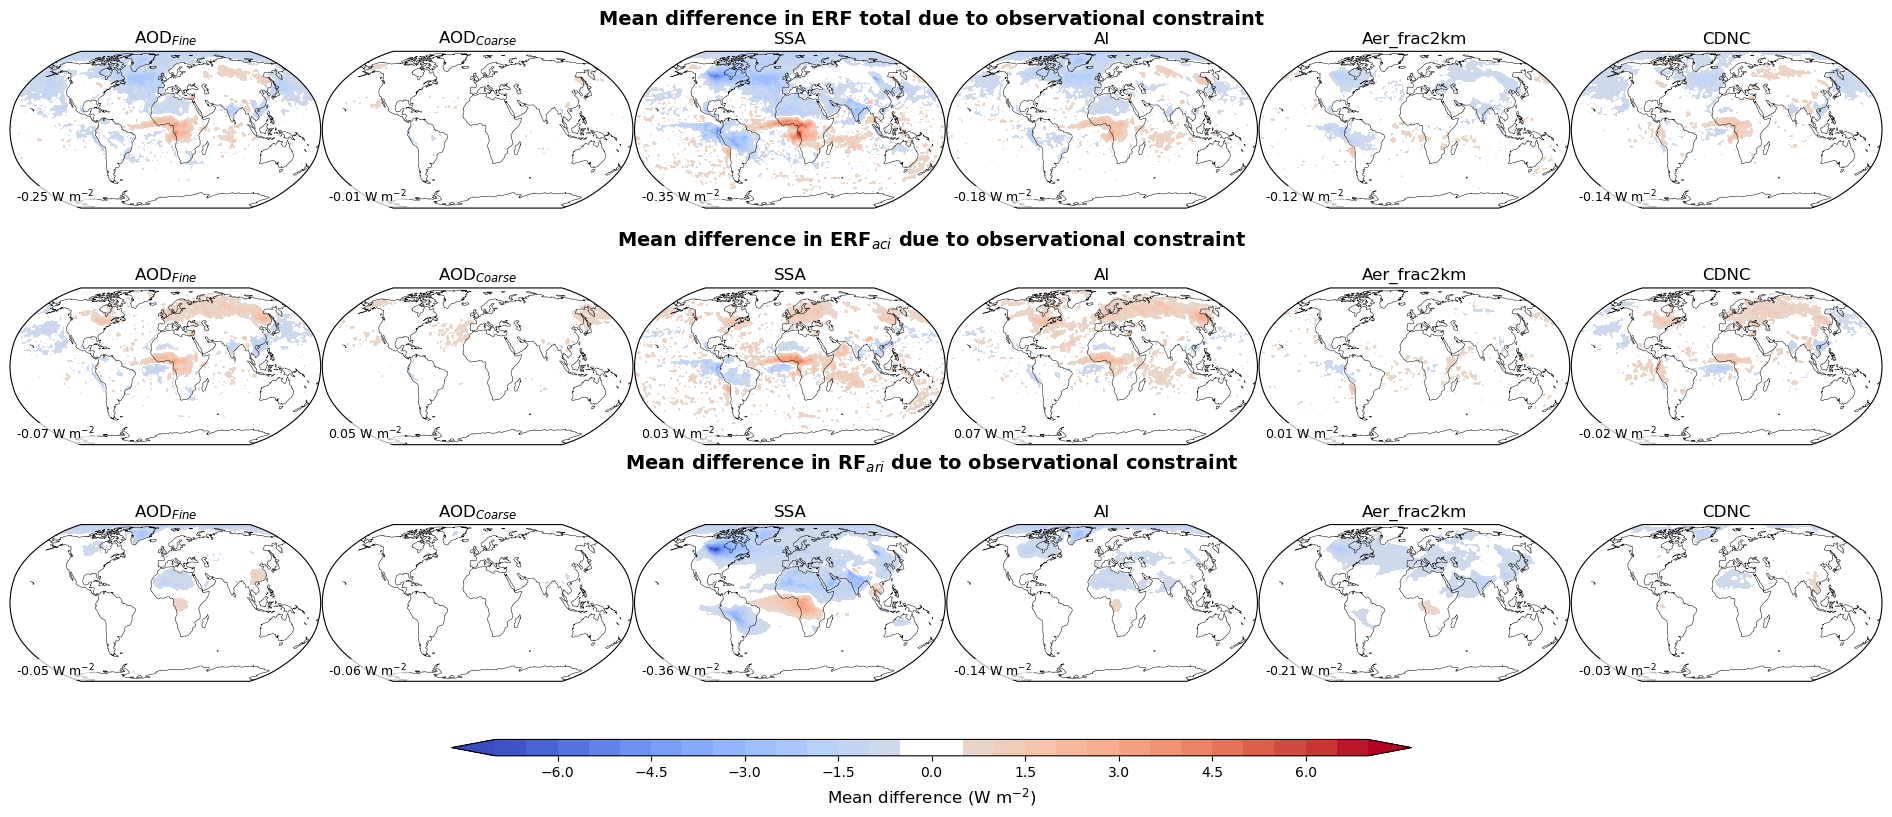

In [39]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import LinearSegmentedColormap

# =========================
# Helper
# =========================
def cyclic_da(da):
    data_cyc, lon_cyc = add_cyclic_point(da.values, coord=da.lon.values)
    return lon_cyc, da.lat.values, data_cyc

# =========================
# Full ensemble fields
# =========================
ERF_mean_full = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERF_mean_full_2_million.nc"
)["Emulated __xarray_dataarray_variable__"]

ERFaci_mean_full = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERFaci_mean_full_2_million.nc"
)["Emulated __xarray_dataarray_variable__"]

ERFari_mean_full = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERFari_mean_full_2_million.nc"
)["Emulated __xarray_dataarray_variable__"]

# =========================
# Constrained means (per observation)
# =========================
ds_erf = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERF_constraint_mean_from_observations_new_cdnc.nc"
)
ERF_mean_acc = ds_erf["ERF_mean_acc"]

ds_aci = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERFaci_constraint_mean_from_observations_new_cdnc.nc"
)
ERFaci_mean_acc = ds_aci["ERF_mean_acc"]

ds_ari = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERFari_constraint_mean_from_observations_new_cdnc.nc"
)
ERFari_mean_acc = ds_ari["ERF_mean_acc"]

# =========================
# Constraints (columns) + titles
# =========================
constraints = ['AOD_Mode_1', 'AOD_Mode_Coarse', 'SSA', 'AI', 'TAU355_daily', 'CDNC_Filtered_OCI']
OBS_TITLES = [
    "AOD$_{Fine}$",
    "AOD$_{Coarse}$",
    "SSA",
    "AI",
    "Aer_frac2km",
    "CDNC",
]
n = len(constraints)

rows = [
    ("ERF total", ERF_mean_acc,    ERF_mean_full),
    ("ERF$_{aci}$", ERFaci_mean_acc, ERFaci_mean_full),
    ("RF$_{ari}$",  ERFari_mean_acc, ERFari_mean_full),
]

# =========================
# Levels + colormap (±0.5 white)
# =========================
clevs_diff = np.arange(-7, 7.5, 0.5)

coolwarm_data = plt.cm.coolwarm(np.linspace(0, 1, 256))
coolwarm_data[116:140, :] = 1.0
coolwarm_white = LinearSegmentedColormap.from_list("coolwarm_white", coolwarm_data)

# =========================
# Plot
# =========================
proj = ccrs.Robinson()
fig, axes = plt.subplots(
    nrows=3, ncols=n,
    figsize=(3.2 * n, 8.2),
    subplot_kw=dict(projection=proj),
    constrained_layout=False
)

pcm = None
for r, (row_title, acc_mean, full_mean) in enumerate(rows):
    for i, c in enumerate(constraints):
        mean_diff = acc_mean.sel(constraint=c) - full_mean

        lon, lat, data = cyclic_da(mean_diff)
        pcm = axes[r, i].contourf(
            lon, lat, data,
            levels=clevs_diff,
            cmap=coolwarm_white,
            extend="both",
            transform=ccrs.PlateCarree()
        )
        axes[r, i].coastlines(linewidth=0.35)

        # Column titles only on top row
        #if r == 0:
        axes[r, i].set_title(OBS_TITLES[i], fontsize=12, pad=6)

        # Panel annotation: area-weighted mean
        try:
            gm = areaweight(mean_diff, mean_diff.lat).data
            axes[r, i].text(
                0.02, 0.02,
                f"{gm:.2f} W m$^{{-2}}$",
                transform=axes[r, i].transAxes,
                fontsize=9,
                ha="left", va="bottom",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
            )
        except Exception:
            pass

    # ---- Row title as a centered header above the row ----
    y = axes[r, 0].get_position().y1 + 0.1
    fig.text(
        0.5, y,
        f"Mean difference in {row_title} due to observational constraint",
        ha="center", va="bottom",
        fontsize=14, weight="bold"
    )

# =========================
# Shared colorbar (tight)
# =========================
cax = fig.add_axes([0.25, 0.045, 0.5, 0.02])
cb = fig.colorbar(pcm, cax=cax, orientation="horizontal")
cb.set_label("Mean difference (W m$^{-2}$)", fontsize=12)

# Tighten spacing
fig.subplots_adjust(
    wspace=0.005,
    hspace=0.02,
    top=0.95,
    bottom=0.09,
    left=0.02,
    right=0.995
)

#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Supplimentary/ERF_Maps_individual_constraint.png", dpi=100, bbox_inches='tight')
#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Supplimentary/ERF_Maps_individual_constraint.pdf", dpi=100, bbox_inches='tight')

plt.show()


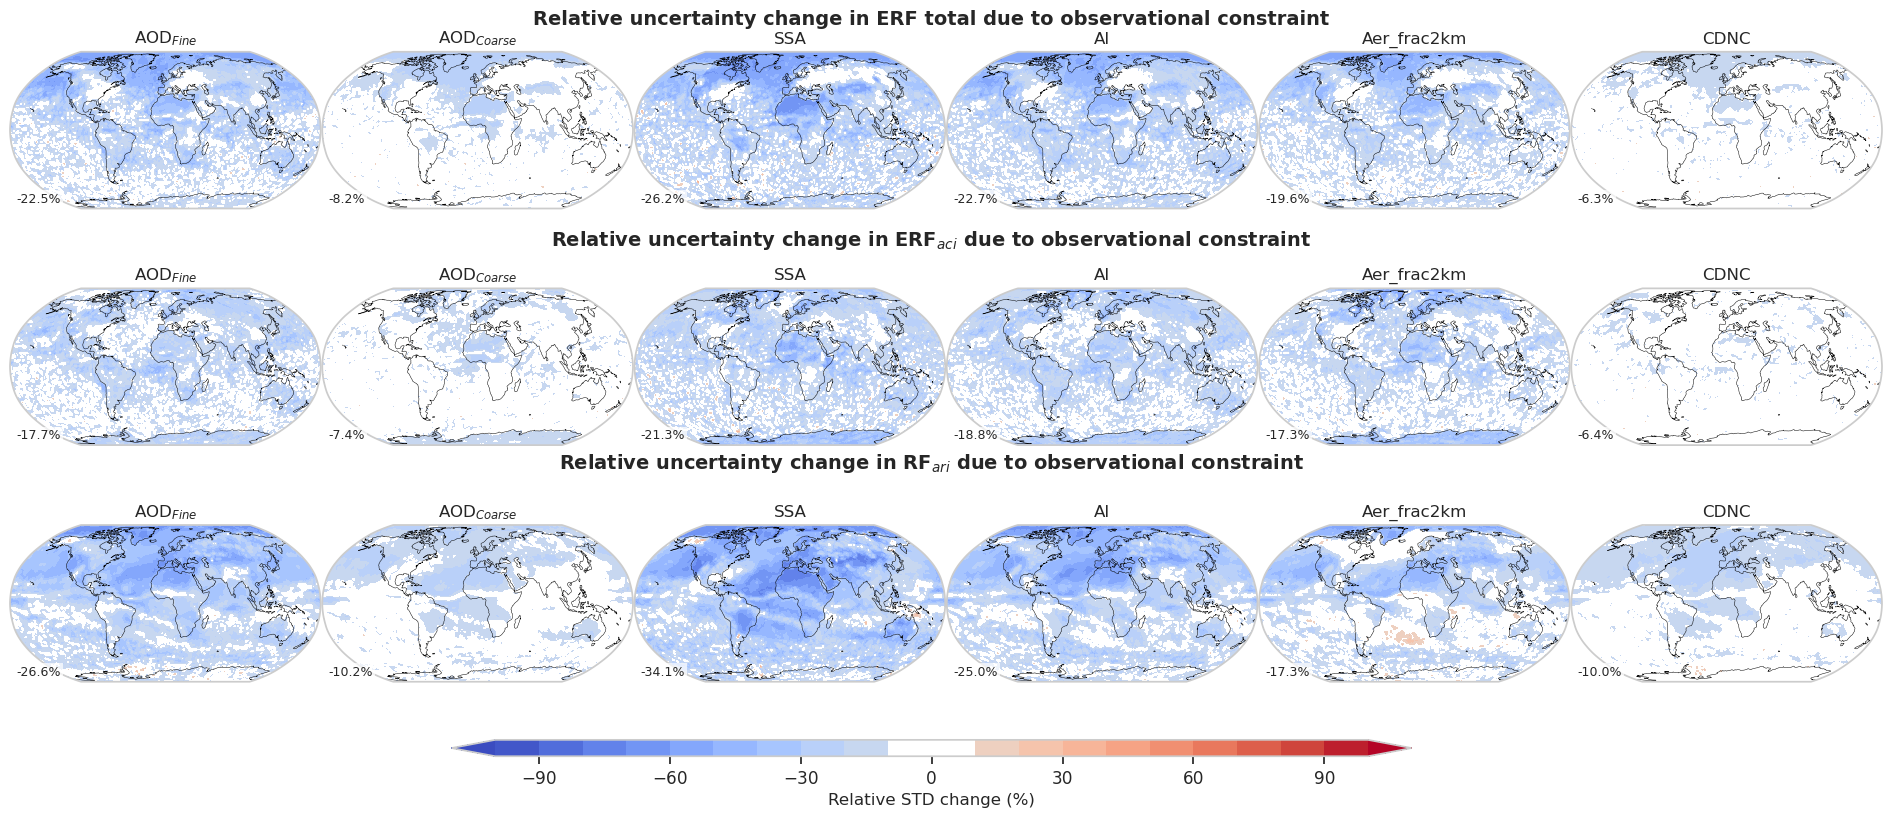

In [112]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import LinearSegmentedColormap

# =========================
# Helper
# =========================
def cyclic_da(da):
    data_cyc, lon_cyc = add_cyclic_point(da.values, coord=da.lon.values)
    return lon_cyc, da.lat.values, data_cyc

# =========================
# Full ensemble STD fields
# =========================
ERF_std_full = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERF_std_full_2_million.nc"
)["Emulated __xarray_dataarray_variable__"]

ERFaci_std_full = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERFaci_std_full_2_million.nc"
)["Emulated __xarray_dataarray_variable__"]

ERFari_std_full = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERFari_std_full_2_million.nc"
)["Emulated __xarray_dataarray_variable__"]

# =========================
# Constrained STDs (per observation)
# =========================
ds_erf = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERF_constraint_mean_from_observations_new_cdnc.nc"
)
ERF_std_acc = ds_erf["ERF_std_acc"]

ds_aci = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERFaci_constraint_mean_from_observations_new_cdnc.nc"
)
ERFaci_std_acc = ds_aci["ERF_std_acc"]

ds_ari = xr.open_dataset(
    "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/"
    "Emulated_data/Implausibility/Var/Regional/ERF/"
    "ERFari_constraint_mean_from_observations_new_cdnc.nc"
)
ERFari_std_acc = ds_ari["ERF_std_acc"]

# =========================
# Constraints (columns) + titles
# =========================
constraints = ['AOD_Mode_1', 'AOD_Mode_Coarse', 'SSA', 'AI', 'TAU355_daily', 'CDNC_Filtered_OCI']
OBS_TITLES = [
    "AOD$_{Fine}$",
    "AOD$_{Coarse}$",
    "SSA",
    "AI",
    "Aer_frac2km",
    "CDNC",
]
n = len(constraints)

rows = [
    ("ERF total",  ERF_std_acc,    ERF_std_full),
    ("ERF$_{aci}$", ERFaci_std_acc, ERFaci_std_full),
    ("RF$_{ari}$",  ERFari_std_acc, ERFari_std_full),
]

# =========================
# Levels + colormap (±5% white)
# =========================
clevs_ratio = np.arange(-100, 110, 10)

coolwarm_data = plt.cm.coolwarm(np.linspace(0, 1, 256))
coolwarm_data[120:136, :] = 1.0   # white-ish center around ~0
coolwarm_white = LinearSegmentedColormap.from_list("coolwarm_white", coolwarm_data)

# =========================
# Plot
# =========================
proj = ccrs.Robinson()
fig, axes = plt.subplots(
    nrows=3, ncols=n,
    figsize=(3.2 * n, 8.2),
    subplot_kw=dict(projection=proj),
    constrained_layout=False
)

pcm = None
for r, (row_title, acc_std, full_std) in enumerate(rows):
    for i, c in enumerate(constraints):

        rel_diff = 100.0 * (acc_std.sel(constraint=c) - full_std) / full_std

        lon, lat, data = cyclic_da(rel_diff)
        pcm = axes[r, i].contourf(
            lon, lat, data,
            levels=clevs_ratio,
            cmap=coolwarm_white,
            extend="both",
            transform=ccrs.PlateCarree()
        )
        axes[r, i].coastlines(linewidth=0.35)

        # Column titles only on top row
        axes[r, i].set_title(OBS_TITLES[i], fontsize=12, pad=6)

        # Panel annotation: area-weighted global mean % change
        try:
            gm = areaweight(rel_diff, rel_diff.lat).data
            axes[r, i].text(
                0.02, 0.02,
                f"{gm:.1f}%",
                transform=axes[r, i].transAxes,
                fontsize=9,
                ha="left", va="bottom",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
            )
        except Exception:
            pass

    # ---- Row title above row ----
    y = axes[r, 0].get_position().y1 + 0.1
    fig.text(
        0.5, y,
        f"Relative uncertainty change in {row_title} due to observational constraint",
        ha="center", va="bottom",
        fontsize=14, weight="bold"
    )

# =========================
# Shared colorbar
# =========================
cax = fig.add_axes([0.25, 0.045, 0.5, 0.02])
cb = fig.colorbar(pcm, cax=cax, orientation="horizontal")
cb.set_label("Relative STD change (%)", fontsize=12)

# Tighten spacing
fig.subplots_adjust(
    wspace=0.005,
    hspace=0.02,
    top=0.95,
    bottom=0.09,
    left=0.02,
    right=0.995
)

#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Supplimentary/ERF_Uncertainty_Maps_individual_constraint.png", dpi=100, bbox_inches='tight')
#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Supplimentary/ERF_Uncertainty_Maps_individual_constraint.pdf", dpi=100, bbox_inches='tight')

plt.show()



In [113]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================
# Paths & PPE tag
# =========================
BASE_DIR = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var"
TARGET_TAG = "60000"

# =========================
# Variables & Titles
# =========================
OBS_TO_PLOT = [
    "AOD_Mode_1",
    "AOD_Mode_Coarse",
    "SSA",
    "AI",
    "TAU355_daily",
    # "REFFL_CT_OCI",
    "CDNC_OCI_spx",
]

OBS_TITLES = {
    "AOD_Mode_1": "AOD_${Fine}$",
    "AOD_Mode_Coarse": "AOD_${Coarse}$",
    "SSA": "Single Scattering Albedo",
    "AI": "Aerosol Index",
    "TAU355_daily": "Aer_frac2km",
    # "REFFL_CT_OCI": "REFFL_CT",
    "CDNC_OCI_spx": "CDNC_CT",
}

MONTH_NAMES = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}

# =========================
# Observation data (already grouped by time.month)
# =========================
OBS_DATA = {
    "AOD_Mode_1": AOD_m_1,
    "AOD_Mode_Coarse": AOD_coarse,
    "SSA": SSA,
    "AI": AI,
    "TAU355_daily": TAU355_daily,
    # "REFFL_CT_OCI": REFFL_CT_OCI,
    "CDNC_OCI_spx": CDNC_Filtered_OCI_swath_spex,
}

# =========================
# Colormap: 0=Rejected (red), 1=Accepted (blue)
# =========================
cmap = ListedColormap(["red", "blue"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

# =========================
# Helpers
# =========================
def get_main_var(ds):
    return next(iter(ds.data_vars))

def add_cyclic(da):
    data_cyc, lon_cyc = add_cyclic_point(da.values, coord=da.lon.values)
    return lon_cyc, da.lat.values, data_cyc

# =========================
# Collect 60000 PPE files
# =========================
ppe_files = {}
for obs in OBS_TO_PLOT:
    obs_path = os.path.join(BASE_DIR, obs)
    if not os.path.isdir(obs_path):
        continue

    files = [
        f for f in os.listdir(obs_path)
        if f.endswith(".nc") and TARGET_TAG in f
    ]
    if files:
        ppe_files[obs] = os.path.join(obs_path, sorted(files)[0])

# =========================
# Determine full month set (union across variables)
# =========================
all_months = set()
for obs in OBS_TO_PLOT:
    if obs not in ppe_files:
        continue
    ds = xr.open_dataset(ppe_files[obs])
    da = ds[get_main_var(ds)]
    if "month" in da.dims:
        all_months |= set(da.month.values)

months = np.array(sorted(all_months))
n_months = len(months)
n_vars = len(OBS_TO_PLOT)

# =========================
# Figure
# =========================
fig, axes = plt.subplots(
    nrows=n_months,
    ncols=n_vars,
    figsize=(3 * n_vars, 2.4 * n_months),
    subplot_kw=dict(projection=ccrs.Robinson()),
)

axes = np.atleast_2d(axes)

# =========================
# Plot loop
# =========================
for j, obs in enumerate(OBS_TO_PLOT):

    if obs not in ppe_files:
        continue

    ds = xr.open_dataset(ppe_files[obs])
    da_ppe = ds[get_main_var(ds)]
    obs_da = OBS_DATA[obs]

    available_months = set(da_ppe.month.values)

    for i, month in enumerate(months):

        ax = axes[i, j]

        if month not in available_months:
            ax.set_visible(False)
            continue

        da_month = da_ppe.sel(month=month)
        obs_month = obs_da.sel(month=month)

        # Mask PPE by obs availability
        masked = xr.where(~np.isnan(obs_month), da_month, np.nan)

        # % accepted
        valid = np.isfinite(masked)
        accepted = valid & (masked == 1)

        pct = (
            100.0 * accepted.sum().item() / valid.sum().item()
            if valid.sum() > 0 else np.nan
        )

        lon, lat, data = add_cyclic(masked)

        pcm = ax.pcolormesh(
            lon, lat, data,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm
        )

        ax.coastlines(linewidth=0.3)

        # Column titles (top row only)
        if i == 0:
            ax.set_title(
                OBS_TITLES.get(obs, obs),
                fontsize=12,
                pad=10
            )

        # Row labels (left column only)

        # Text annotation (variable + % accepted)
        ax.set_title(
            f"{pct:.1f}%",
            fontsize=9,
            pad=3
        )
        if i == 0:
            ax.set_title(OBS_TITLES.get(obs, obs), fontsize=11)

# =========================
# Colorbar
# =========================
fig.subplots_adjust(bottom=0.06, top=0.94, hspace=0.12, wspace=0.05)

cax = fig.add_axes([0.25, 0.025, 0.5, 0.015])
cbar = fig.colorbar(pcm, cax=cax, orientation="horizontal", ticks=[0, 1])
cbar.ax.set_xticklabels(["Rejected", "Accepted"])
cbar.set_label("Reject Map", fontsize=12)

fig.suptitle(
    "Monthly Reject Maps (60000 PPE, masked by observations)",
    fontsize=16
)

#plt.savefig("/home/ybhatti2/Figures/Manuscript_Figures/Supplimentary/Rejected_Maps.png", dpi=100, bbox_inches='tight')

plt.show()


NameError: name 'TAU355_daily' is not defined

# 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
ds = xr.open_dataset("Regional_Mask_Ships_African_Horn.nc")
region_names = [
    'Australia', 'Europe', 'South-East Asia', 'Siberia', 'Savannah',
    'North America', 'Boreal America', 'Amazon', 'North Atlantic',
    'South Atlantic', 'North Pacific', 'South Pacific', 'Tropic Atlantic',
    'Tropic Pacific', 'Tropic Indian', 'South Indian', 'Dust belt', 'Shipping',
    'African Horn'
]

# select regions
mask = np.isin(ds.region_name.values, region_names)
selected_regions = ds.regional_mask[mask]
selected_names = ds.region_name.values[mask]
label_positions = {
    'Dust belt': (20, 25),
    'African Horn': (25, 10),
    'Tropic Atlantic': (340, 1),
    'North Atlantic': (320, 30),
    'South Atlantic': (340, -41),
    'Shipping': (303, 37)
}

# =====================================================
# PREP — MAP DATA
# =====================================================
region_stats_idx = region_stats.set_index('region')
lon, lat = np.meshgrid(ds.lon, ds.lat)

# =====================================================
# PREP — ATTRIBUTION DATA (ERF-CONSISTENT)
# =====================================================
results_df = pd.read_csv(
    "/home/ybhatti2/prjs1474/Datasets/Manuscript_Dataset/Raw_Uncertainty_Constraints_2000000_Final_v2.csv"
)

exclude_obs = ['ERF', 'ERFaci', 'ERFari']
df_obs = results_df[~results_df['Observation'].isin(exclude_obs)].copy()

obs_eff = (
    df_obs
    .groupby(['region', 'Observation'])['constraint_eff']
    .median()
    .reset_index()
)

obs_pivot = (
    obs_eff
    .pivot(index='region', columns='Observation', values='constraint_eff')
    .fillna(0)
)

category_labels = [
    "High effectiveness / Stable",
    "High effectiveness / Seasonal",
    "Low effectiveness / Stable",
    "Low effectiveness / Seasonal"
]

# =========================
# REGION-LEVEL METRICS
# =========================
region_stats_idx = region_stats.set_index('region')

# -------------------------
# CATEGORY DEFINITION
# -------------------------
C_thresh = region_stats_idx['C_median'].median()
IQR_thresh = region_stats_idx['C_iqr'].median()

def classify_region(row):
    if row['C_median'] >= C_thresh and row['C_iqr'] < IQR_thresh:
        return 0
    if row['C_median'] >= C_thresh and row['C_iqr'] >= IQR_thresh:
        return 1
    if row['C_median'] < C_thresh and row['C_iqr'] < IQR_thresh:
        return 2
    return 3

region_stats_idx['category'] = region_stats_idx.apply(
    classify_region, axis=1
)

# ERF constraint effectiveness from map
C_erf = region_stats_idx['C_median']
obs_pivot = obs_pivot.loc[obs_pivot.index.intersection(C_erf.index)]
C_erf = C_erf.loc[obs_pivot.index]

# Normalise + scale
weights = obs_pivot.div(obs_pivot.sum(axis=1), axis=0).fillna(0)
attrib_eff = weights.mul(C_erf, axis=0)

region_order = C_erf.sort_values(ascending=False).index
attrib_eff = attrib_eff.loc[region_order]

# =====================================================
# FIGURE LAYOUT
# =====================================================
fig = plt.figure(figsize=(18, 18))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    height_ratios=[1.1, 1],
    width_ratios=[1.1, 1],
    hspace=0.25,
    wspace=0.25
)

ax_cat = fig.add_subplot(gs[0, :])     # category map
ax_map = fig.add_subplot(gs[1, 0])     # ERF median map
ax_bar = fig.add_subplot(gs[1, 1])     # attribution bars

# =====================================================
# (a) CATEGORY MAP
# =====================================================
category_cmap = mpl.colors.ListedColormap(
    ['#1b9e77', '#66c2a5', '#fc8d62', '#d73027']
)
category_norm = mpl.colors.BoundaryNorm([0, 1, 2, 3, 4], category_cmap.N)

for i, name in enumerate(selected_names):

    if name not in region_stats_idx.index:
        continue

    region_mask = selected_regions[i]
    mask_binary = (region_mask > 0).astype(float)
    category = region_stats_idx.loc[name, 'category']

    ax_cat.contourf(
        lon, lat, mask_binary,
        levels=[0.5, 1],
        colors=[category_cmap(category_norm(category))],
        zorder=1
    )

    ax_cat.contour(
        lon, lat, mask_binary,
        levels=[0.5],
        colors='black',
        linewidths=1,
        zorder=2
    )

    lon_c, lat_c = label_positions.get(
        name,
        (ds.lon[np.where(region_mask > 0)[1]].mean(),
         ds.lat[np.where(region_mask > 0)[0]].mean())
    )

    ax_cat.text(
        lon_c, lat_c, name,
        ha='center', va='center',
        fontsize=9, weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=0.8)
    )

ax_cat.set_title(
    "Regional classification of ERF constraint effectiveness and robustness",
    fontsize=16,
    pad=10
)
ax_cat.set_xlabel("Longitude", fontsize=13)
ax_cat.set_ylabel("Latitude", fontsize=13)

cbar_cat = fig.colorbar(
    mpl.cm.ScalarMappable(norm=category_norm, cmap=category_cmap),
    ax=ax_cat,
    orientation='horizontal',
    pad=0.1,
    fraction=0.05
)
#cbar_cat.set_label("Constraint category", fontsize=13)
cbar_cat.ax.tick_params(labelsize=11)
# Set ticks at the center of each category
tick_positions = np.arange(4)# + 0.5
cbar_cat.set_ticks(tick_positions)
cbar_cat.set_ticklabels(category_labels)
cbar_cat.ax.tick_params(labelsize=12, rotation=10)

# =====================================================
# (b) ERF MEDIAN MAP
# =====================================================
cmap_med = plt.cm.viridis
norm_med = mpl.colors.Normalize(vmin=0.2, vmax=0.5)

for i, name in enumerate(selected_names):

    if name not in region_stats_idx.index:
        continue

    region_mask = selected_regions[i]
    mask_binary = (region_mask > 0).astype(float)
    value = region_stats_idx.loc[name, 'C_median']

    ax_map.contourf(
        lon, lat, mask_binary,
        levels=[0.5, 1],
        colors=[cmap_med(norm_med(value))],
        zorder=1
    )

    ax_map.contour(
        lon, lat, mask_binary,
        levels=[0.5],
        colors='black',
        linewidths=1,
        zorder=2
    )
    if name in label_positions:
        lon_center, lat_center = label_positions[name]
    else:
        lat_vals, lon_vals = np.where(region_mask > 0)
        if len(lat_vals) == 0:
            continue
        lat_center = ds.lat[lat_vals].mean().item()
        lon_center = ds.lon[lon_vals].mean().item()

    ax_map.text(
        lon_center, lat_center, name,
        ha='center', va='center',
        fontsize=8, weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=0.8)
    )

ax_map.set_title("ERF constraint effectiveness (median)", fontsize=14)
ax_map.set_xlabel("Longitude", fontsize=13)
ax_map.set_ylabel("Latitude", fontsize=13)

cbar_med = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm_med, cmap=cmap_med),
    ax=ax_map,
    orientation='horizontal',
    pad=0.12,
    fraction=0.08
)
cbar_med.set_label("C_median", fontsize=12)

# =====================================================
# (c) ATTRIBUTION BARS
# =====================================================
cmap = plt.cm.tab10
colors = cmap.colors[:len(attrib_eff.columns)]

left = np.zeros(len(attrib_eff))

for i, obs in enumerate(attrib_eff.columns):
    vals = attrib_eff[obs].values
    ax_bar.barh(
        attrib_eff.index,
        vals,
        left=left,
        color=colors[i],
        edgecolor='none',
        label=obs
    )
    left += vals

ax_bar.set_title(
    "Attribution of ERF constraint effectiveness to observations",
    fontsize=14
)
ax_bar.set_xlabel("ERF constraint effectiveness (C_median)", fontsize=13)
ax_bar.tick_params(axis='y', labelsize=11)
ax_bar.tick_params(axis='x', labelsize=11)
ax_bar.grid(axis='x', alpha=0.3)

ax_bar.legend(
    title="Observation",
    fontsize=10,
    title_fontsize=11,
    loc="upper right"
)

plt.tight_layout()
#plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Least_Square/Constraint_Figure_Attribution.png", dpi=100, bbox_inches='tight')
plt.show()
